In [226]:
# Cai dat thu vien (chay 1 lan)
%pip install pandas numpy matplotlib seaborn jinja2 scipy plotly scikit-learn openai tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
from matplotlib.ticker import MaxNLocator


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# 1. Data Exploration and Format Standardization

In [227]:

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
sns.set_theme(style="whitegrid")


def comprehensive_eda(file_path, target_col=None):

    """
    Detailed exploratory data analysis (EDA) function.
    -file_path: Path to CSV file.
    -target_col (optional): Target column name (label) for detailed analysis of class imbalance.
    """
    print(f'{"="*10} DIAGNOSTIC DATA REPORT {"="*10}\n')
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading file: {e}")
        return None
    print(f"[1] SIZE OVERVIEW: {df.shape[0]} rows x {df.shape[1]} columns")
    duplicate_count = df.duplicated().sum()
    print(f"[!] Completely duplicate data: {duplicate_count} line ({(duplicate_count/len(df))*100:.2f}%)\n")

    print("[2] MISSING VALUES):")
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    if not missing_data.empty:
        missing_df = pd.DataFrame({
            'Missing Count': missing_data,
            'Percentage (%)': np.round((missing_data / len(df)) * 100, 2)
        })
        print(missing_df)
    else:
        print("-> Excellent! The dataset has no missing values.\n")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    if num_cols:
        print("\n[3] QUANTITATIVE VARIABLE STATISTICS (NUMERICAL) & OUTLIER DETECTION:")
        num_stats = df[num_cols].describe().T
        num_stats['skewness'] = df[num_cols].skew()
        num_stats['kurtosis'] = df[num_cols].kurtosis()

        display_stats = num_stats[['mean', 'std', 'min', '50%', 'max', 'skewness']]
        print(display_stats.round(3))
        print(" *Note: Skewness > 1 or < -1 indicates that the data has a skewed distribution (long tail) or contains large outliers.")

    if cat_cols:
        print("\n[4] CATEGORICAL VARIABLE STATISTICS (CATEGORICAL):")
        cat_stats = pd.DataFrame({
            'Number of Unique values': df[cat_cols].nunique(),
            'Most frequent value (Top)': df[cat_cols].mode().iloc[0],
            'Top Ratio (%)': [np.round((df[col].value_counts(normalize=True).max()) *100, 2) for col in cat_cols]
        })
        print(cat_stats)
        print(" *Note: If 'Top Percentage (%)' is too high (eg > 95%), that column may cause noise because it almost only contains 1 value.")

    return df
df = comprehensive_eda(r'../data/raw\Final_Merged_2605_quyhoach.csv')


========== DIAGNOSTIC DATA REPORT ==========

[1] SIZE OVERVIEW: 8304 rows x 29 columns
[!] Completely duplicate data: 1307 line (15.74%)

[2] MISSING VALUES):
                       Missing Count  Percentage (%)
Hướng ban công                  7320           88.15
Hướng nhà                       6610           79.60
Loại đường vào                  4182           50.36
Nội thất                        4142           49.88
Đường vào                       3895           46.91
QHPK_Ma_O_Pho                   2991           36.02
So_Thua                         2952           35.55
So_To                           2952           35.55
QHPK_Chuc_Nang                  2903           34.96
QHPK_Dien_Tich                  2903           34.96
QHPK_Ty_Le                      2903           34.96
QHPK_Ma_QU                      2903           34.96
Phuong_Xa                       2893           34.84
Dien_Tich_Lo                    2893           34.84
QHPK_So_O                       2893         

In [228]:
print(type(df))
print(df)


<class 'pandas.core.frame.DataFrame'>
                                                   Link  \
0     https://batdongsan.com.vn/ban-nha-mat-pho-duon...   
1     https://batdongsan.com.vn/ban-nha-rieng-duong-...   
2     https://batdongsan.com.vn/ban-nha-rieng-duong-...   
3     https://batdongsan.com.vn/ban-nha-biet-thu-lie...   
4     https://batdongsan.com.vn/ban-nha-biet-thu-lie...   
...                                                 ...   
8299  https://batdongsan.com.vn/ban-nha-rieng-pho-ly...   
8300  https://batdongsan.com.vn/ban-nha-rieng-duong-...   
8301  https://batdongsan.com.vn/ban-nha-mat-pho-pho-...   
8302  https://batdongsan.com.vn/ban-nha-rieng-duong-...   
8303  https://batdongsan.com.vn/ban-nha-rieng-duong-...   

                                                Địa chỉ  Khoảng giá Diện tích  \
0     Đường Nguyễn Thượng Hiền, Phường 6, Quận Bình ...     16,9 tỷ     90 m²   
1     43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...     5,95 tỷ     48 m²   
2     43/1

## Data Formatting, Value Domain Standardization for Categorical Features and Unit Standardization

## Data Formatting and Unit Standardization

### Standardizing the Value Domains of Categorical Features

Convert all text-based values to a unified Unicode format to facilitate subsequent string-processing tasks and ensure consistency across categorical features.

In [229]:
columns_to_remove_dot = [
    'Hướng nhà',
    'Hướng ban công',
    'Pháp lý',
    'Nội thất',
    'Quan_Huyen',
    'Phuong_Xa'
]

print(f"{'='*10} REMOVING TRAILING PERIODS {'='*10}\n")

for col in columns_to_remove_dot:
    if col in df.columns:

        mask = df[col].notnull()

        df.loc[mask, col] = (
            df.loc[mask, col]
            .astype(str)
            .str.rstrip('.')
            .str.strip()
        )

        print(f" Removed trailing periods from column: [{col}]")

    else:
        print(f" Skipped: Column '{col}' was not found in the DataFrame.")

print("\n COMPLETED! Categories with previously inconsistent trailing periods will now be grouped correctly.")


========== REMOVING TRAILING PERIODS ==========

 Removed trailing periods from column: [Hướng nhà]
 Removed trailing periods from column: [Hướng ban công]
 Removed trailing periods from column: [Pháp lý]
 Removed trailing periods from column: [Nội thất]
 Removed trailing periods from column: [Quan_Huyen]
 Removed trailing periods from column: [Phuong_Xa]

 COMPLETED! Categories with previously inconsistent trailing periods will now be grouped correctly.


In [230]:

columns_to_lowercase = [
    'Hướng nhà',
    'Hướng ban công',
    'Pháp lý',
    'Nội thất'
]

for col in columns_to_lowercase:
    if col in df.columns:
        df[col] = df[col].str.lower()

print(
    f"✅ Successfully converted text values to lowercase "
    f"for columns: {columns_to_lowercase}"
)


✅ Successfully converted text values to lowercase for columns: ['Hướng nhà', 'Hướng ban công', 'Pháp lý', 'Nội thất']


In [231]:
columns_to_check = [
    'Hướng nhà',
    'Hướng ban công',
    'Pháp lý',
    'Nội thất',
    'Quan_Huyen',
    'Phuong_Xa'
]

print(f"{'='*15} CATEGORY VALUE INSPECTION {'='*15}\n")

for col in columns_to_check:

    if col in df.columns:

        print(f"🔷 COLUMN: [{col}]")
        print(
            f"-> Total number of unique values: "
            f"{df[col].nunique(dropna=False)}"
        )
        print("-" * 40)

        value_counts = df[col].value_counts(dropna=False)

        for value, count in value_counts.items():
            print(
                f"   • {repr(value):<30} "
                f"appears {count:>5} times"
            )

        print("\n" + "=" * 50 + "\n")

    else:
        print(
            f"Warning: Column '{col}' was not found "
            f"in the current dataset.\n"
        )


=============== CATEGORY VALUE INSPECTION ===============

🔷 COLUMN: [Hướng nhà]
-> Total number of unique values: 13
----------------------------------------
   • nan                            appears  6610 times
   • 'đông - nam'                   appears   440 times
   • 'nam'                          appears   257 times
   • 'đông - bắc'                   appears   227 times
   • 'tây - nam'                    appears   172 times
   • 'tây - bắc'                    appears   159 times
   • 'tây'                          appears   138 times
   • 'đông'                         appears   136 times
   • 'bắc'                          appears   128 times
   • 'đông nam'                     appears    18 times
   • 'tây nam'                      appears     8 times
   • 'đông bắc'                     appears     6 times
   • 'tây bắc'                      appears     5 times


🔷 COLUMN: [Hướng ban công]
-> Total number of unique values: 10
----------------------------------------
   • n

## Value Domain Summary for Categorical features

In [232]:

print(f"{'='*15} LEGAL STATUS STANDARDIZATION {'='*15}\n")

def standardize_legal_status(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    uncertified_keywords = [
        'chờ sổ',
        'hợp đồng',
        'hdmb',
        'hđmb'
    ]

    if any(keyword in text for keyword in uncertified_keywords):
        return np.nan

    pink_book_keywords = [
        'hồng',
        'hong',
        'shr'
    ]

    if any(keyword in text for keyword in pink_book_keywords):
        return 'Pink Book Certificate'

    if (
        'sổ' in text
        or 'đỏ' in text
        or 'sdc' in text
        or text == 'sh'
    ):
        return 'Red Book Certificate'

    return np.nan

df['Pháp lý'] = df['Pháp lý'].apply(
    standardize_legal_status
)

print(" Legal status standardization completed.\n")

status_distribution = (
    df['Pháp lý']
    .value_counts(dropna=False)
)

for status, frequency in status_distribution.items():
    print(
        f"   • {repr(status):<30} "
        f"appears {frequency:>5} times"
    )


=============== LEGAL STATUS STANDARDIZATION ===============

 Legal status standardization completed.

   • 'Pink Book Certificate'        appears  6331 times
   • nan                            appears  1650 times
   • 'Red Book Certificate'         appears   323 times


1. Handling the ['Pháp lý'] column

- From December 10, 2009 until now, the State has combined the above two types of books into a single common paper form issued by the Ministry of Natural Resources and Environment. 
- The Legal column needs to unify the value domain: ['Red book', 'Pink book'] 

2. Handling the ['Nội thất'] column

- Change values to ['Full', 'Basic', 'Unfurnished] 
- Scan the 'Premium' group before the 'Full' group. Because if you scan the word "full" or "full" first, values ​​such as "full of high-end furniture" will mistakenly fall into the 'Full' group and lose the luxury attribute ('High-end') of the real estate. 

In [233]:

print(f"{'='*15} INTERIOR FURNISHING STANDARDIZATION {'='*15}\n")

def standardize_furnishing(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if 'tỷ' in text or 'triệu' in text:
        return np.nan

    unfurnished_keywords = [
        'thô',
        'trống',
        'không nội thất',
        'không nt',
        'nhà trống'
    ]

    if any(keyword in text for keyword in unfurnished_keywords):
        return 'Bare Shell / Unfurnished'

    premium_keywords = [
        'cao cấp',
        'luxury',
        'vip',
        'xịn',
        'sang'
    ]

    if any(keyword in text for keyword in premium_keywords):
        return 'Premium Furnished'

    fully_furnished_keywords = [
        'đầy đủ',
        'full',
        'đủ nội thất',
        'đủ nt',
        'ful',
        'tặng toàn bộ',
        'để lại nội thất'
    ]

    if any(keyword in text for keyword in fully_furnished_keywords):
        return 'Fully Furnished'

    if 'cơ bản' in text:
        return 'Basic Furnished'

    return np.nan

df['Nội thất'] = df['Nội thất'].apply(
    standardize_furnishing
)

print("Interior furnishing standardization completed successfully!\n")

print(f"{'-'*15} STANDARDIZATION RESULTS {'-'*15}")
print(
    f"-> Total number of distinct values: "
    f"{df['Nội thất'].nunique(dropna=False)}"
)
print("-" * 40)

value_distribution = (
    df['Nội thất']
    .value_counts(dropna=False)
)

for value, frequency in value_distribution.items():
    print(
        f"   • {repr(value):<30} "
        f"appears {frequency:>5} times"
    )


=============== INTERIOR FURNISHING STANDARDIZATION ===============

Interior furnishing standardization completed successfully!

--------------- STANDARDIZATION RESULTS ---------------
-> Total number of distinct values: 5
----------------------------------------
   • nan                            appears  4216 times
   • 'Fully Furnished'              appears  2458 times
   • 'Basic Furnished'              appears  1117 times
   • 'Bare Shell / Unfurnished'     appears   335 times
   • 'Premium Furnished'            appears   178 times


### Processing numeric feature units

In [234]:

columns_with_units = [
    'Khoảng giá',
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng',
    'Đường vào'
]

print(f"{'='*15} NUMERICAL FEATURE UNIT INSPECTION {'='*15}\n")

for col in columns_with_units:

    if col in df.columns:

        print(f"🔷 COLUMN: [{col}]")

        detected_units = []

        valid_series = (
            df[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

        for value in valid_series:

            match = re.search(
                r'^\s*[\d.,]+\s*(.*)$',
                value
            )

            if match:

                unit = match.group(1).strip()

                if unit == '':
                    detected_units.append(
                        "[Pure Numeric Value]"
                    )
                else:
                    detected_units.append(unit)

            else:
                detected_units.append(
                    f"[Text / Invalid Entry: {value}]"
                )

        unit_counts = (
            pd.Series(detected_units)
            .value_counts()
        )

        print(
            f"-> Detected {len(unit_counts)} "
            f"distinct unit formats:"
        )

        for unit_name, frequency in unit_counts.items():

            print(
                f"   • {repr(unit_name):<35} "
                f"appears {frequency:>5} times"
            )

        print("\n" + "=" * 50 + "\n")

    else:

        print(
            f" Column '{col}' was not found "
            f"in the DataFrame.\n"
        )


=============== NUMERICAL FEATURE UNIT INSPECTION ===============

🔷 COLUMN: [Khoảng giá]
-> Detected 4 distinct unit formats:
   • 'tỷ'                                appears  7282 times
   • '[Text / Invalid Entry: Thỏa thuận]' appears    81 times
   • 'triệu/m²'                          appears    23 times
   • 'triệu'                             appears     4 times


🔷 COLUMN: [Diện tích]
-> Detected 1 distinct unit formats:
   • 'm²'                                appears  7390 times


🔷 COLUMN: [Số phòng ngủ]
-> Detected 2 distinct unit formats:
   • 'phòng'                             appears  5599 times
   • '[Pure Numeric Value]'              appears    89 times


🔷 COLUMN: [Số phòng tắm, vệ sinh]
-> Detected 2 distinct unit formats:
   • 'phòng'                             appears  5336 times
   • '[Pure Numeric Value]'              appears    76 times


🔷 COLUMN: [Số tầng]
-> Detected 2 distinct unit formats:
   • 'tầng'                              appears  6189 times
   • 

1. Handling the 'Price Range' column

Price range(billion) = [Price range(million/m²) *Area(m²)] /1000
Text data/Strange characters rarely appear: Change to nan

In [235]:

print(f"{'='*15} PRICE STANDARDIZATION TO BILLION VND {'='*15}\n")

def extract_float(text):
    match = re.search(r'[\d.,]+', text)

    if not match:
        return None

    num_str = match.group(0)

    if ',' in num_str and '.' in num_str:
        if num_str.find(',') < num_str.find('.'):
            num_str = num_str.replace(',', '')
        else:
            num_str = num_str.replace('.', '').replace(',', '.')
    elif ',' in num_str:
        num_str = num_str.replace(',', '.')

    return float(num_str)

def convert_price_to_billion(row):

    price_value = str(row['Khoảng giá']).strip()

    if (
        pd.isna(row['Khoảng giá'])
        or price_value in ['nan', '', 'thỏa thuận']
    ):
        return np.nan

    if 'tỷ' in price_value:
        return extract_float(price_value)

    if 'triệu' in price_value:

        price_per_m2 = extract_float(price_value)

        if price_per_m2 is None:
            return np.nan

        area_value = str(row['Diện tích']).strip()
        area = extract_float(area_value)

        if area and area > 0:

            total_price = (
                price_per_m2 * area
            ) / 1000

            print(
                f"💡 Converted unit-price record:\n"
                f"   Original Price: {price_value} | "
                f"Area: {area} m² → "
                f"{total_price:.3f} billion VND\n"
            )

            return total_price

    return np.nan

df['Khoảng giá'] = df.apply(
    convert_price_to_billion,
    axis=1
)

print(
    "🎉 COMPLETED: The 'Khoảng giá' column has been "
    "converted into a standardized numeric format "
    "(float, unit = billion VND)."
)

print(
    f"-> Current number of missing values (NaN): "
    f"{df['Khoảng giá'].isna().sum()} rows"
)


=============== PRICE STANDARDIZATION TO BILLION VND ===============

💡 Converted unit-price record:
   Original Price: 120 triệu/m² | Area: 483.8 m² → 58.056 billion VND

💡 Converted unit-price record:
   Original Price: 161 triệu/m² | Area: 139.0 m² → 22.379 billion VND

💡 Converted unit-price record:
   Original Price: 72 triệu/m² | Area: 110.0 m² → 7.920 billion VND

💡 Converted unit-price record:
   Original Price: 32 triệu/m² | Area: 156.0 m² → 4.992 billion VND

💡 Converted unit-price record:
   Original Price: 50 triệu/m² | Area: 80.6 m² → 4.030 billion VND

💡 Converted unit-price record:
   Original Price: 220 triệu/m² | Area: 180.0 m² → 39.600 billion VND

💡 Converted unit-price record:
   Original Price: 85 triệu/m² | Area: 97.0 m² → 8.245 billion VND

💡 Converted unit-price record:
   Original Price: 85 triệu/m² | Area: 163.0 m² → 13.855 billion VND

💡 Converted unit-price record:
   Original Price: 140 triệu/m² | Area: 490.0 m² → 68.600 billion VND

💡 Converted unit-price 

2. Processing other numeric features already standardized in units

In [236]:

columns_to_clean = [
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng',
    'Đường vào'
]

for col in columns_to_clean:

    if col in df.columns:

        extracted_values = (
            df[col]
            .astype(str)
            .str.extract(r'([\d.]+)')[0]
        )

        df[col] = pd.to_numeric(
            extracted_values,
            errors='coerce'
        )

        print(
            f"✅ Converted column [{col}] "
            f"to a pure numeric format."
        )


✅ Converted column [Diện tích] to a pure numeric format.
✅ Converted column [Số phòng ngủ] to a pure numeric format.
✅ Converted column [Số phòng tắm, vệ sinh] to a pure numeric format.
✅ Converted column [Số tầng] to a pure numeric format.
✅ Converted column [Đường vào] to a pure numeric format.


## Duplicate Record Handling

Count duplicate records

- Không lấy cột link để xét vì một ngôi nhà có thể được đăng bởi nhiều môi gơi, nhiều thời điểm, đăng lại,...

In [237]:
duplicate_count = df.duplicated(
    subset=[
        'Địa chỉ',
        'Khoảng giá',
        'Diện tích',
        'Số phòng ngủ',
        'Số phòng tắm, vệ sinh',
        'Số tầng'
    ]
).sum()

total_rows = len(df)

duplicate_percentage = (
    duplicate_count / total_rows
) * 100

print(f"{'='*10} DUPLICATE RECORD ANALYSIS {'='*10}\n")

print(
    f"-> Total number of records: "
    f"{total_rows:,}"
)

print(
    f"-> Number of duplicate records: "
    f"{duplicate_count:,}"
)

print(
    f"-> Duplicate ratio: "
    f"{duplicate_percentage:.2f}%\n"
)

if duplicate_count > 0:

    print(
        f"{'-'*10} SAMPLE DUPLICATE RECORDS "
        f"(Maximum 5 Rows) {'-'*10}"
    )

    duplicate_records = df[
        df.duplicated(
            subset=['Địa chỉ'],
            keep='first'
        )
    ]

    display(
        duplicate_records.head(5)
    )

    print(
        "\nSuggested action: "
        "Remove duplicate records while "
        "keeping the first occurrence."
    )

    print(
        "df = df.drop_duplicates("
        "keep='first'"
        ").reset_index(drop=True)"
    )

else:

    print(
        "🎉 Excellent! No duplicate "
        "records were detected."
    )


========== DUPLICATE RECORD ANALYSIS ==========

-> Total number of records: 8,304
-> Number of duplicate records: 2,483
-> Duplicate ratio: 29.90%

---------- SAMPLE DUPLICATE RECORDS (Maximum 5 Rows) ----------


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả,Loại đường vào,Quan_Huyen,Phuong_Xa,So_Thua,So_To,Dien_Tich_Lo,Ten_Do_An,QHPK_So_O,QHPK_Chuc_Nang,QHPK_Dien_Tich,QHPK_Ty_Le,QHPK_Ma_QU,QHPK_Ma_O_Pho,Trang_Thai
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...",5.95,48.0,2.0,2.0,2.0,đông - nam,đông,6.0,Pink Book Certificate,Basic Furnished,10.798712,106.613474,Nhà đẹp 48m² hiếm khu Aeon Tân Phú - hẻm xe hơ...,Hẻm ô tô,Quận Tân Phú,Phường Sơn Kỳ,36.0,82.0,40.0,"Đồ án quy hoạch phân khu tỷ lệ 1/2000 Khu 1, Q...",1.0,Đất nhóm nhà ở hiện hữu chỉnh trang,39.98,100.00%,NNO,II/37,Thành công
4,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",26.90,293.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,21.028949,105.852447,DUY NHẤT CĂN BIỆT THỰ ĐƠN LẬP TRỤC VN92 GIÁ 29...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Server trả về rỗng
12,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",23.90,144.0,NaN,NaN,5.0,nam,NaN,NaN,Pink Book Certificate,NaN,10.835955,106.843016,Chủ kẹt tiền bán lỗ căn nhà phố khu dân cư cao...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bị khóa: The land is temporarily locked!
15,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Phú Thuận, Phường Phú Thuận, Quận 7, Hồ ...",15.80,75.0,4.0,5.0,4.0,NaN,NaN,8.0,Pink Book Certificate,Fully Furnished,10.726276,106.733669,"Nhà phố hiện đại KDC Nam Long Phú Thuận, Quận ...",NaN,Quận 7,Phường Tân Phú,30.0,45.0,1889.4,Đồ án quy hoạch chi tiết Khu dân cư Phường Tân...,3.0,Khu dân cư xây dựng mới | Khu dân cư hiện hữu ...,17.15 | 533.61 | 1338.64,0.91% | 28.24% | 70.85%,NNO | NNO | DGT,| |,Thành công
29,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,"Đường Nguyễn Bá Huân, Phường Thảo Điền, Quận 2...",34.00,204.0,6.0,6.0,4.0,NaN,NaN,NaN,Pink Book Certificate,NaN,10.804487,106.728807,"Sản phẩm tốt nhất thị trường khu Thảo Điền, Qu...",Mặt tiền,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bị khóa: The land is temporarily locked!



Suggested action: Remove duplicate records while keeping the first occurrence.
df = df.drop_duplicates(keep='first').reset_index(drop=True)


Remove duplicate records

In [238]:
rows_before = df.shape[0]

df = (
    df
    .drop_duplicates(keep='first')
    .reset_index(drop=True)
)

rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"{'='*10} DUPLICATE REMOVAL RESULTS {'='*10}\n")

print(
    f"-> Number of records before removal: "
    f"{rows_before:,}"
)

print(
    f"-> Number of records after removal: "
    f"{rows_after:,}"
)

print(
    f"🎉 Successfully removed "
    f"{rows_removed:,} duplicate records."
)


========== DUPLICATE REMOVAL RESULTS ==========

-> Number of records before removal: 8,304
-> Number of records after removal: 6,997
🎉 Successfully removed 1,307 duplicate records.


## Handling Empty / Information-Deficient Records

Statistics on empty records. (Empirically, roughly 1 in 31 crawled links is an advertising link with empty data.)

In [239]:

columns_to_check = [
    column
    for column in df.columns
    if column not in ['Link', 'Trang_Thai']
]

empty_record_mask = (
    df[columns_to_check]
    .isnull()
    .all(axis=1)
)

empty_record_count = (
    empty_record_mask.sum()
)

total_records = len(df)

print(
    f"{'='*10} INFORMATION-DEFICIENT RECORD ANALYSIS {'='*10}\n"
)

print(
    f"-> Total records: "
    f"{total_records:,}"
)

print(
    f"-> Records containing only Link and Status: "
    f"{empty_record_count:,}"
)

print(
    f"-> Proportion of information-deficient records: "
    f"{(empty_record_count / total_records) * 100:.2f}%\n"
)

if empty_record_count > 0:

    print(
        f"{'-'*10} SAMPLE INFORMATION-DEFICIENT RECORDS "
        f"(Maximum 5 Rows) {'-'*10}"
    )

    display(
        df[empty_record_mask]
        .head(5)
    )

    print(
        "\nRecommended action: "
        "Remove these records because they contain "
        "insufficient information for analysis."
    )

    print(
        "df = df[~empty_record_mask]"
        ".reset_index(drop=True)"
    )

else:

    print(
        "🎉 Excellent! No information-deficient "
        "records were detected."
    )


========== INFORMATION-DEFICIENT RECORD ANALYSIS ==========

-> Total records: 6,997
-> Records containing only Link and Status: 732
-> Proportion of information-deficient records: 10.46%

---------- SAMPLE INFORMATION-DEFICIENT RECORDS (Maximum 5 Rows) ----------


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả,Loại đường vào,Quan_Huyen,Phuong_Xa,So_Thua,So_To,Dien_Tich_Lo,Ten_Do_An,QHPK_So_O,QHPK_Chuc_Nang,QHPK_Dien_Tich,QHPK_Ty_Le,QHPK_Ma_QU,QHPK_Ma_O_Pho,Trang_Thai
27,https://thepeakgarden.vn/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiếu tọa độ
2218,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiếu tọa độ
3669,https://thepeakgarden.vn/?vrs=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiếu tọa độ
5300,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiếu tọa độ
5301,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiếu tọa độ



Recommended action: Remove these records because they contain insufficient information for analysis.
df = df[~empty_record_mask].reset_index(drop=True)


Remove empty / information-deficient records

In [240]:
rows_before = df.shape[0]

columns_to_check = [
    col
    for col in df.columns
    if col not in ['Link', 'Trang_Thai']
]

empty_record_mask = (
    df[columns_to_check]
    .isnull()
    .all(axis=1)
)

df = (
    df[~empty_record_mask]
    .reset_index(drop=True)
)

rows_after = df.shape[0]

rows_removed = (
    rows_before
    - rows_after
)

print(
    f"{'='*10} INFORMATION-DEFICIENT RECORD REMOVAL RESULTS {'='*10}\n"
)

print(
    f"-> Records before processing: "
    f"{rows_before:,}"
)

print(
    f"-> Records after removal: "
    f"{rows_after:,}"
)

print(
    f"🎉 Successfully removed "
    f"{rows_removed:,} non-informative records."
)


========== INFORMATION-DEFICIENT RECORD REMOVAL RESULTS ==========

-> Records before processing: 6,997
-> Records after removal: 6,265
🎉 Successfully removed 732 non-informative records.


In [241]:
print(df.columns)


Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'So_Thua', 'So_To',
       'Dien_Tich_Lo', 'Ten_Do_An', 'QHPK_So_O', 'QHPK_Chuc_Nang',
       'QHPK_Dien_Tich', 'QHPK_Ty_Le', 'QHPK_Ma_QU', 'QHPK_Ma_O_Pho',
       'Trang_Thai'],
      dtype='object')


==================== EXPLORATORY DATA ANALYSIS (EDA) ====================

--- [1] DESCRIPTIVE STATISTICS OF NUMERICAL FEATURES ---


,count,mean,std,min,25%,50%,75%,max
Khoảng giá,6200.0,20.399677,38.625355,0.33,6.8,9.8,19.5,700.0
Diện tích,6265.0,99.757004,92.131503,1.00,52.0,73.0,107.0,990.0
Số phòng ngủ,4997.0,4.728437,4.840707,1.00,3.0,4.0,5.0,100.0
"Số phòng tắm, vệ sinh",4729.0,4.570945,4.074820,1.00,3.0,4.0,5.0,80.0
Số tầng,5828.0,3.530542,2.922239,1.00,2.0,3.0,4.0,108.0
Đường vào,3842.0,9.799453,10.658179,1.00,5.0,7.0,12.0,367.0



------------------------------------------------------------

--- [2] UNIVARIATE DISTRIBUTION ANALYSIS ---


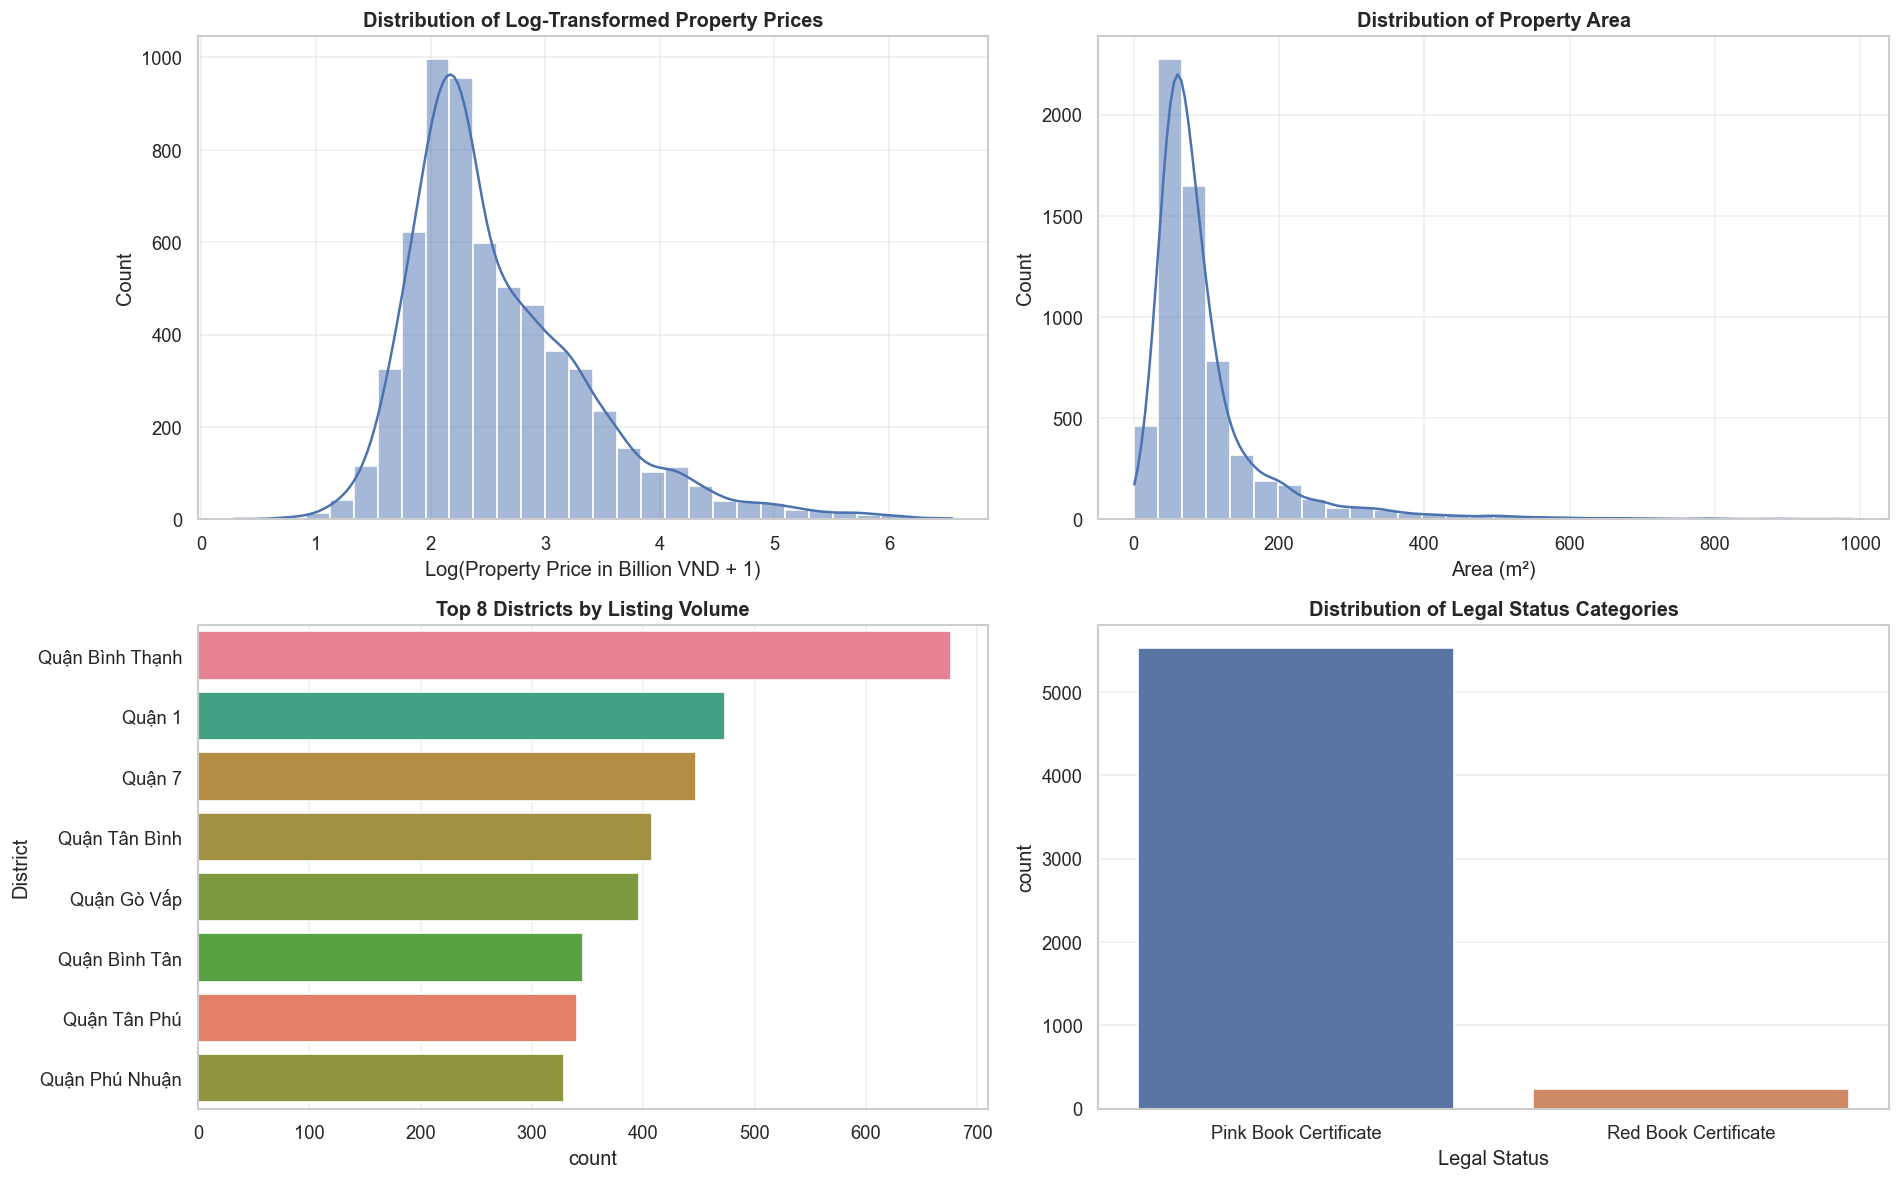


------------------------------------------------------------

--- [3] MULTIVARIATE ANALYSIS OF PROPERTY PRICES ---


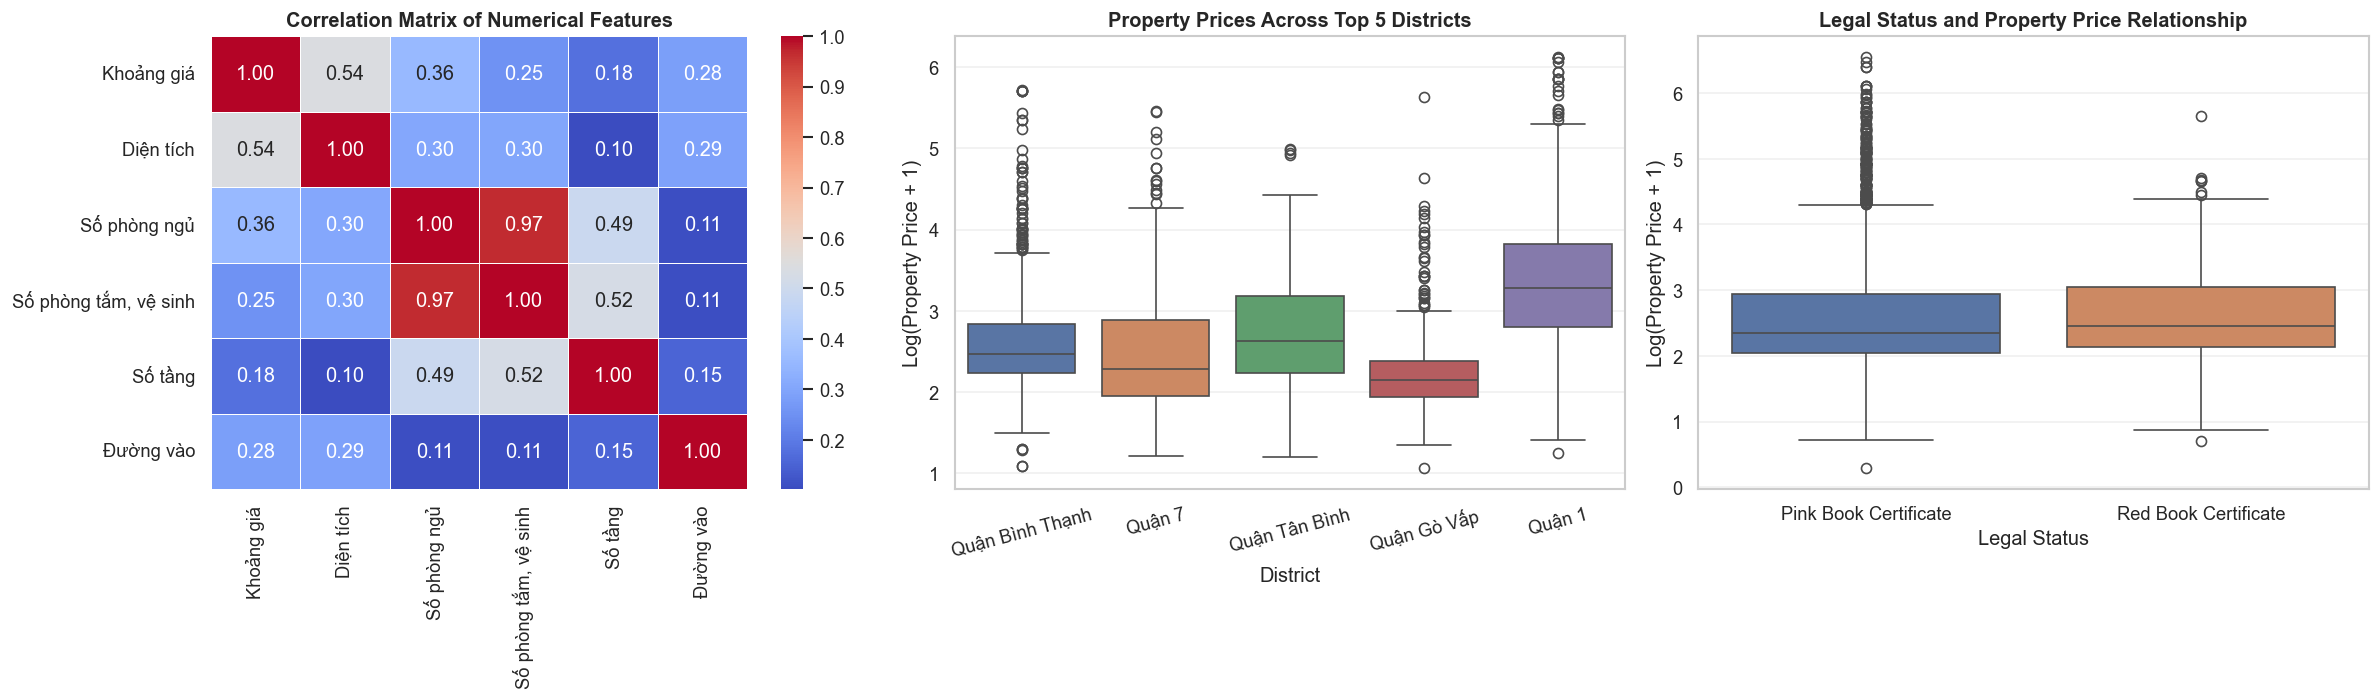

In [242]:

plt.rcParams['figure.dpi'] = 120

sns.set_theme(style="whitegrid")

pd.set_option(
    'display.max_columns',
    None
)

print(
    f"{'='*20} EXPLORATORY DATA ANALYSIS (EDA) {'='*20}\n"
)

print(
    "--- [1] DESCRIPTIVE STATISTICS OF NUMERICAL FEATURES ---"
)

numeric_columns = [
    'Khoảng giá',
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng',
    'Đường vào'
]

numeric_columns = [
    column
    for column in numeric_columns
    if column in df.columns
]

display(
    df[numeric_columns]
    .describe()
    .T
)

print("\n" + "-" * 60 + "\n")

df['Khoảng giá_log'] = np.log1p(
    df['Khoảng giá']
)

print(
    "--- [2] UNIVARIATE DISTRIBUTION ANALYSIS ---"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

sns.histplot(
    data=df,
    x='Khoảng giá_log',
    kde=True,
    ax=axes[0, 0],
    bins=30
)

axes[0, 0].set_title(
    'Distribution of Log-Transformed Property Prices',
    fontsize=12,
    fontweight='bold'
)

axes[0, 0].set_xlabel(
    'Log(Property Price in Billion VND + 1)'
)

sns.histplot(
    data=df,
    x='Diện tích',
    kde=True,
    ax=axes[0, 1],
    bins=30
)

axes[0, 1].set_title(
    'Distribution of Property Area',
    fontsize=12,
    fontweight='bold'
)

axes[0, 1].set_xlabel(
    'Area (m²)'
)

if 'Quan_Huyen' in df.columns:

    sns.countplot(
        data=df,
        y='Quan_Huyen',
        ax=axes[1, 0],
        order=df['Quan_Huyen']
        .value_counts()
        .index[:8],
        hue='Quan_Huyen',
        legend=False
    )

    axes[1, 0].set_title(
        'Top 8 Districts by Listing Volume',
        fontsize=12,
        fontweight='bold'
    )

    axes[1, 0].set_ylabel(
        'District'
    )

if 'Pháp lý' in df.columns:

    sns.countplot(
        data=df,
        x='Pháp lý',
        ax=axes[1, 1],
        hue='Pháp lý',
        legend=False
    )

    axes[1, 1].set_title(
        'Distribution of Legal Status Categories',
        fontsize=12,
        fontweight='bold'
    )

    axes[1, 1].set_xlabel(
        'Legal Status'
    )

plt.tight_layout()
plt.show()

print("\n" + "-" * 60 + "\n")

print(
    "--- [3] MULTIVARIATE ANALYSIS OF PROPERTY PRICES ---"
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    'Correlation Matrix of Numerical Features',
    fontsize=12,
    fontweight='bold'
)

if (
    'Quan_Huyen' in df.columns
    and 'Khoảng giá_log' in df.columns
):

    top_districts = (
        df['Quan_Huyen']
        .value_counts()
        .index[:5]
    )

    district_subset = df[
        df['Quan_Huyen']
        .isin(top_districts)
    ]

    sns.boxplot(
        data=district_subset,
        x='Quan_Huyen',
        y='Khoảng giá_log',
        ax=axes[1],
        hue='Quan_Huyen',
        legend=False
    )

    axes[1].set_title(
        'Property Prices Across Top 5 Districts',
        fontsize=12,
        fontweight='bold'
    )

    axes[1].set_xlabel(
        'District'
    )

    axes[1].set_ylabel(
        'Log(Property Price + 1)'
    )

    axes[1].tick_params(
        axis='x',
        rotation=15
    )

if (
    'Pháp lý' in df.columns
    and 'Khoảng giá_log' in df.columns
):

    legal_status_subset = df[
        df['Pháp lý']
        .isin([
            'Pink Book Certificate',
            'Red Book Certificate'
        ])
    ].dropna(
        subset=['Khoảng giá_log']
    )

    sns.boxplot(
        data=legal_status_subset,
        x='Pháp lý',
        y='Khoảng giá_log',
        ax=axes[2],
        hue='Pháp lý',
        legend=False
    )

    axes[2].set_title(
        'Legal Status and Property Price Relationship',
        fontsize=12,
        fontweight='bold'
    )

    axes[2].set_xlabel(
        'Legal Status'
    )

    axes[2].set_ylabel(
        'Log(Property Price + 1)'
    )

plt.tight_layout()
plt.show()


- From the correlation between certificate type and log(price+1): keeping 'Pink Book' and 'Red Book' separate is reasonable because:
    - Pink Book shows many extremely high-value properties (outliers) indicating luxury projects.
    - Red Book has shorter upper whiskers and fewer extreme outliers.
- Conclusion: Merging them into a single 'Has Certificate' group would hide the model's ability to learn that 'Pink Book' often corresponds to ultra-high prices. Keeping them separate helps the model distinguish property types.

# This step merges the data extracted from the LLM that was run externally. If you want to extract right from this cell code, skip this step to run part 4

In [243]:
df_llm = pd.read_csv(r'../data/full_dataset_extracted.csv')
print(df_llm.columns)
print(df_llm.shape)


Index(['Link', 'Mô tả', 'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc',
       'gan_benh_vien', 'gan_cong_vien_ho_nuoc'],
      dtype='object')
(6072, 7)


In [244]:

print(
    f"Number of records before merging: "
    f"{len(df)} rows"
)

df = pd.merge(
    df,
    df_llm,
    on=['Link', 'Mô tả'],
    how='inner'
)

print(
    f"Number of records after inner join: "
    f"{len(df)} rows"
)

print("\nColumns after merging:")

print(df.columns)

print(df.shape)


Number of records before merging: 6265 rows
Number of records after inner join: 10 rows

Columns after merging:
Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Hướng nhà', 'Hướng ban công',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude', 'Mô tả',
       'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'So_Thua', 'So_To',
       'Dien_Tich_Lo', 'Ten_Do_An', 'QHPK_So_O', 'QHPK_Chuc_Nang',
       'QHPK_Dien_Tich', 'QHPK_Ty_Le', 'QHPK_Ma_QU', 'QHPK_Ma_O_Pho',
       'Trang_Thai', 'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc'],
      dtype='object')
(10, 35)


# 2. Data cleaning (missing values ​​and outliers)


## 2.1 Statistics and preliminary processing.


Statistics on the number of missing values ​​in each column.

In [245]:

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_statistics = pd.concat(
    [missing_count, missing_percentage],
    axis=1,
    keys=[
        'Missing Count',
        'Missing Percentage (%)'
    ]
)

missing_statistics = (
    missing_statistics[
        missing_statistics['Missing Count'] > 0
    ]
    .sort_values(
        by='Missing Count',
        ascending=False
    )
)

if not missing_statistics.empty:

    print(
        f"Total columns containing missing values: "
        f"{len(missing_statistics)} / {df.shape[1]}"
    )

    display(
        missing_statistics.style
        .bar(
            subset=['Missing Percentage (%)']
        )
        .format({
            'Missing Percentage (%)':
            '{:.2f}%'
        })
    )

else:

    print(
        "🎉 Excellent! The dataset contains "
        "no missing values."
    )


Total columns containing missing values: 22 / 35


,Missing Count,Missing Percentage (%)
Hướng ban công,9,90.00%
Đường vào,6,60.00%
Nội thất,6,60.00%
Hướng nhà,5,50.00%
Loại đường vào,5,50.00%
Số phòng ngủ,2,20.00%
"Số phòng tắm, vệ sinh",2,20.00%
Khoảng giá,1,10.00%
Pháp lý,1,10.00%
Quan_Huyen,1,10.00%


Xoá các bản ghi bị thiếu kinh độ và vĩ độ

In [246]:
print(
    f"📊 Dataset shape before removal: "
    f"{df.shape}"
)

df = df.dropna(
    subset=[
        'Latitude',
        'Longitude'
    ]
)

print("-" * 50)

print(
    "✅ Records with missing geographic "
    "coordinates have been removed."
)

print(
    f"📊 Dataset shape after removal: "
    f"{df.shape}"
)

print(
    f"🔍 Remaining missing values in Latitude: "
    f"{df['Latitude'].isnull().sum()}"
)

print(
    f"🔍 Remaining missing values in Longitude: "
    f"{df['Longitude'].isnull().sum()}"
)


📊 Dataset shape before removal: (10, 35)
--------------------------------------------------
✅ Records with missing geographic coordinates have been removed.
📊 Dataset shape after removal: (10, 35)
🔍 Remaining missing values in Latitude: 0
🔍 Remaining missing values in Longitude: 0


Xoá cột 'Hướng ban công' và 'Hướng nhà'

In [247]:
df = df.drop(columns=['Hướng ban công', 'Hướng nhà'])


Xoá các bản ghi có 'Khoảng giá' bị nan

In [248]:
print(
    f"Number of records before removal: "
    f"{len(df)}"
)

df.dropna(
    subset=['Khoảng giá'],
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)

print(
    f"Number of records after removal: "
    f"{len(df)}"
)

print(
    f"Remaining missing values in "
    f"'Khoảng giá': "
    f"{df['Khoảng giá'].isnull().sum()}"
)


Number of records before removal: 10
Number of records after removal: 9
Remaining missing values in 'Khoảng giá': 0


Thống kê trên box plot để tìm outlier.

📊 VISUALIZING 18 NUMERICAL FEATURES (OUTLIER ANALYSIS)...
------------------------------------------------------------


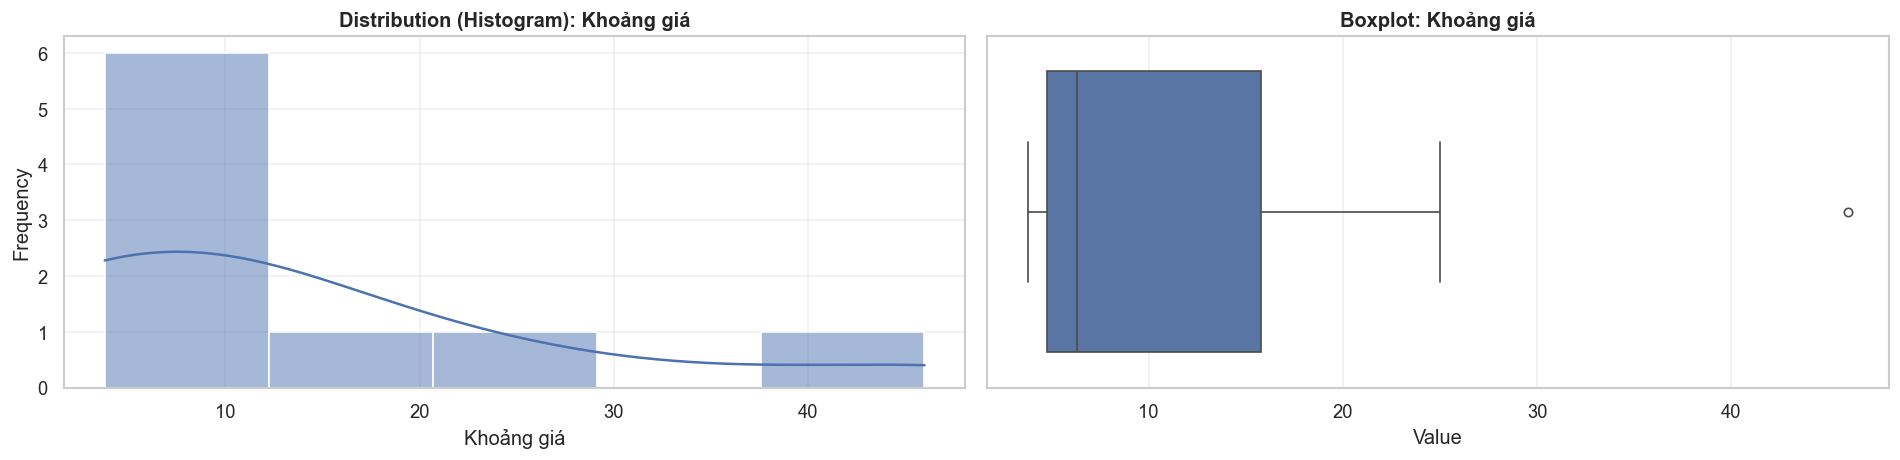

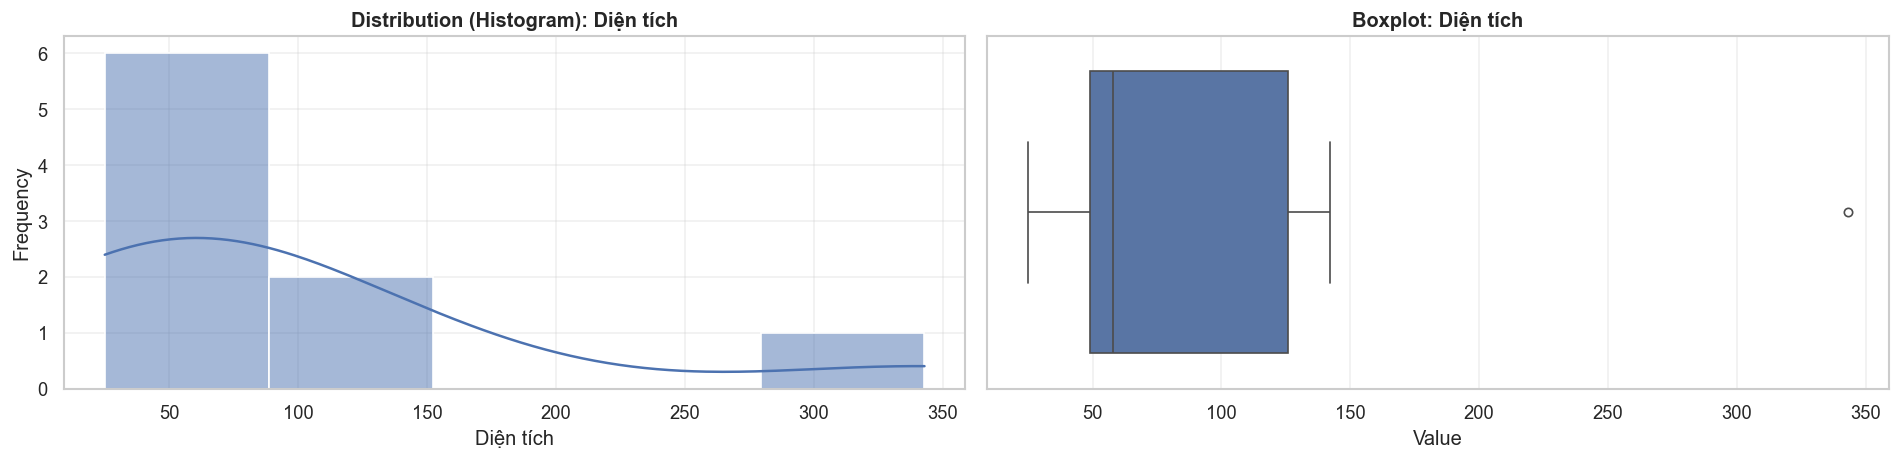

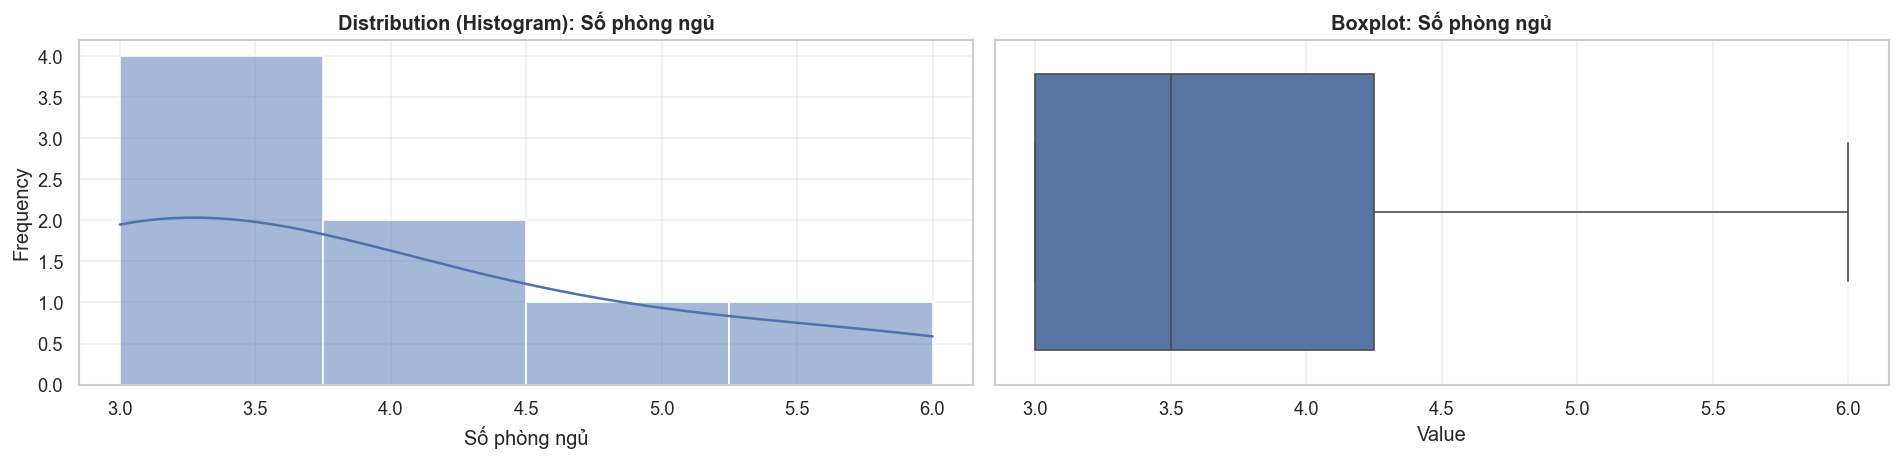

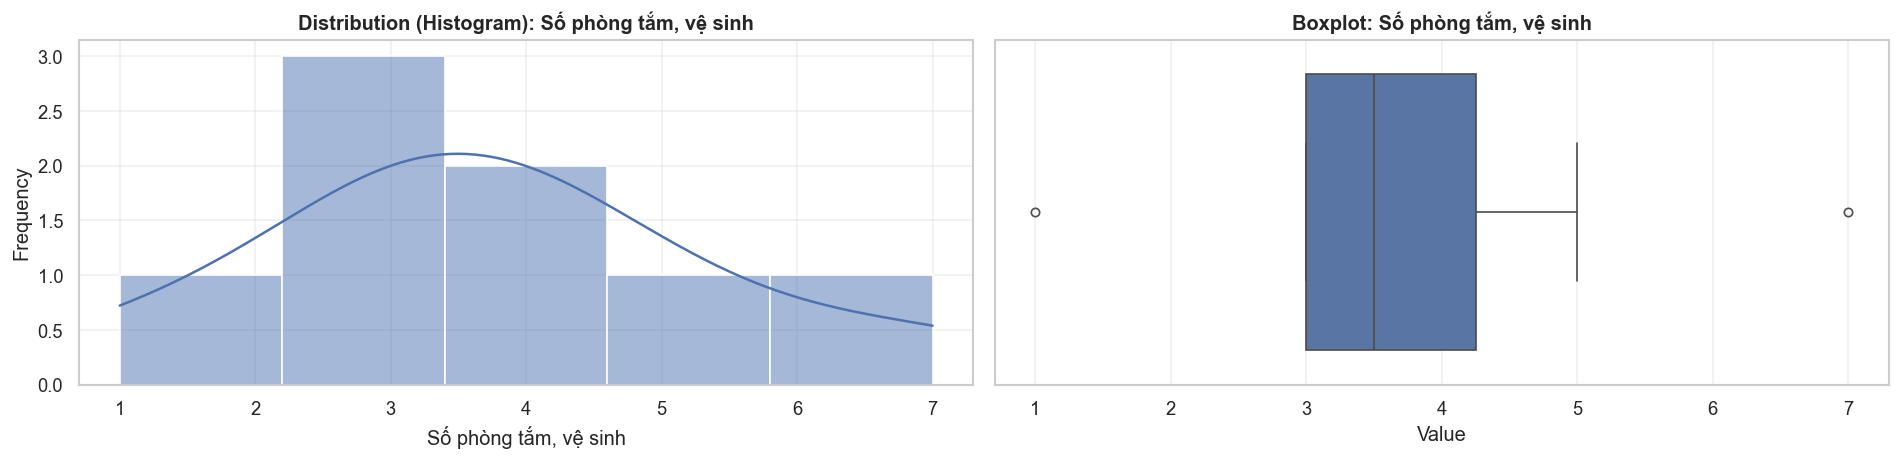

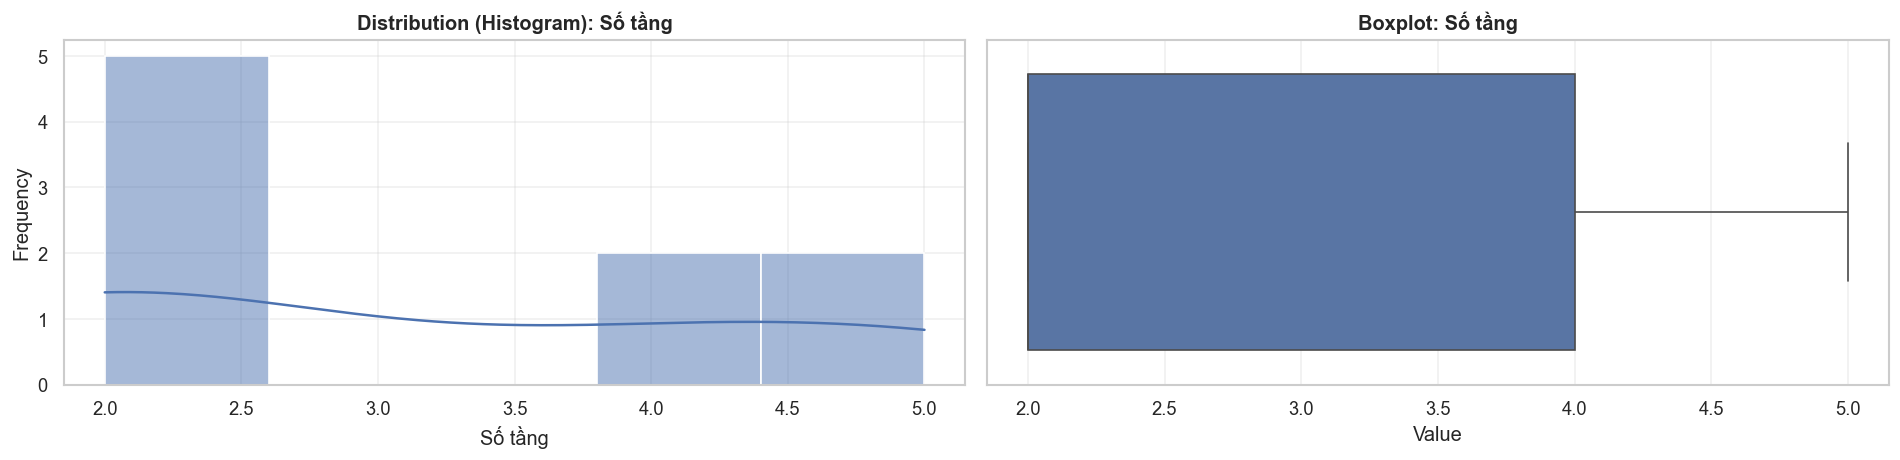

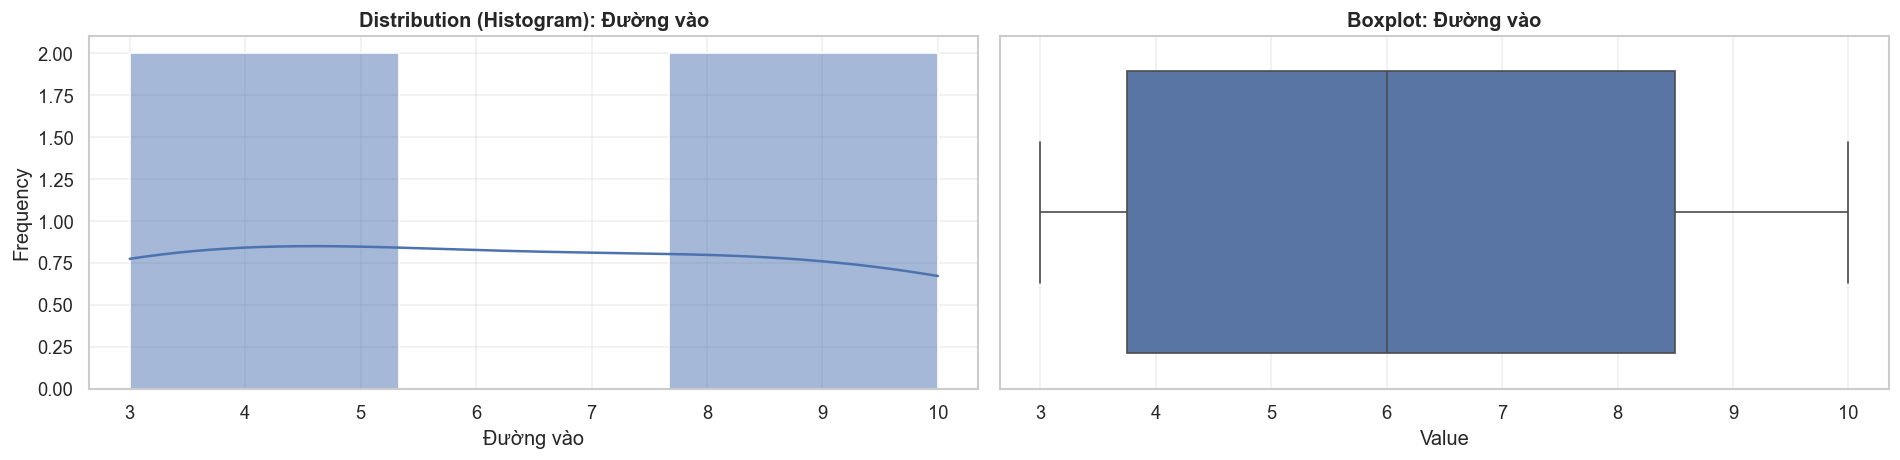

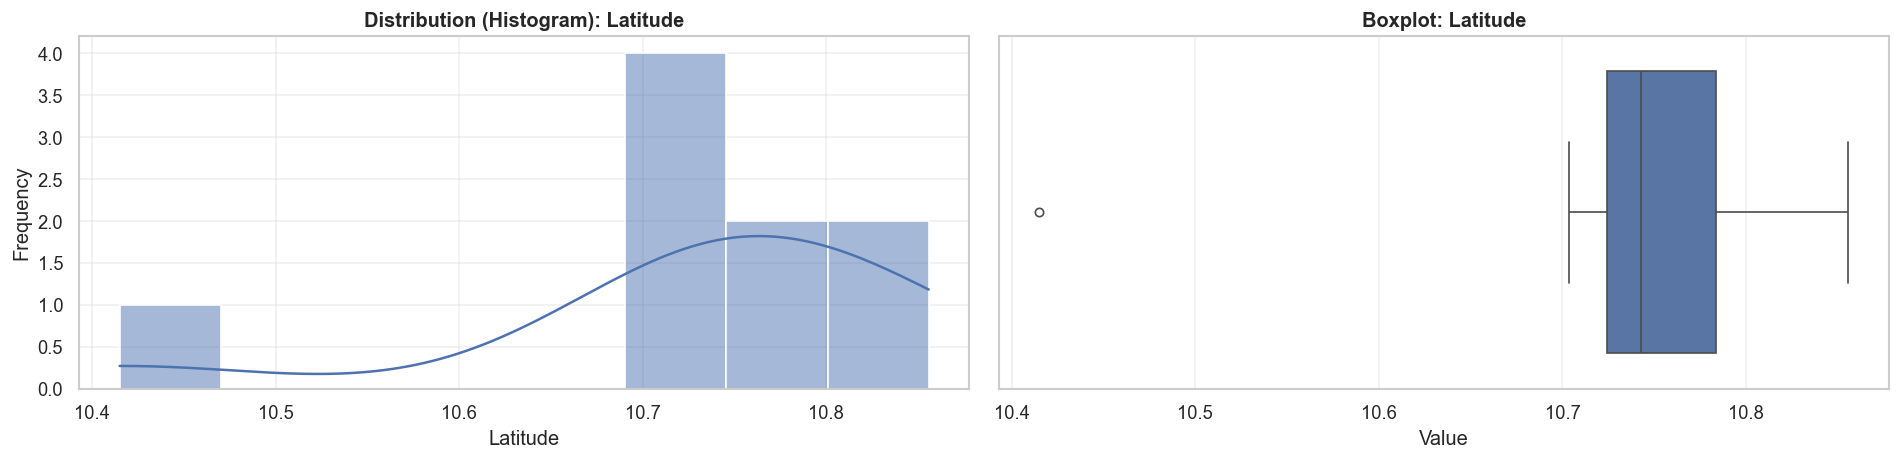

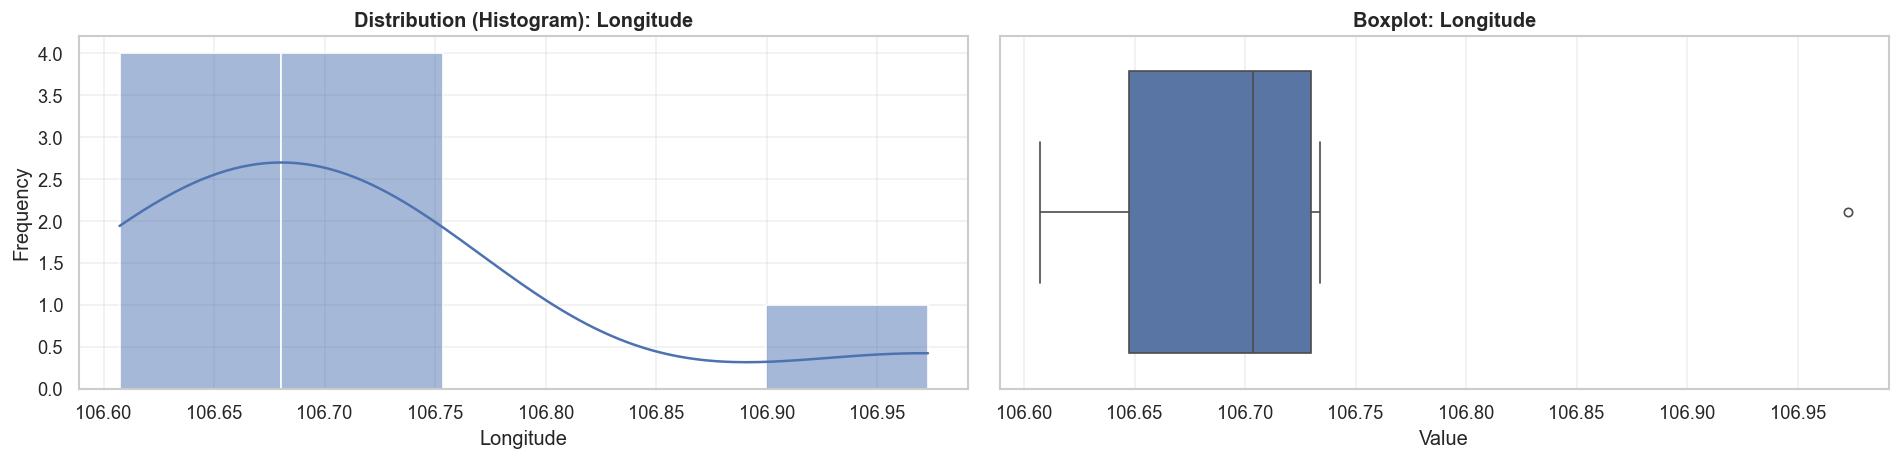

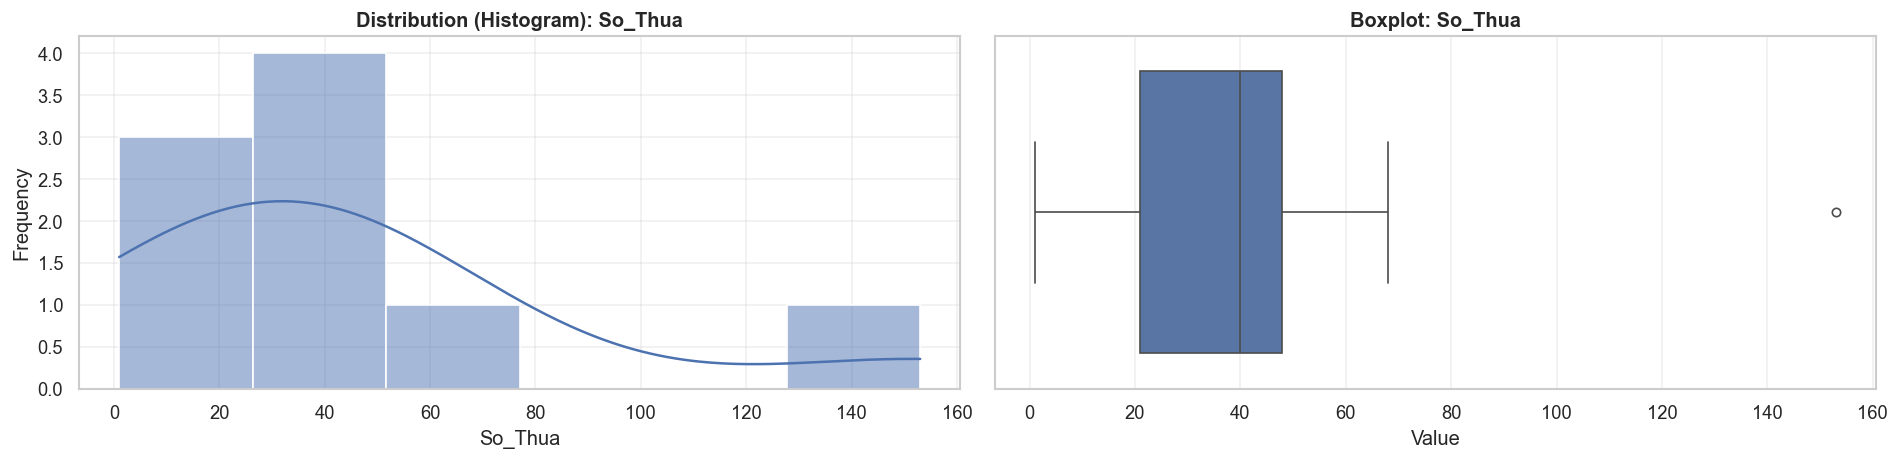

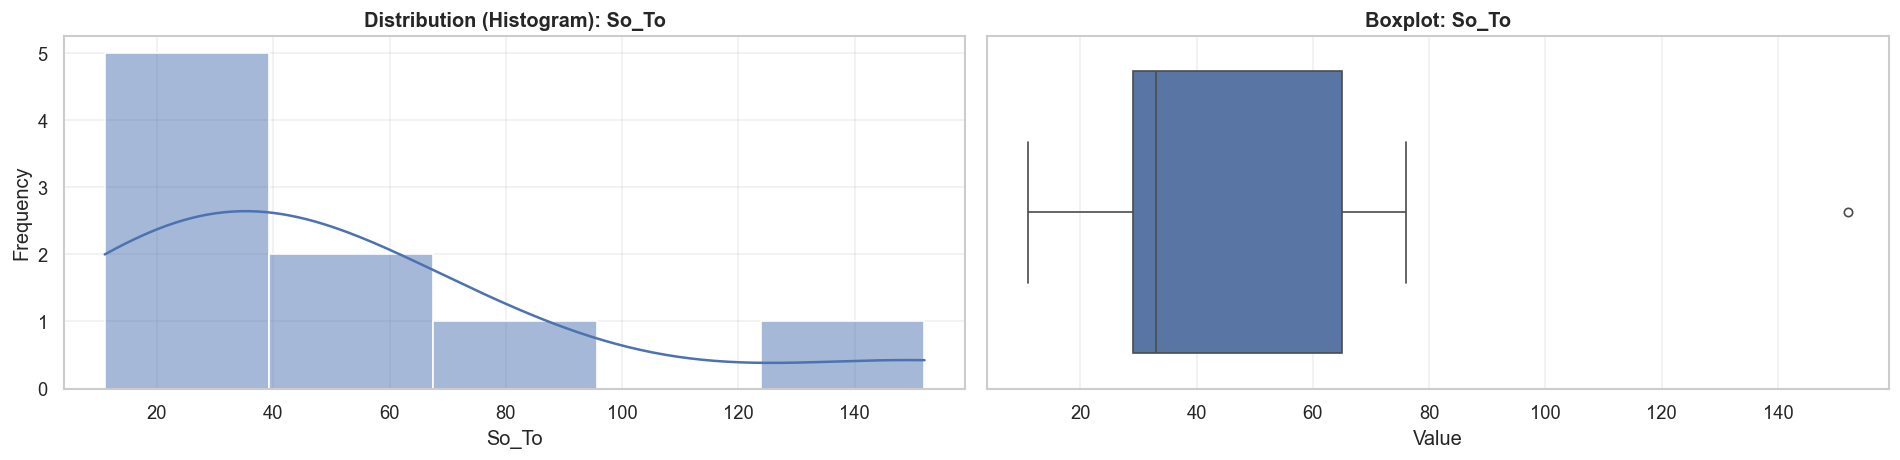

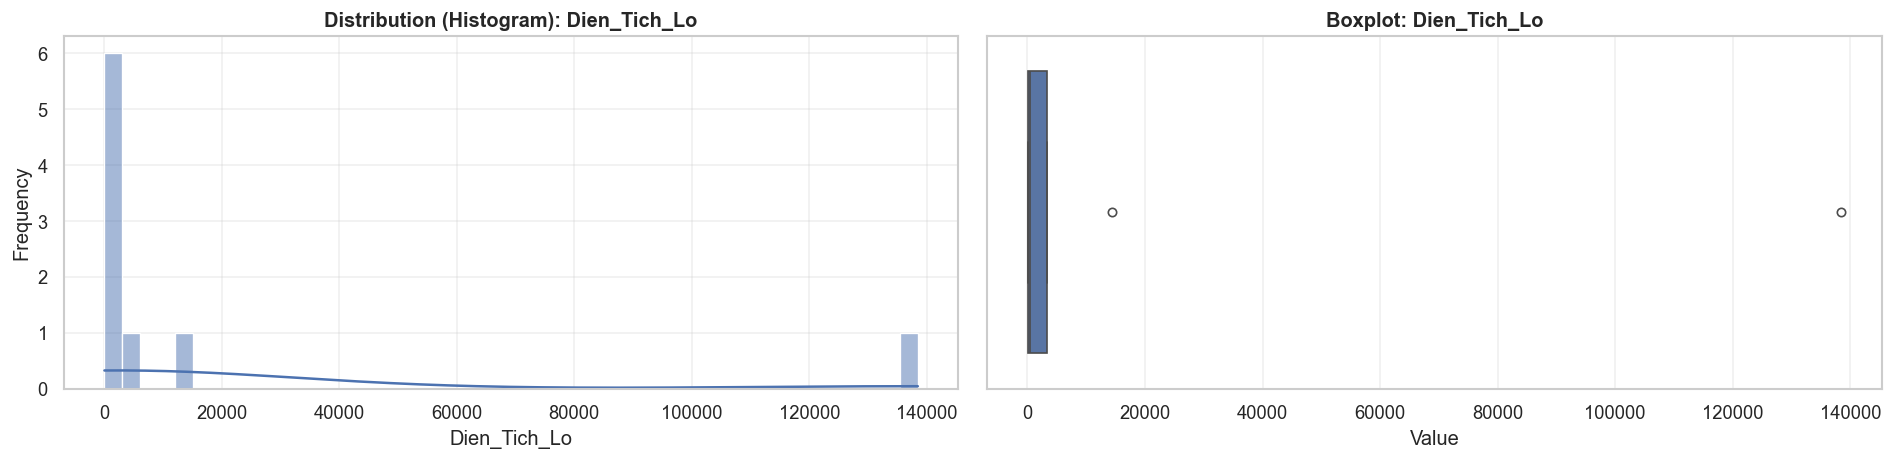

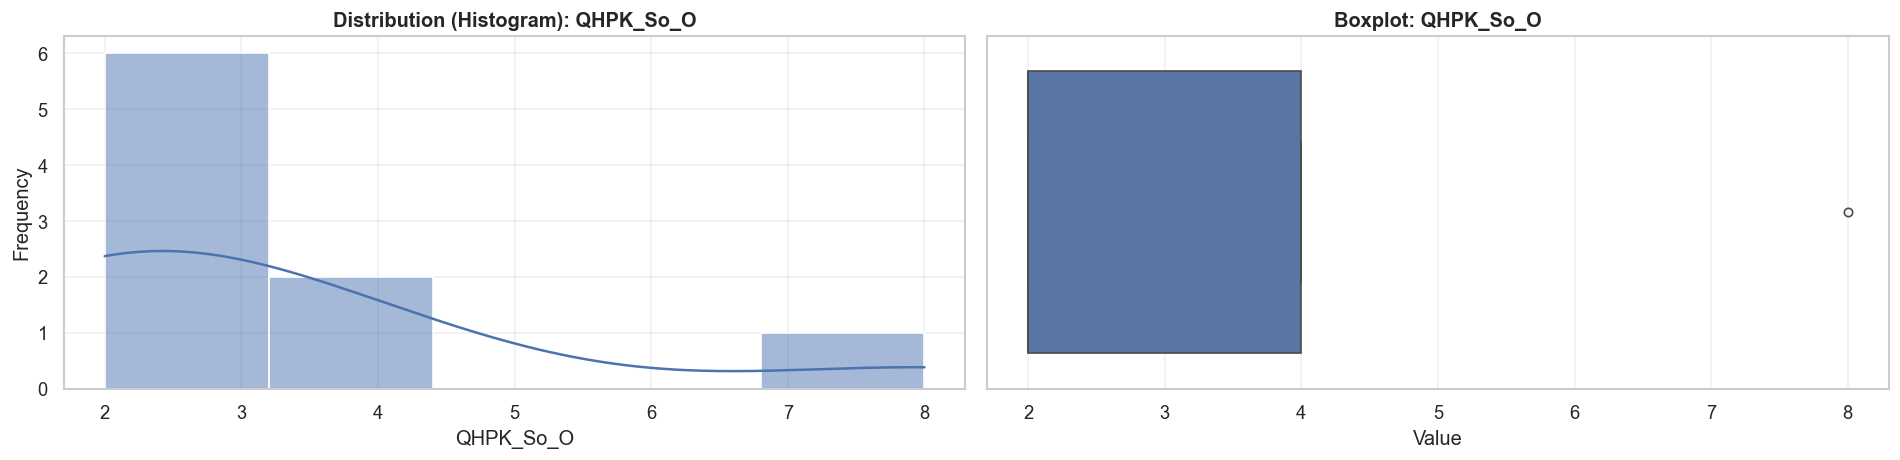

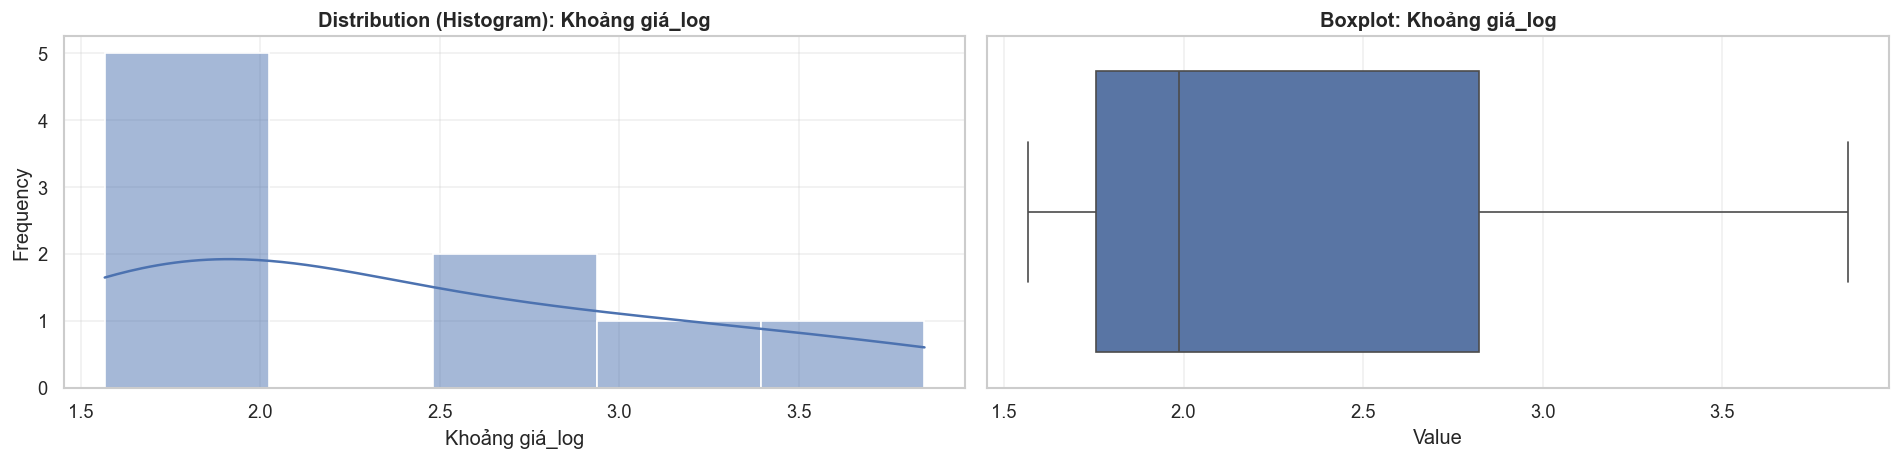

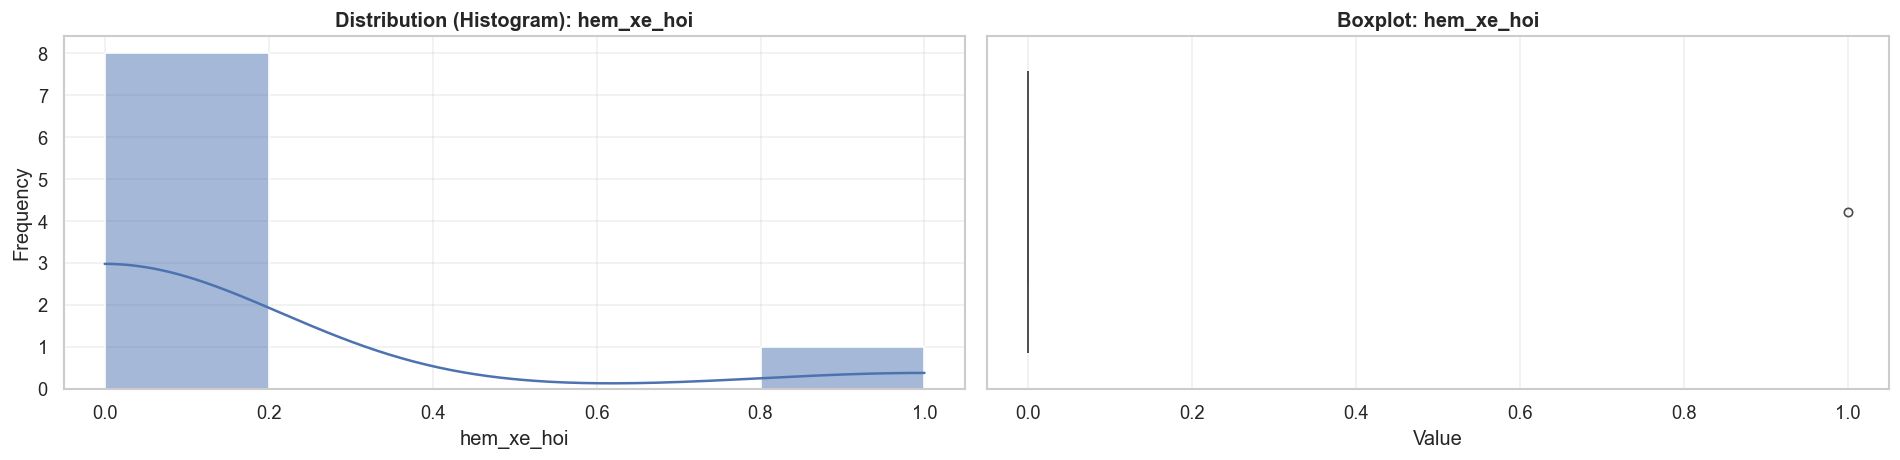

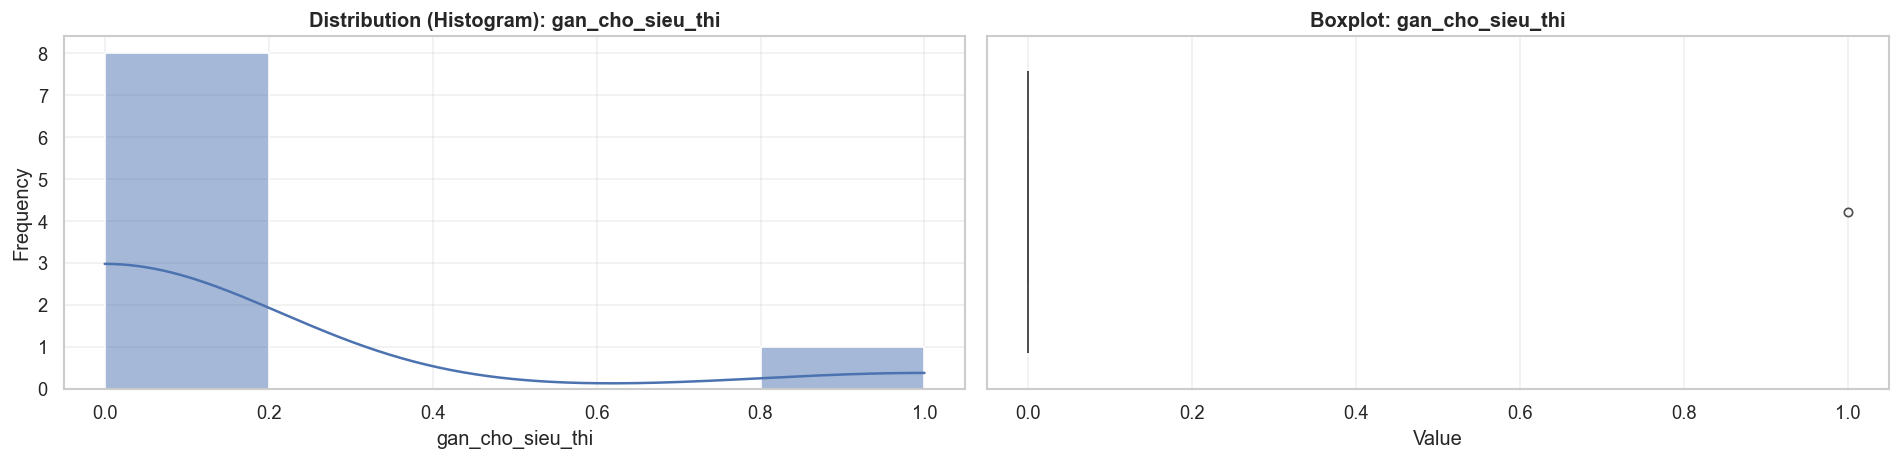

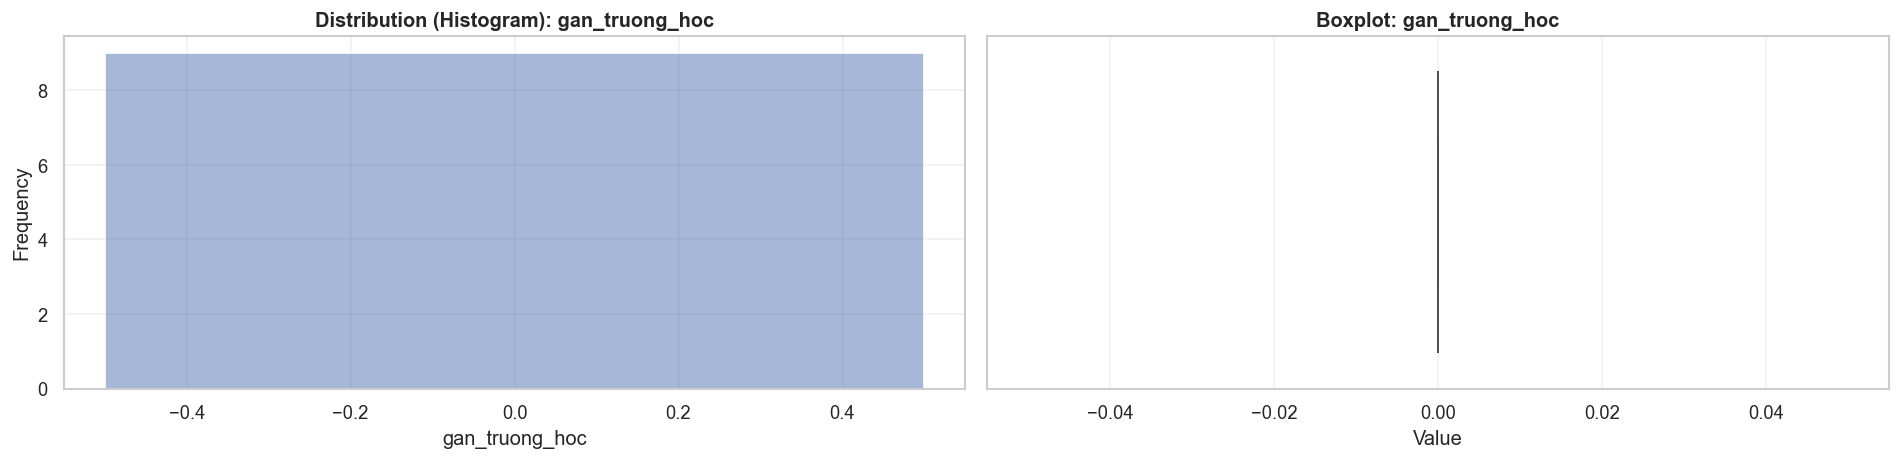

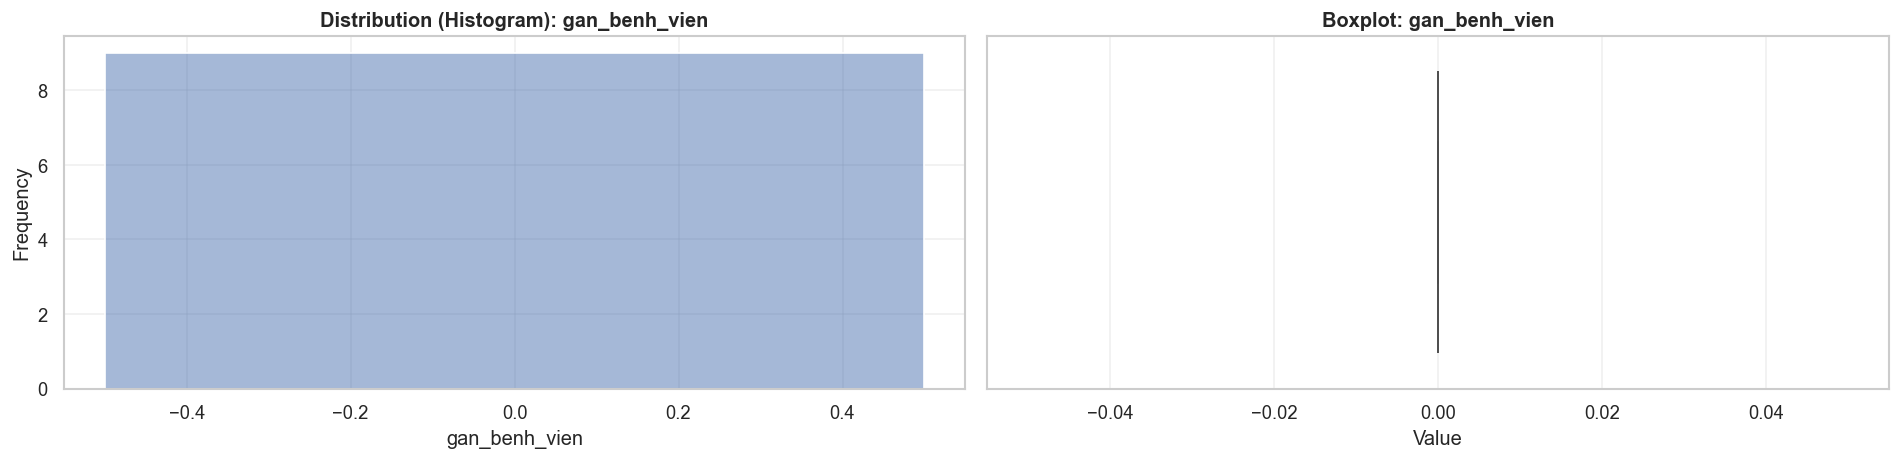

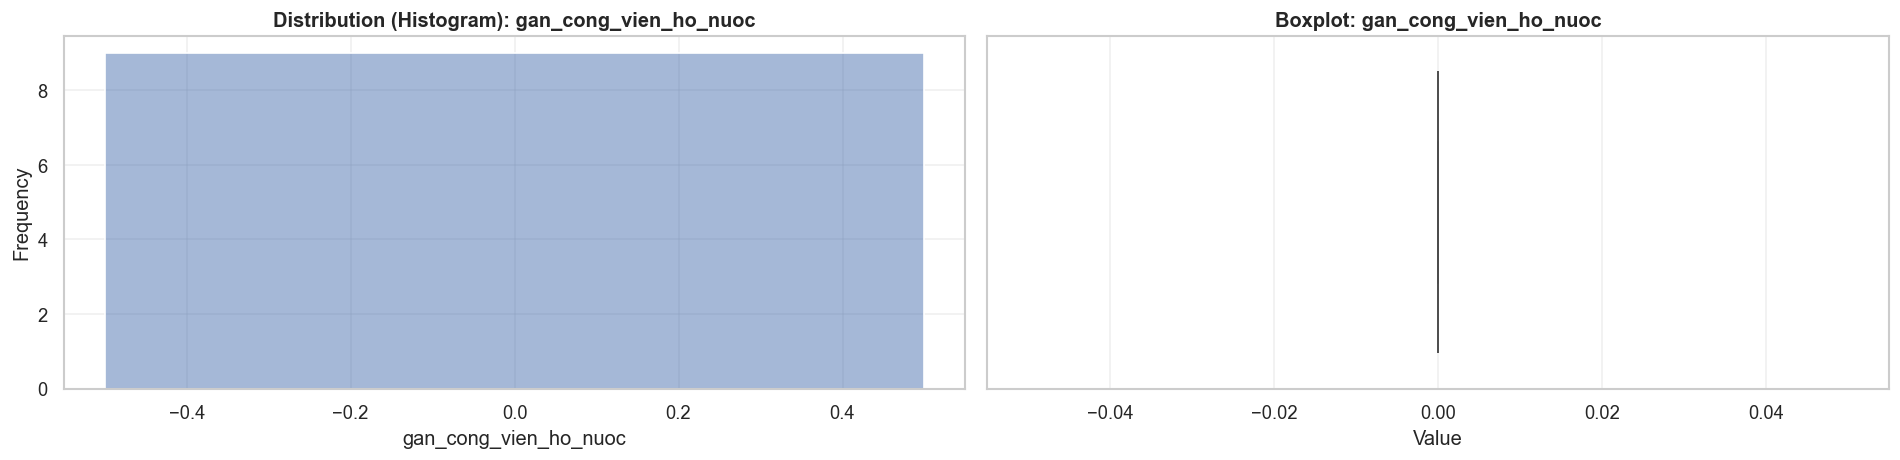

📝 VISUALIZING 3 CATEGORICAL FEATURES...
------------------------------------------------------------


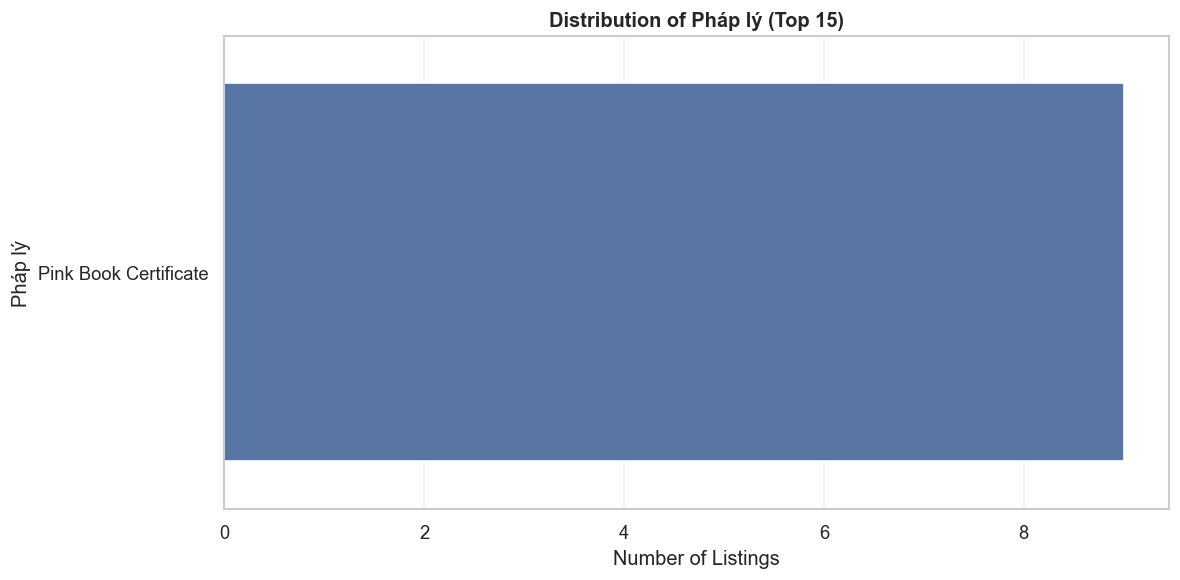

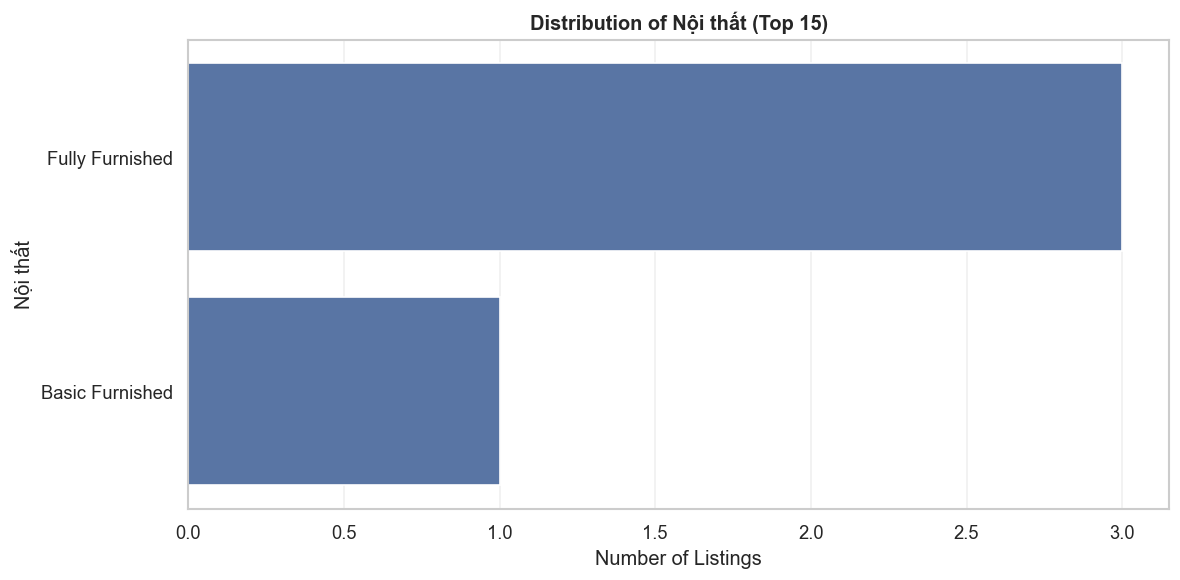

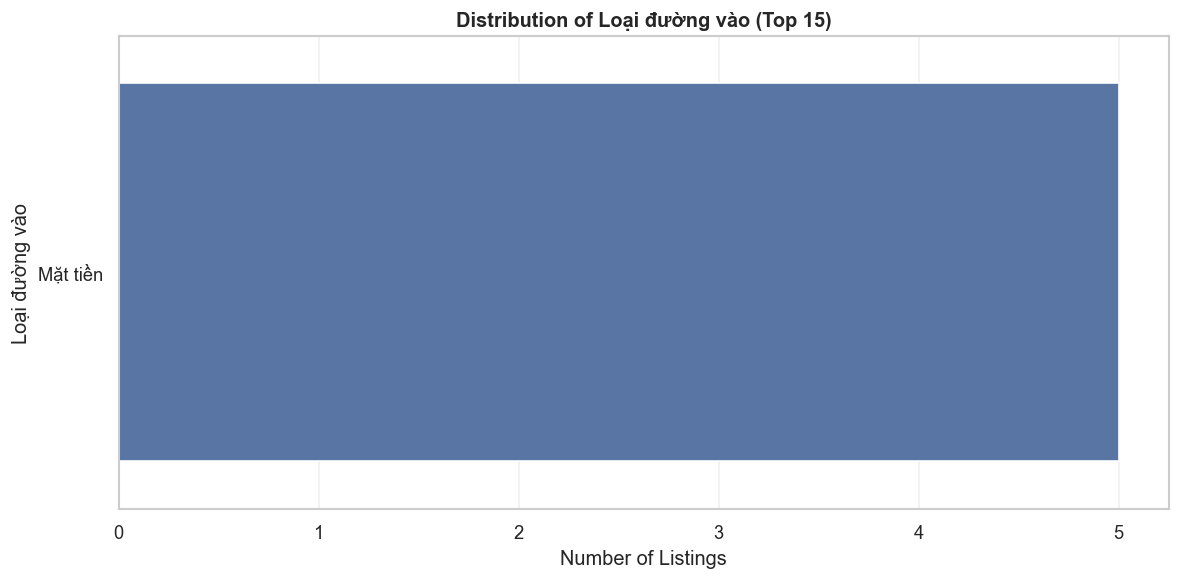

In [249]:

numeric_columns = (
    df.select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_columns = (
    df.select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

print(
    f"📊 VISUALIZING {len(numeric_columns)} "
    f"NUMERICAL FEATURES (OUTLIER ANALYSIS)..."
)

print("-" * 60)

for column in numeric_columns:

    clean_data = (
        df[column]
        .dropna()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 4)
    )

    sns.histplot(
        clean_data,
        kde=True,
        ax=axes[0],
        edgecolor='white'
    )

    axes[0].set_title(
        f'Distribution (Histogram): {column}',
        fontweight='bold'
    )

    axes[0].set_ylabel(
        'Frequency'
    )

    sns.boxplot(
        x=clean_data,
        ax=axes[1],
        fliersize=5
    )

    axes[1].set_title(
        f'Boxplot: {column}',
        fontweight='bold'
    )

    axes[1].set_xlabel(
        'Value'
    )

    plt.tight_layout()
    plt.show()

categorical_columns_to_plot = [
    'Pháp lý',
    'Nội thất',
    'Loại đường vào',
    'Đường',
    'Phường/Xã/Thị Trấn',
    'Quận'
]

available_columns = [
    column
    for column in categorical_columns_to_plot
    if column in df.columns
]

if len(available_columns) > 0:

    print(
        f"📝 VISUALIZING "
        f"{len(available_columns)} "
        f"CATEGORICAL FEATURES..."
    )

    print("-" * 60)

    for column in available_columns:

        clean_data = (
            df[column]
            .dropna()
        )

        if len(clean_data) > 0:

            plt.figure(
                figsize=(10, 5)
            )

            top_categories = (
                clean_data
                .value_counts()
                .nlargest(15)
                .index
            )

            sns.countplot(
                y=clean_data,
                order=top_categories
            )

            plt.title(
                f'Distribution of {column} (Top 15)',
                fontweight='bold'
            )

            plt.xlabel(
                'Number of Listings'
            )

            plt.ylabel(
                column
            )

            plt.tight_layout()

            plt.show()

        else:

            print(
                f"⚠️ Column '{column}' "
                f"contains no valid observations."
            )

else:

    print(
        "No requested categorical "
        "features were found in the dataset."
    )


In [250]:
print(df.columns)


Index(['Link', 'Địa chỉ', 'Khoảng giá', 'Diện tích', 'Số phòng ngủ',
       'Số phòng tắm, vệ sinh', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất',
       'Latitude', 'Longitude', 'Mô tả', 'Loại đường vào', 'Quan_Huyen',
       'Phuong_Xa', 'So_Thua', 'So_To', 'Dien_Tich_Lo', 'Ten_Do_An',
       'QHPK_So_O', 'QHPK_Chuc_Nang', 'QHPK_Dien_Tich', 'QHPK_Ty_Le',
       'QHPK_Ma_QU', 'QHPK_Ma_O_Pho', 'Trang_Thai', 'Khoảng giá_log',
       'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc'],
      dtype='object')


### Split train/test (Avoid Data Leakage)


In [251]:
from sklearn.model_selection import train_test_split

target_column = 'Khoảng giá'

X = df.drop(
    columns=[target_column]
)

y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    " Dataset split completed successfully!"
)

print("-" * 50)

print(
    f"Training Set : "
    f"X={X_train.shape}, "
    f"y={y_train.shape}"
)

print(
    f"Testing Set  : "
    f"X={X_test.shape}, "
    f"y={y_test.shape}"
)


 Dataset split completed successfully!
--------------------------------------------------
Training Set : X=(7, 32), y=(7,)
Testing Set  : X=(2, 32), y=(2,)


Correlation matrix before processing

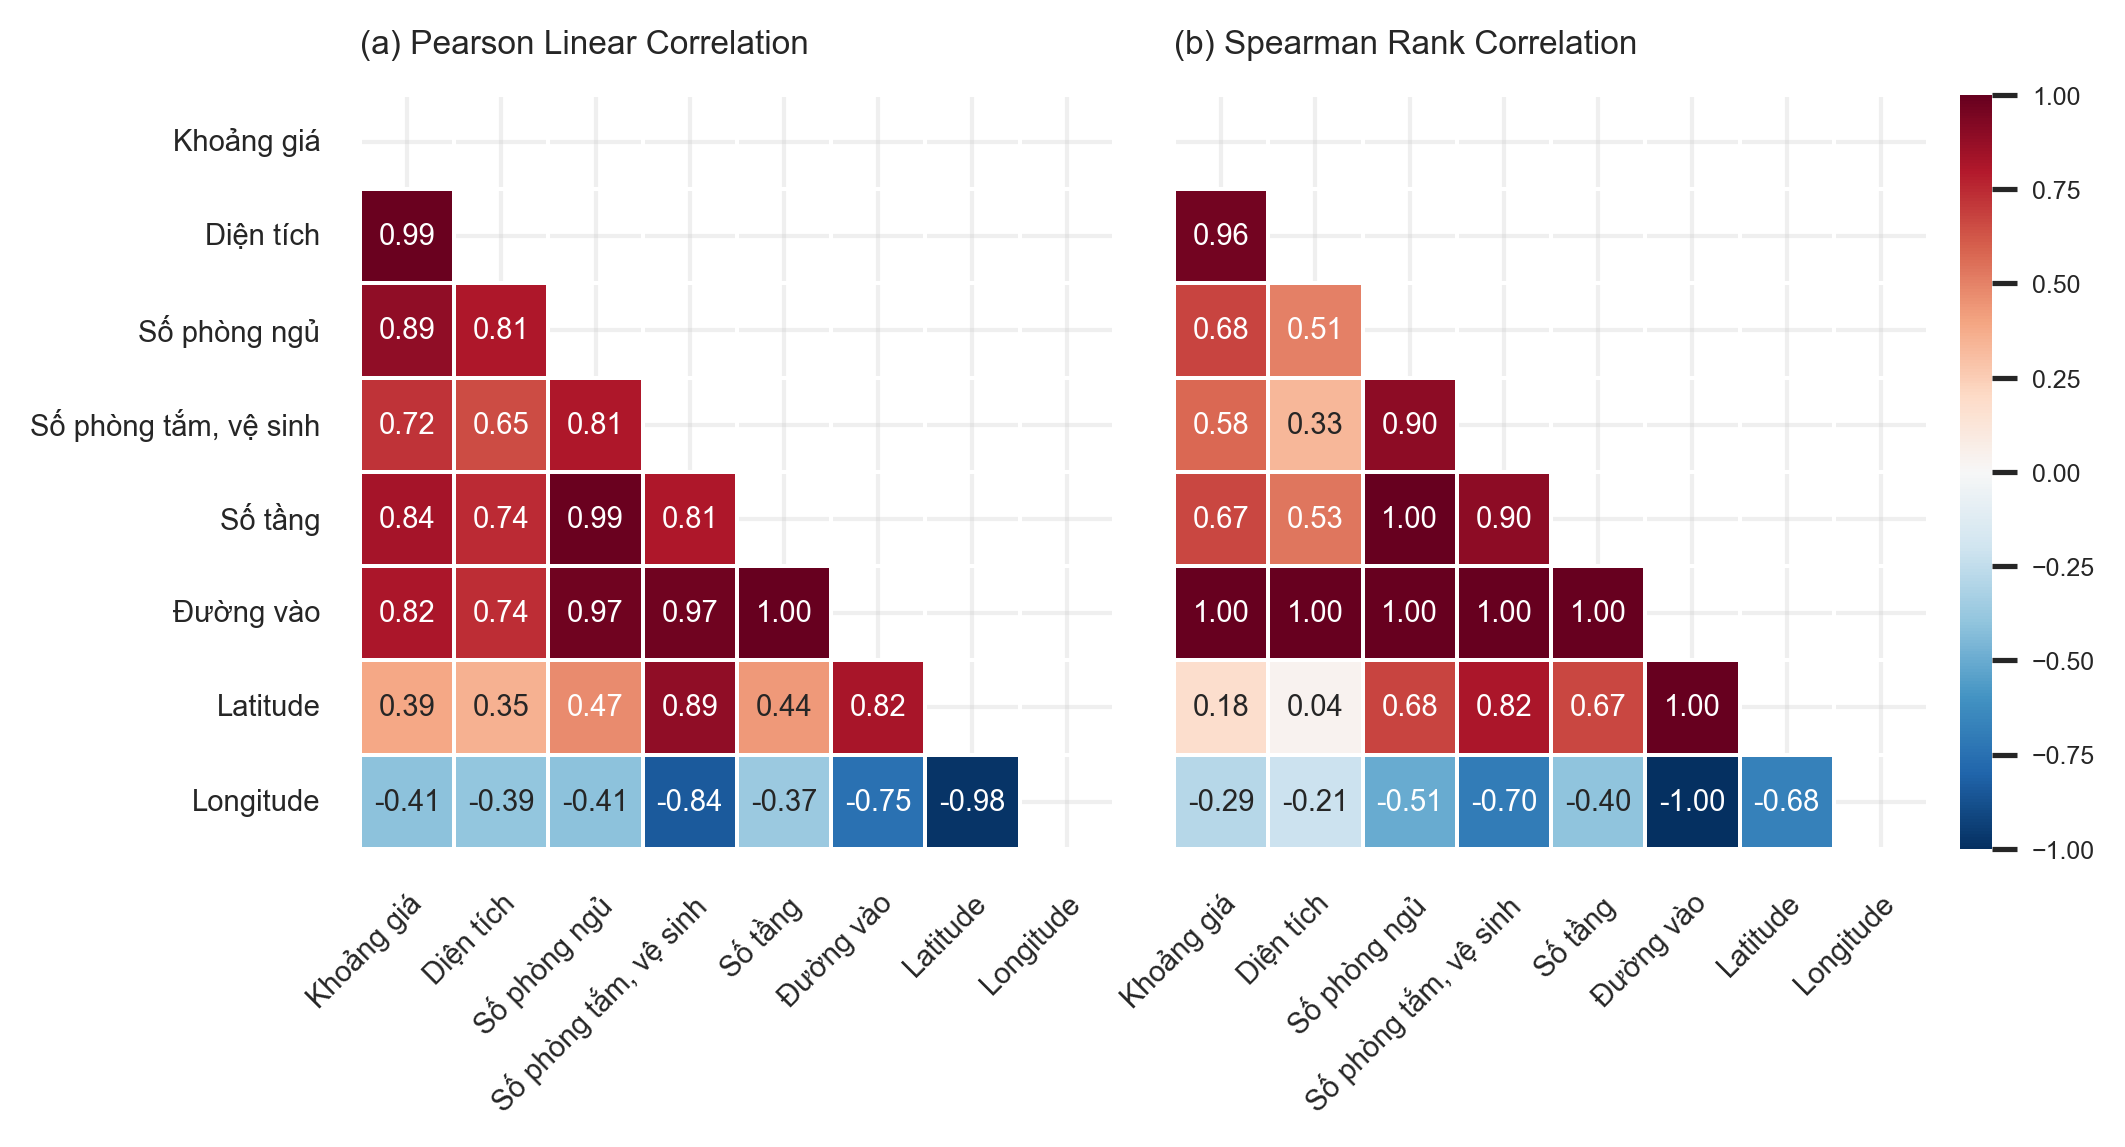

In [252]:

training_data = pd.concat(
    [X_train, y_train],
    axis=1
)

selected_features = [
    'Khoảng giá',
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng',
    'Đường vào',
    'Latitude',
    'Longitude'
]

available_features = [
    feature
    for feature in selected_features
    if feature in training_data.columns
]

analysis_data = (
    training_data[available_features]
    .select_dtypes(include=[np.number])
)

pearson_correlation = analysis_data.corr(
    method='pearson'
)

spearman_correlation = analysis_data.corr(
    method='spearman'
)

pearson_mask = np.triu(
    np.ones_like(
        pearson_correlation,
        dtype=bool
    )
)

spearman_mask = np.triu(
    np.ones_like(
        spearman_correlation,
        dtype=bool
    )
)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [
        'Arial',
        'Helvetica',
        'DejaVu Sans'
    ],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.16, 4.5),
    dpi=300,
    sharey=True
)

heatmap_settings = {
    'cmap': 'RdBu_r',
    'vmin': -1,
    'vmax': 1,
    'square': True,
    'linewidths': 0.5,
    'linecolor': 'white',
    'annot': True,
    'fmt': '.2f',
    'annot_kws': {
        'size': 7
    },
    'cbar': False
}

sns.heatmap(
    pearson_correlation,
    mask=pearson_mask,
    ax=axes[0],
    **heatmap_settings
)

axes[0].set_title(
    '(a) Pearson Linear Correlation',
    loc='left',
    pad=10
)

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45,
    ha='right',
    rotation_mode='anchor'
)

axes[0].set_yticklabels(
    axes[0].get_yticklabels(),
    rotation=0
)

axes[0].tick_params(
    bottom=False,
    left=False
)

sns.heatmap(
    spearman_correlation,
    mask=spearman_mask,
    ax=axes[1],
    **heatmap_settings
)

axes[1].set_title(
    '(b) Spearman Rank Correlation',
    loc='left',
    pad=10
)

axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=45,
    ha='right',
    rotation_mode='anchor'
)

axes[1].tick_params(
    bottom=False,
    left=False
)

plt.subplots_adjust(
    left=0.15,
    right=0.88,
    top=0.90,
    bottom=0.30,
    wspace=0.08
)

fig.canvas.draw()

position = axes[1].get_position(
    original=False
)

colorbar_axis = fig.add_axes([
    position.x1 + 0.015,
    position.y0,
    0.015,
    position.height
])

colorbar = fig.colorbar(
    axes[1].collections[0],
    cax=colorbar_axis
)

colorbar.ax.tick_params(
    labelsize=6
)

colorbar.outline.set_visible(
    False
)

plt.show()


-The values ​​in the Spearman matrix are much higher than the Pearson values. Therefore this data has a nonlinear relationship. If you have to fill in the gaps with models, linear regression models will not be effective.
-Instead, decision tree models such as Random Forest or XGBoost/LightGBM are more suitable for this dataset.

Correlation between the number of missing and other features.

⚠️ Skipped non-numeric or unavailable features: {'Pháp lý', 'Nội thất', 'Quan_Huyen', 'Phuong_Xa'}


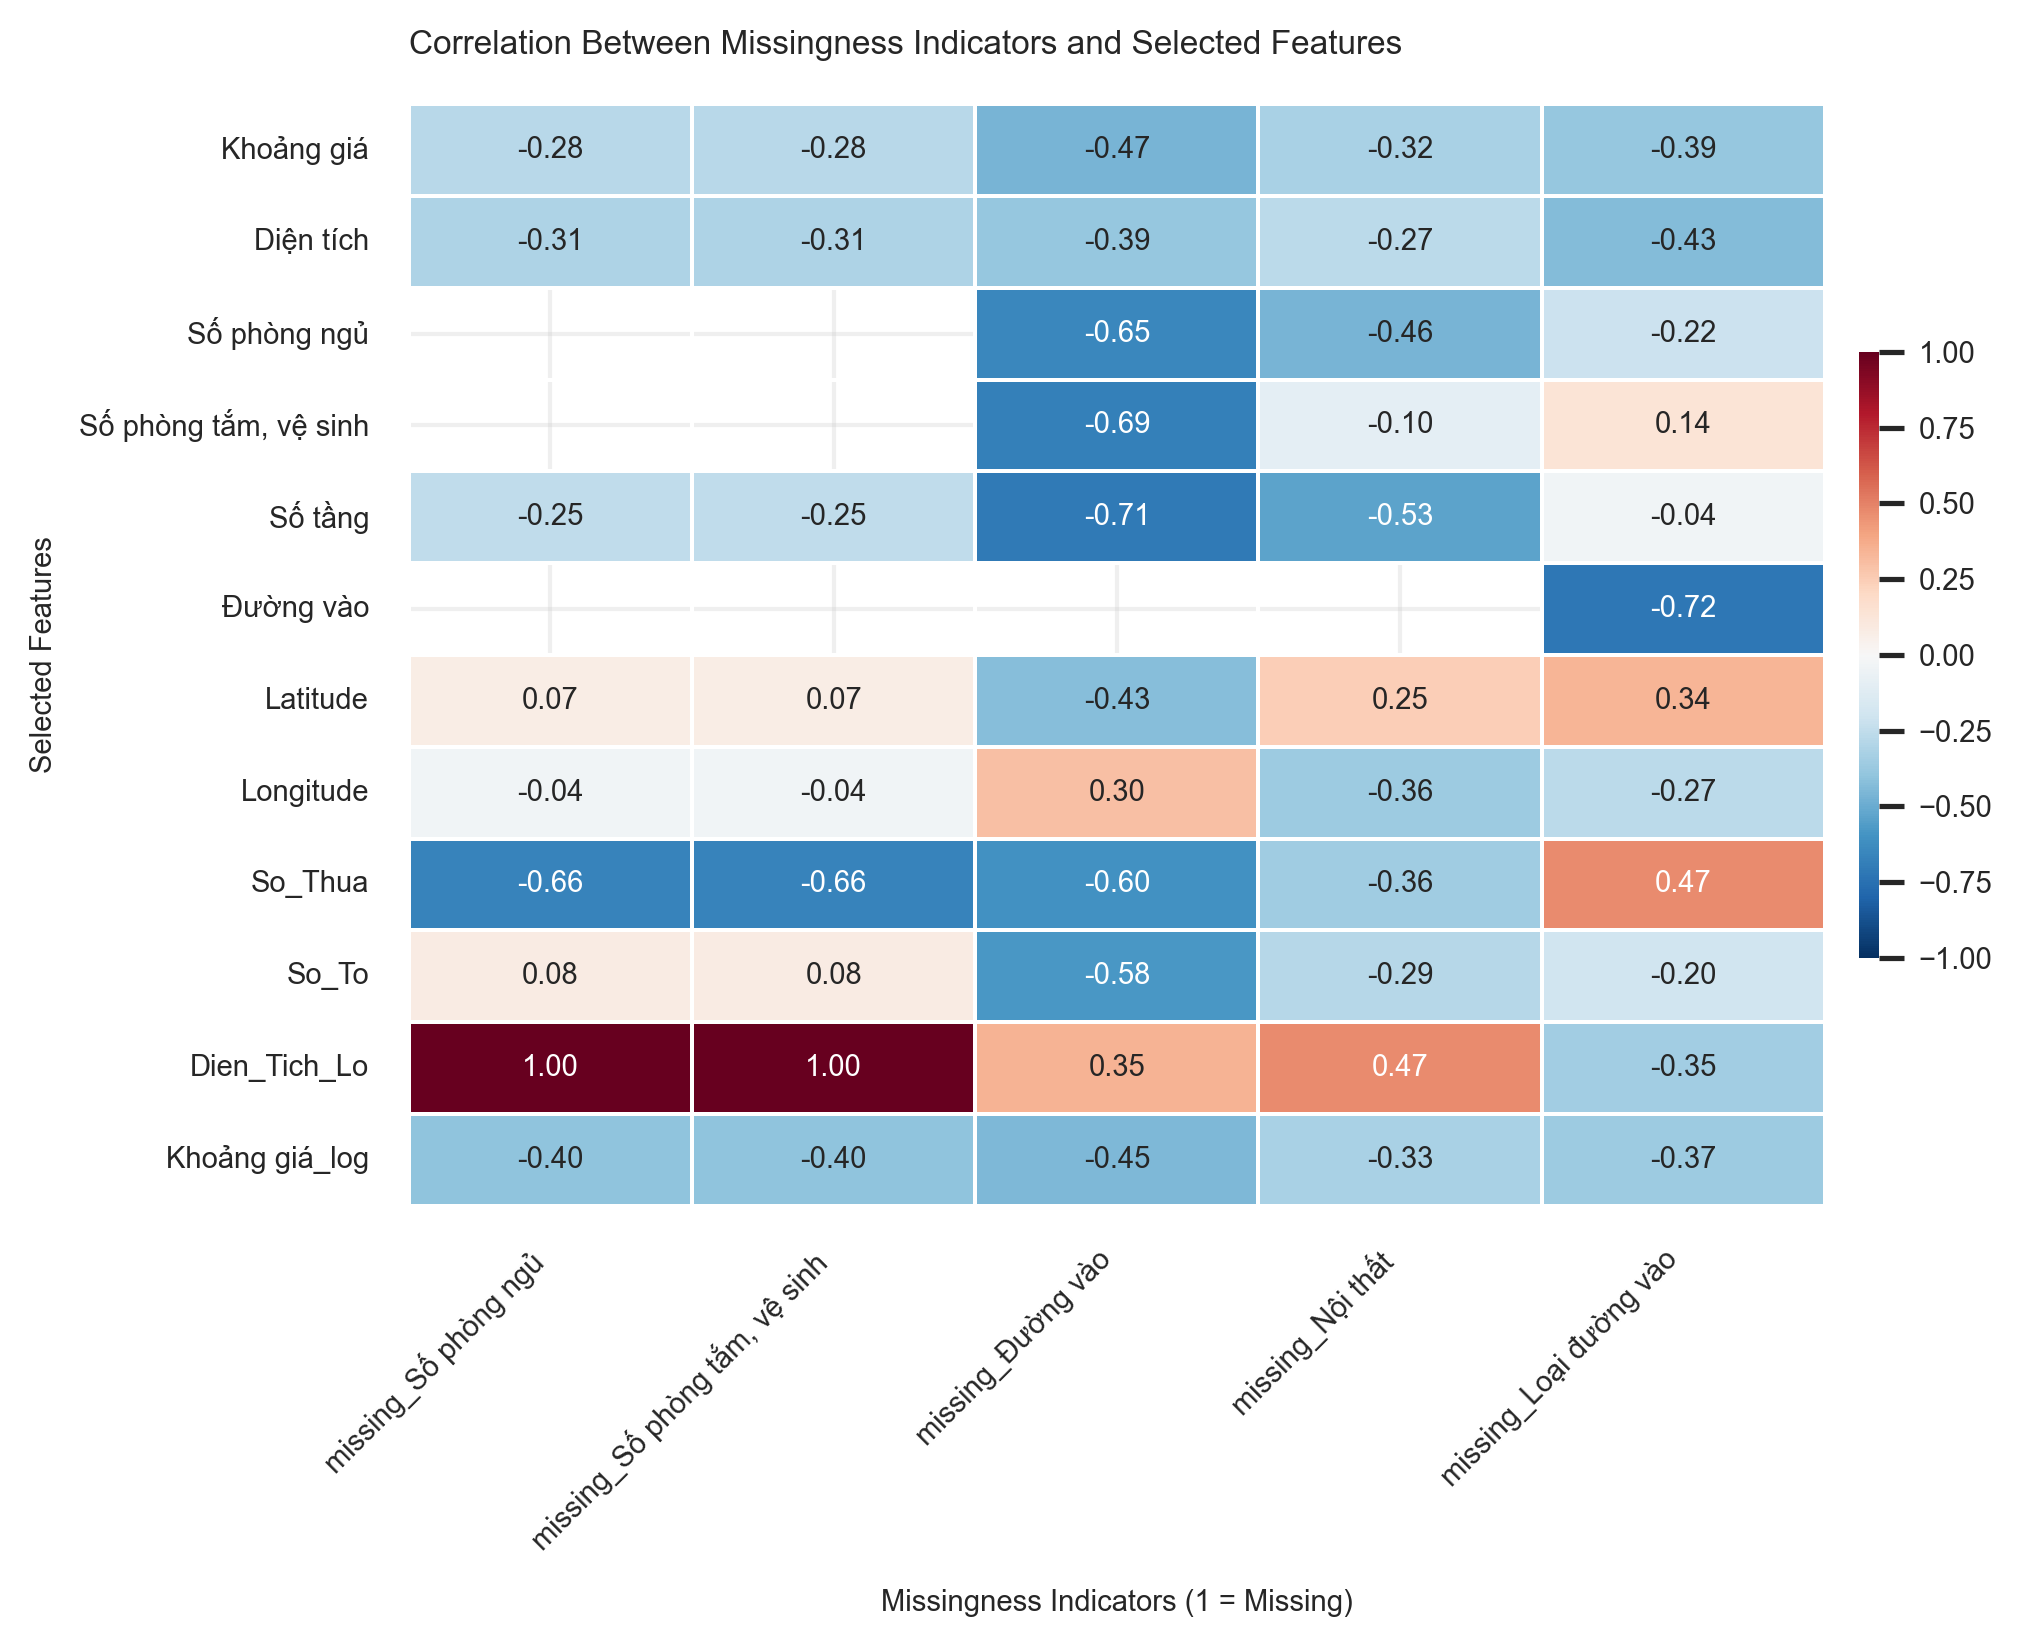

In [253]:

training_data = pd.concat(
    [X_train, y_train],
    axis=1
)

selected_features = [
    'Khoảng giá',
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng',
    'Đường vào',
    'Pháp lý',
    'Nội thất',
    'Latitude',
    'Longitude',
    'Quan_Huyen',
    'Phuong_Xa',
    'So_Thua',
    'So_To',
    'Dien_Tich_Lo',
    'Khoảng giá_log'
]

columns_with_missing = [
    column
    for column in training_data.columns
    if training_data[column].isnull().sum() > 0
]

if not columns_with_missing:

    print(
        " No missing values were detected "
        "in the training dataset."
    )

else:

    for column in columns_with_missing:

        training_data[
            f'missing_{column}'
        ] = (
            training_data[column]
            .isnull()
            .astype(int)
        )

    missing_indicators = [
        f'missing_{column}'
        for column in columns_with_missing
    ]

    available_features = [
        feature
        for feature in selected_features
        if feature in training_data.columns
    ]

    numerical_features = (
        training_data[available_features]
        .select_dtypes(include=[np.number])
        .columns
        .tolist()
    )

    excluded_features = (
        set(selected_features)
        - set(numerical_features)
    )

    if excluded_features:

        print(
            "⚠️ Skipped non-numeric or "
            f"unavailable features: "
            f"{excluded_features}"
        )

    correlation_matrix = (
        training_data[
            missing_indicators
            + numerical_features
        ]
        .corr()
    )

    correlation_subset = (
        correlation_matrix.loc[
            numerical_features,
            missing_indicators
        ]
    )

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Arial',
            'Helvetica',
            'DejaVu Sans'
        ],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': 7,
        'axes.titlesize': 8,
        'axes.labelsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'legend.fontsize': 7
    })

    fig, ax = plt.subplots(
        figsize=(7.16, 5.5),
        dpi=300
    )

    sns.heatmap(
        correlation_subset,
        annot=True,
        cmap='RdBu_r',
        vmin=-1,
        vmax=1,
        fmt='.2f',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 7},
        cbar_kws={
            'shrink': 0.55,
            'aspect': 30,
            'pad': 0.02
        },
        ax=ax
    )

    ax.set_title(
        'Correlation Between Missingness Indicators and Selected Features',
        loc='left',
        pad=12
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0
    )

    ax.set_ylabel(
        'Selected Features',
        labelpad=5
    )

    ax.set_xlabel(
        'Missingness Indicators (1 = Missing)',
        labelpad=8
    )

    ax.tick_params(
        bottom=False,
        left=False
    )

    colorbar = (
        ax.collections[0]
        .colorbar
    )

    colorbar.ax.tick_params(
        labelsize=7
    )

    plt.tight_layout()

    plt.show()


In [254]:
from scipy.stats import chi2

def littles_mcar_test(dataset):

    data = (
        dataset
        .select_dtypes(include=[np.number])
        .copy()
    )

    data = data.dropna(
        how='all',
        axis=1
    )

    overall_mean = data.mean()
    overall_covariance = data.cov()

    if overall_covariance.isnull().any().any():

        complete_cases = data.dropna()

        overall_covariance = (
            complete_cases.cov()
        )

        overall_mean = (
            complete_cases.mean()
        )

    missing_patterns = (
        data.isnull()
        .astype(int)
    )

    unique_patterns = (
        missing_patterns
        .drop_duplicates()
    )

    chi_square_statistic = 0
    total_degrees_of_freedom = 0

    total_variables = data.shape[1]

    for _, pattern in unique_patterns.iterrows():

        pattern_rows = missing_patterns[
            (missing_patterns == pattern)
            .all(axis=1)
        ].index

        pattern_size = len(pattern_rows)

        observed_variables = (
            pattern[
                pattern == 0
            ]
            .index
            .tolist()
        )

        observed_count = (
            len(observed_variables)
        )

        if (
            observed_count == 0
            or (
                observed_count == total_variables
                and len(unique_patterns) == 1
            )
        ):
            continue

        pattern_mean = (
            data.loc[
                pattern_rows,
                observed_variables
            ]
            .mean()
        )

        overall_mean_subset = (
            overall_mean[
                observed_variables
            ]
        )

        covariance_subset = (
            overall_covariance.loc[
                observed_variables,
                observed_variables
            ]
        )

        try:

            inverse_covariance = (
                np.linalg.inv(
                    covariance_subset
                )
            )

            mean_difference = (
                pattern_mean
                - overall_mean_subset
            )

            mahalanobis_distance = (
                pattern_size
                * np.dot(
                    np.dot(
                        mean_difference,
                        inverse_covariance
                    ),
                    mean_difference
                )
            )

            chi_square_statistic += (
                mahalanobis_distance
            )

            total_degrees_of_freedom += (
                observed_count
            )

        except np.linalg.LinAlgError:
            continue

    total_degrees_of_freedom = (
        total_degrees_of_freedom
        - total_variables
    )

    if total_degrees_of_freedom <= 0:

        return (
            None,
            None,
            "Insufficient degrees of freedom for p-value estimation."
        )

    p_value = chi2.sf(
        chi_square_statistic,
        total_degrees_of_freedom
    )

    return (
        chi_square_statistic,
        total_degrees_of_freedom,
        p_value
    )


training_data = pd.concat(
    [X_train, y_train],
    axis=1
)

test_statistic, degrees_of_freedom, p_value = (
    littles_mcar_test(
        training_data
    )
)

print(
    f"{'=' * 10} "
    "LITTLE'S MCAR TEST RESULTS "
    "(TRAINING DATA ONLY) "
    f"{'=' * 10}\n"
)

if test_statistic is not None:

    print(
        "Chi-square Statistic : "
        f"{test_statistic:.4f}"
    )

    print(
        "Degrees of Freedom   : "
        f"{degrees_of_freedom}"
    )

    print(
        "P-value              : "
        f"{p_value:.6f}"
    )

    print("-" * 50)

    print(
        "\nStatistical Interpretation:"
    )

    if p_value > 0.05:

        print(
            "Accepted H₀ "
            "(p-value > 0.05)"
        )

        print(
            "Missing values can be "
            "considered Missing Completely "
            "At Random (MCAR)."
        )

        print(
            "Simple imputation methods "
            "such as Mean or Median "
            "Imputation are generally "
            "appropriate."
        )

    else:

        print(
            "Rejected H₀ "
            "(p-value ≤ 0.05)"
        )

        print(
            "Missing values are likely "
            "Missing At Random (MAR) "
            "or Missing Not At Random (MNAR)."
        )

        print(
            "The missingness mechanism "
            "appears to be systematic."
        )

        print(
            "Advanced imputation techniques "
            "such as Group-Based Imputation, "
            "KNN Imputation, MICE, or "
            "Tree-Based Imputation should "
            "be considered."
        )

else:

    print(
        f"Unable to perform the test: "
        f"{p_value}"
    )


========== LITTLE'S MCAR TEST RESULTS (TRAINING DATA ONLY) ==========

Unable to perform the test: Insufficient degrees of freedom for p-value estimation.



-High-end segment (High price, Large area) rarely imports "phòng ngủ" and "phòng tắm"
    -Signs: line Missing_Number of bedrooms and Missing_Number of bathrooms and toilets. This pair has identical behavior and is very clearly positively correlated with Price Range (0.25), Area (0.24) and especially the strongest spike in Price_log Range (0.31 and 0.32).
-Reason: In the real estate market, the high value segment often falls into project land, isolated raw villas, or rough handed over Penthouses. Sellers often only post the total area and price, not dividing the rooms, leading to data with these two columns being blank.
    -Belongs to MAR type
-Number of floors", "Entrance" and "Interior": lack of large area but less dependent:
    -Signs: The lines Missing_Number of floors, Missing_Access and Missing_Interior have light blue or gray boxes, the correlation coefficient ranges from -0.03 to 0.16 (quite weak).
    -Reason: There are some types of real estate properties that do not have entrances or number of floors.
-Can be MCAR or MNAR. However, the data collected is not about land or apartments, moreover, the "Đường vào" column (or lane/alley width) is only vital for private houses (to know if cars can enter). As for Street Houses and Shophouses, they are essentially located outside the main road frontage (usually 15m -30m wide). The missing data in the "Input Road" column is MNAR.

## 2.2 Column processing "Nội thất", "Pháp lý"

-Based on information from the correlation matrix between missing data and features: the low correlation of these 3 features with the remaining features. Therefore it belongs to the MCAR or MNAR category.
-Based on professional knowledge. The importer will deliberately hide these features if the house for sale does not have them because having these features will increase the house price and make more profit. Therefore these features will be of type MCAR.


In [255]:
imputation_rules = {
    'Nội thất': 'Trống / Nhà thô',
    'Pháp lý': 'không có'
}

def apply_imputation(dataframe, rules):

    processed_dataframe = dataframe.copy()

    for column, replacement_value in rules.items():

        if column in processed_dataframe.columns:

            processed_dataframe[column] = (
                processed_dataframe[column]
                .fillna(replacement_value)
            )

    return processed_dataframe


X_train = apply_imputation(
    X_train,
    imputation_rules
)

X_test = apply_imputation(
    X_test,
    imputation_rules
)

print(
    "Missing Value Verification After Imputation:"
)

print("-" * 40)

for column in imputation_rules:

    if column in X_train.columns:

        print(
            f"{column:15s} | "
            f"Train Missing: {X_train[column].isnull().sum()} | "
            f"Test Missing: {X_test[column].isnull().sum()}"
        )


Missing Value Verification After Imputation:
----------------------------------------
Nội thất        | Train Missing: 0 | Test Missing: 0
Pháp lý         | Train Missing: 0 | Test Missing: 0


## 2.3 Handling missing columns 'phòng tắm' and 'phòng ngủ'

1. Bathroom

-Missing quantity >5%

Vẽ phân phối của 2 cột này.

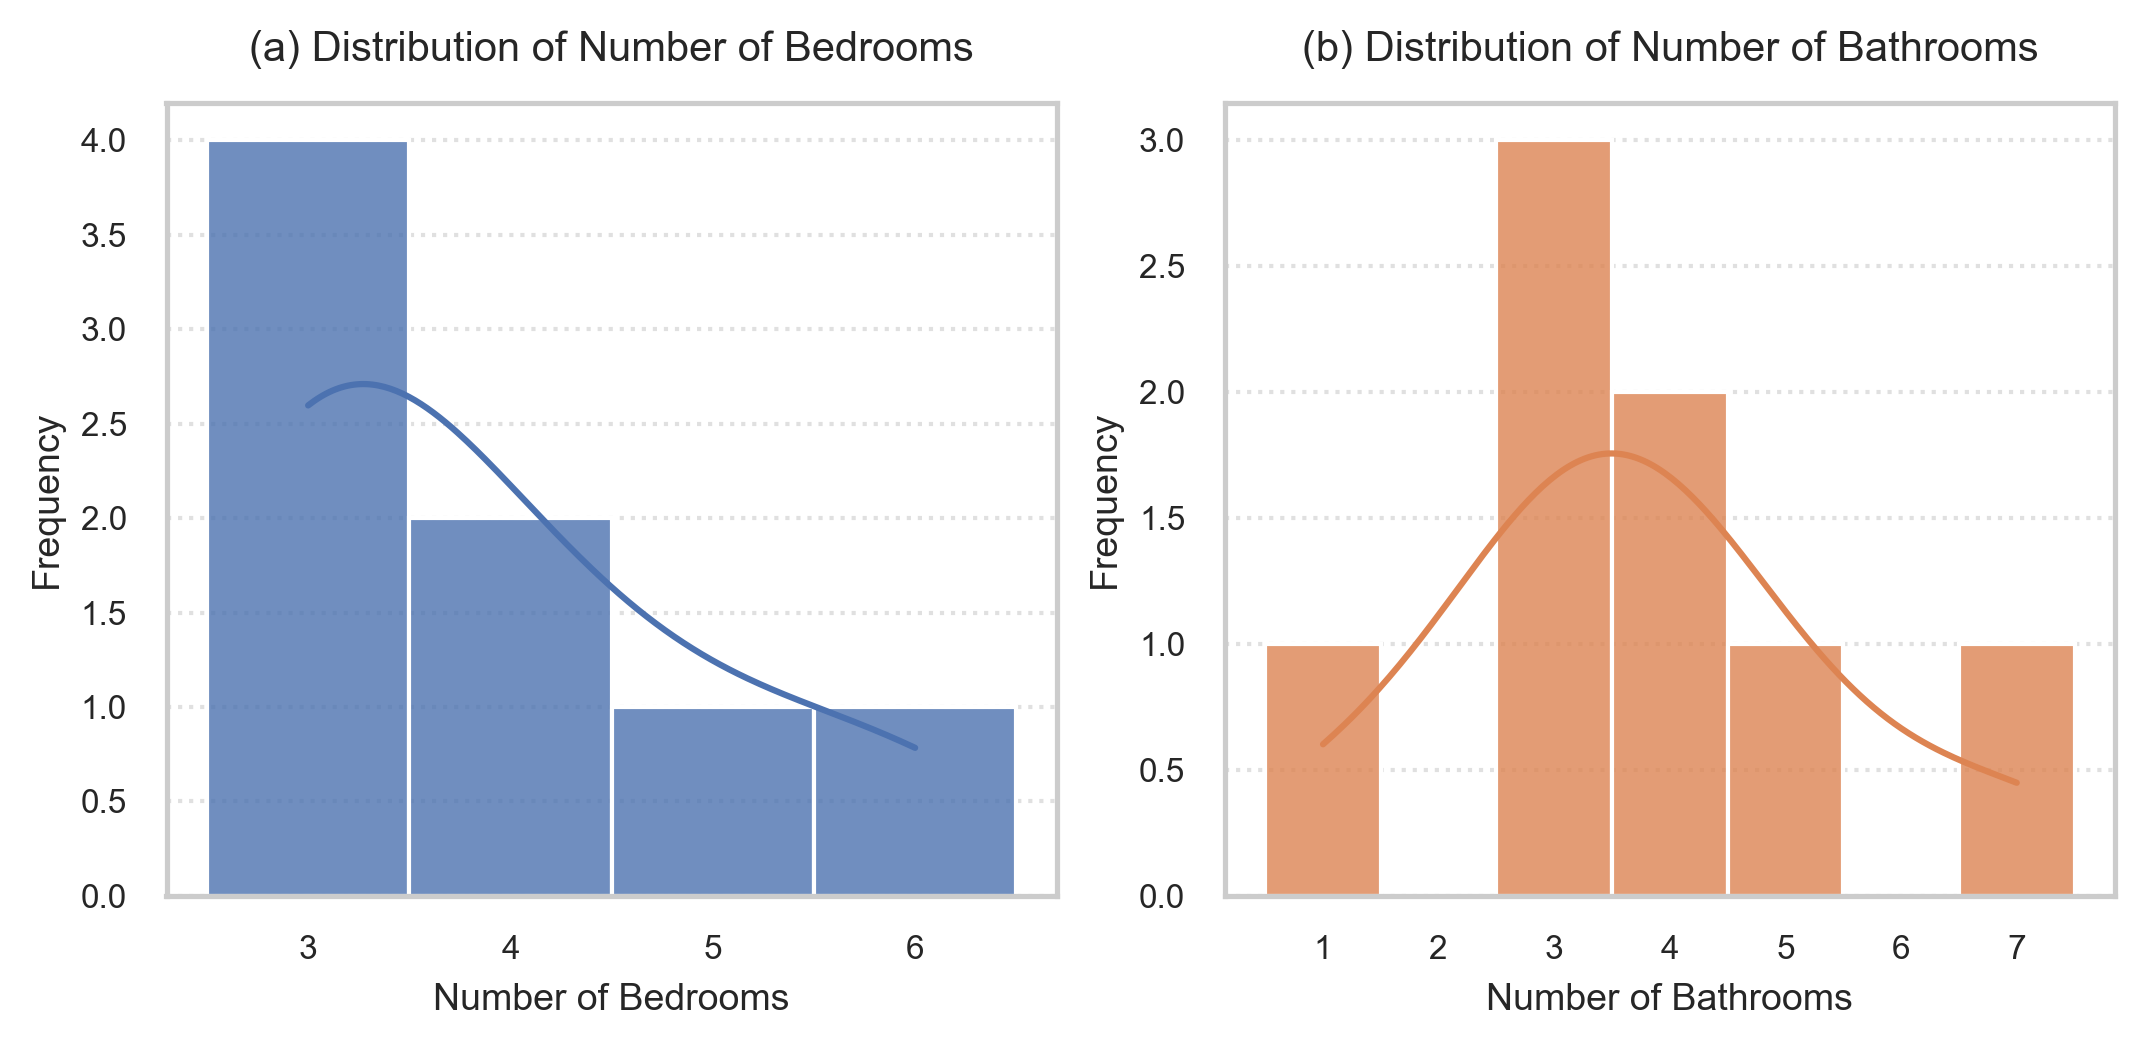

In [256]:

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial',
    'Helvetica',
    'DejaVu Sans'
]
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.16, 3.5),
    dpi=300
)

bedroom_data = (
    df['Số phòng ngủ']
    .dropna()
)

sns.histplot(
    bedroom_data,
    discrete=True,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title(
    '(a) Distribution of Number of Bedrooms',
    fontsize=10,
    pad=10
)

axes[0].set_xlabel(
    'Number of Bedrooms',
    fontsize=9
)

axes[0].set_ylabel(
    'Frequency',
    fontsize=9
)

axes[0].xaxis.set_major_locator(
    MaxNLocator(
        integer=True,
        nbins=10
    )
)

axes[0].tick_params(
    axis='both',
    labelsize=8
)

axes[0].grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

axes[0].grid(
    axis='x',
    visible=False
)

bathroom_data = (
    df['Số phòng tắm, vệ sinh']
    .dropna()
)

sns.histplot(
    bathroom_data,
    discrete=True,
    kde=True,
    color='#DD8452',
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title(
    '(b) Distribution of Number of Bathrooms',
    fontsize=10,
    pad=10
)

axes[1].set_xlabel(
    'Number of Bathrooms',
    fontsize=9
)

axes[1].set_ylabel(
    'Frequency',
    fontsize=9
)

axes[1].xaxis.set_major_locator(
    MaxNLocator(
        integer=True,
        nbins=10
    )
)

axes[1].tick_params(
    axis='both',
    labelsize=8
)

axes[1].grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

axes[1].grid(
    axis='x',
    visible=False
)

plt.tight_layout()

plt.show()


Detect serious outliers

In [257]:
MAX_ROOMS = 15

outlier_condition = (
    (df['Số phòng ngủ'] > MAX_ROOMS)
    |
    (df['Số phòng tắm, vệ sinh'] > MAX_ROOMS)
)

outlier_records = df[
    outlier_condition
]

display_columns = [
    'Link',
    'Diện tích',
    'Khoảng giá',
    'Số tầng',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Nội thất',
    'Pháp lý'
]

display_columns = [
    column
    for column in display_columns
    if column in outlier_records.columns
]

sorted_outliers = (
    outlier_records
    .sort_values(
        by='Số phòng ngủ',
        ascending=False
    )
)

print(
    f"Extreme Outliers Detected: "
    f"{len(sorted_outliers)} listings\n"
)

print("-" * 50)

try:

    display(
        sorted_outliers[
            display_columns
        ].head(50)
    )

except NameError:

    print(
        sorted_outliers[
            display_columns
        ].head(50)
    )


Extreme Outliers Detected: 0 listings

--------------------------------------------------


,Link,Diện tích,Khoảng giá,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh",Nội thất,Pháp lý


These outliers are a significant value, not an input error. Those are ads for sale of an entire building with nearly 10 floors, so it can have up to 100 bedrooms

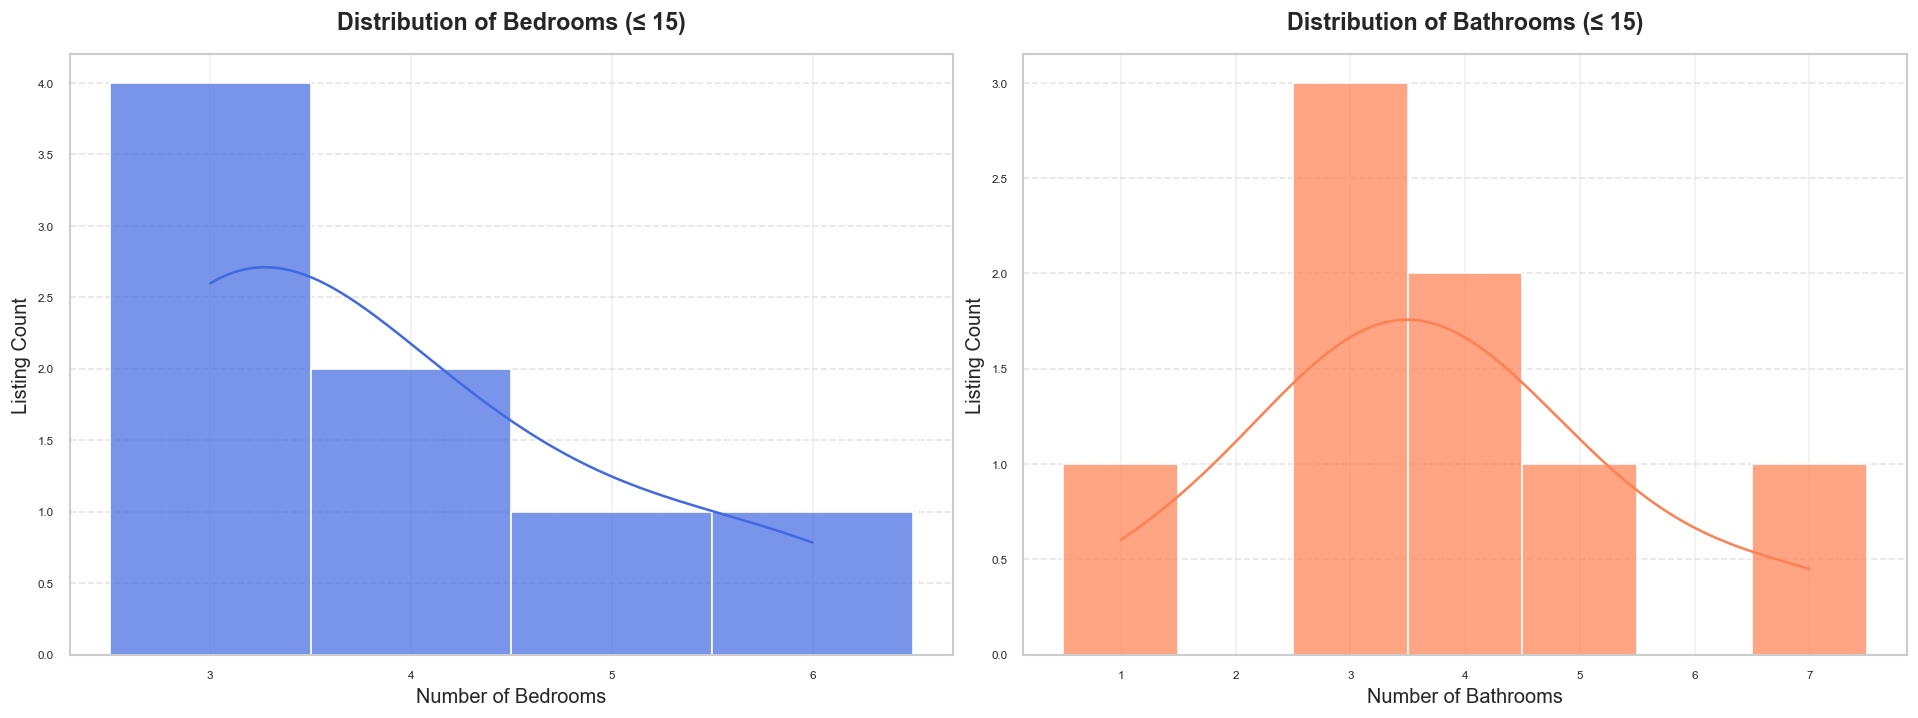

In [258]:

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

MAX_ROOMS = 15

bedroom_data = (
    df[
        df['Số phòng ngủ'] <= MAX_ROOMS
    ]['Số phòng ngủ']
    .dropna()
)

sns.histplot(
    bedroom_data,
    discrete=True,
    kde=True,
    color='royalblue',
    edgecolor='white',
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title(
    f'Distribution of Bedrooms (≤ {MAX_ROOMS})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

axes[0].set_xlabel(
    'Number of Bedrooms',
    fontsize=12
)

axes[0].set_ylabel(
    'Listing Count',
    fontsize=12
)

axes[0].set_xticks(
    range(
        int(bedroom_data.min()),
        int(bedroom_data.max()) + 1
    )
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

bathroom_data = (
    df[
        df['Số phòng tắm, vệ sinh'] <= MAX_ROOMS
    ]['Số phòng tắm, vệ sinh']
    .dropna()
)

sns.histplot(
    bathroom_data,
    discrete=True,
    kde=True,
    color='coral',
    edgecolor='white',
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title(
    f'Distribution of Bathrooms (≤ {MAX_ROOMS})',
    fontsize=14,
    fontweight='bold',
    pad=15
)

axes[1].set_xlabel(
    'Number of Bathrooms',
    fontsize=12
)

axes[1].set_ylabel(
    'Listing Count',
    fontsize=12
)

axes[1].set_xticks(
    range(
        int(bathroom_data.min()),
        int(bathroom_data.max()) + 1
    )
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

bedroom_outliers = (
    df[
        df['Số phòng ngủ'] > MAX_ROOMS
    ]
    .shape[0]
)

bathroom_outliers = (
    df[
        df['Số phòng tắm, vệ sinh'] > MAX_ROOMS
    ]
    .shape[0]
)

print(
    f'Warning: {bedroom_outliers} listings '
    f'have more than {MAX_ROOMS} bedrooms.'
)

print(
    f'Warning: {bathroom_outliers} listings '
    f'have more than {MAX_ROOMS} bathrooms.'
)


In [259]:

cols_to_describe = ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']

cols_exist = [col for col in cols_to_describe if col in df.columns]

if len(cols_exist) > 0:
    stats_df = df[cols_exist].describe(percentiles=[.25, .50, .75, .90, .95, .99])

    median_df = df[cols_exist].median()
    median_df.name = 'median'

    mode_df = df[cols_exist].mode().iloc[0]
    mode_df.name = 'mode'

    stats_df = pd.concat([stats_df, median_df.to_frame().T, mode_df.to_frame().T])

    print("DETAILED DESCRIPTIVE STATISTICS\n" + "-" * 40)

    try:
        display(stats_df.round(2))
    except NameError:
        print(stats_df.round(2))
else:
    print("Requested columns were not found in the DataFrame.")


DETAILED DESCRIPTIVE STATISTICS
----------------------------------------


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
count,8.00,8.00
mean,3.88,3.75
std,1.13,1.75
min,3.00,1.00
25%,3.00,3.00
50%,3.50,3.50
75%,4.25,4.25
90%,5.30,5.60
95%,5.65,6.30
99%,5.93,6.86


-High rate of missing records (15-20%).

- This attribute is highly correlated with features such as: 'Khoảng giá' and 'Diện tích' -> MAR.

-The number of missing items in this column is also highly correlated with other columns.

- Use machine learning models to fill in the gaps. 'khoảng giá' and 'diện tích' are two continuous variables so you can use KNN or MICE to fill in.

-In particular: The lack of 'số tầng' does not correlate with other attributes -> MCAR, but the value of the number of floors is strongly correlated with 'số phòng ngủ' and 'số phòng tắm'. Therefore, predicting these two columns first will serve as a premise for predicting the column number of floors later.


### 2.2.1 Handling the attribute 'Number of bedrooms'


#### 2.2.1.1 Option 1: fill in the gaps using KNN.


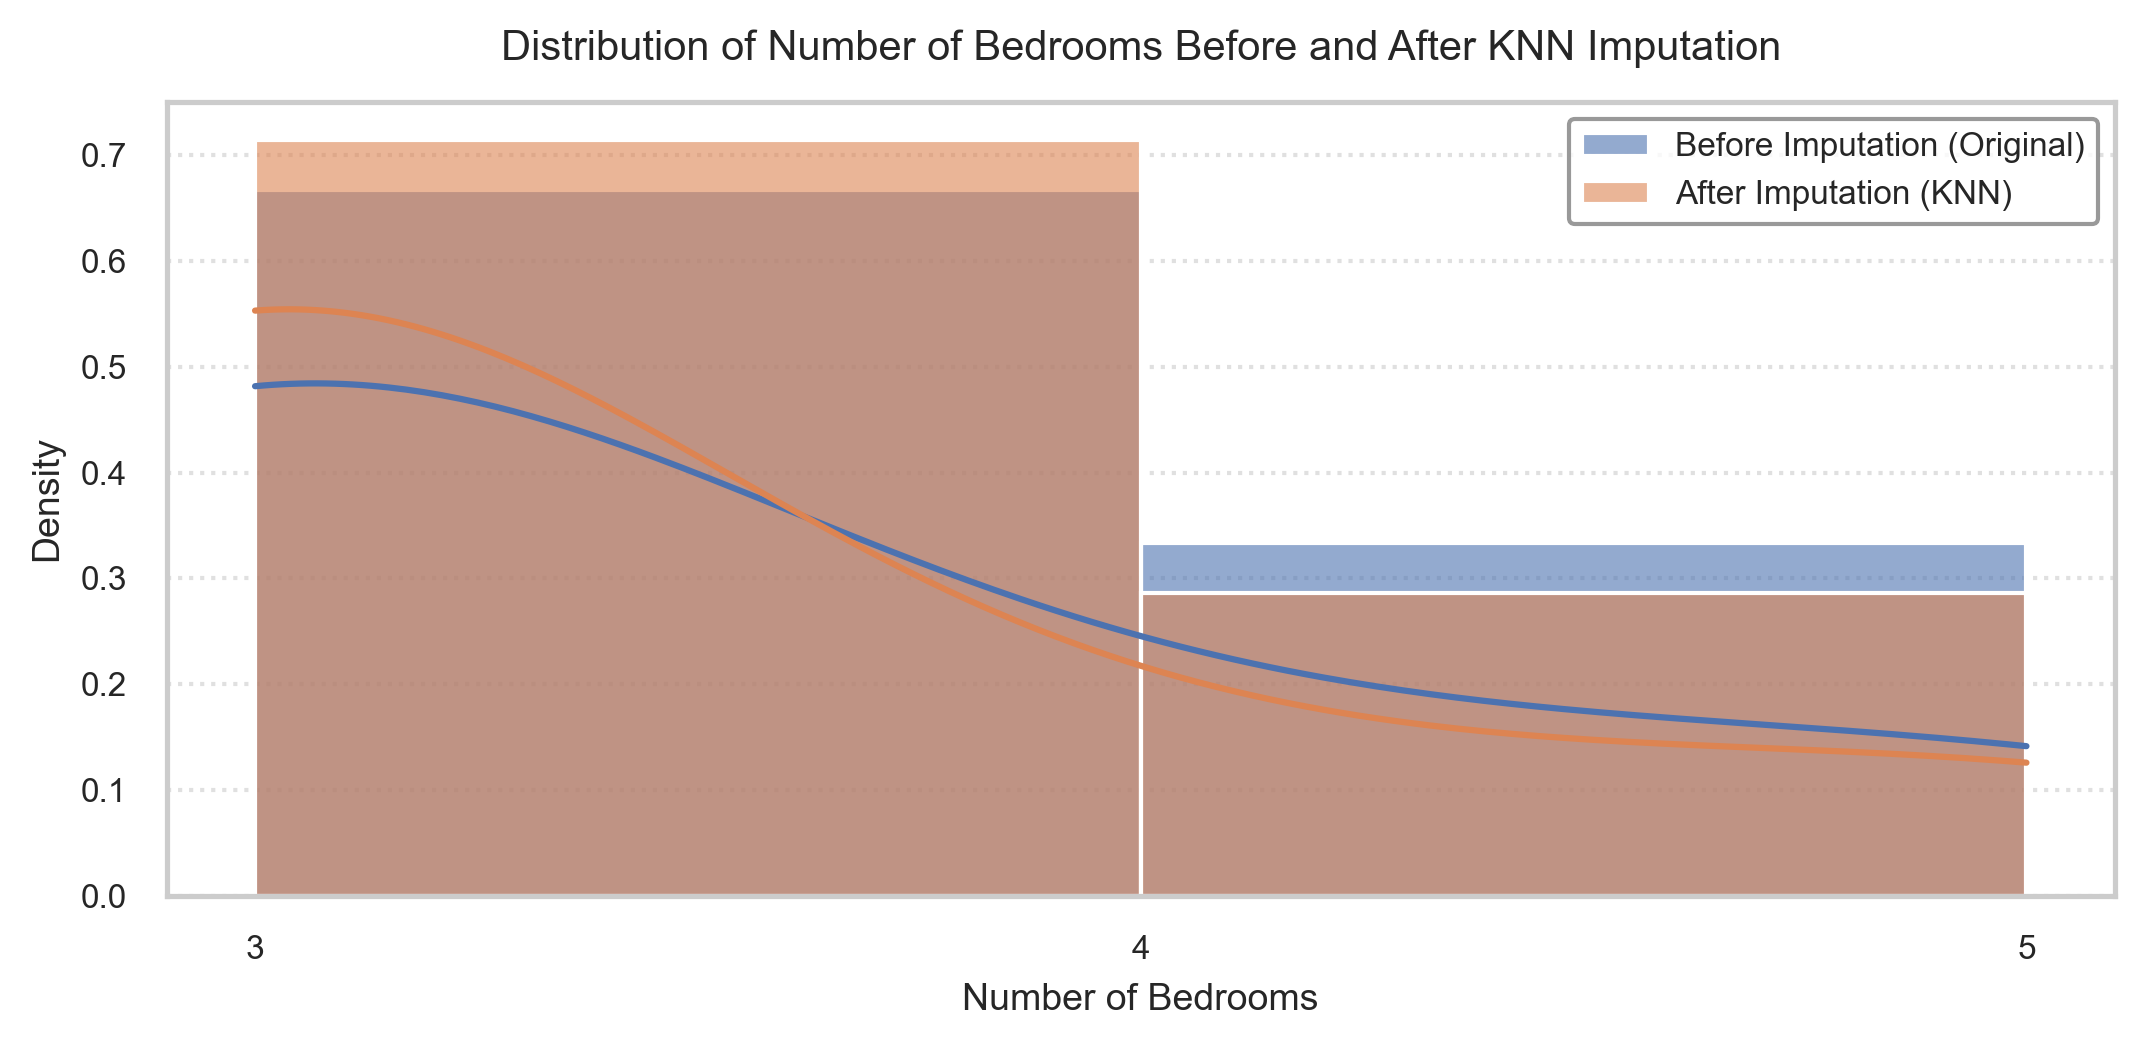

In [260]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

features_to_use = ['Diện tích', 'Số phòng ngủ']
X_train_sub = X_train[features_to_use].copy()

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_sub),
    columns=features_to_use
)

knn_imputer = KNNImputer(n_neighbors=5)
X_train_imputed_scaled = knn_imputer.fit_transform(X_train_scaled)

X_train_imputed = pd.DataFrame(
    scaler.inverse_transform(X_train_imputed_scaled),
    columns=features_to_use,
    index=X_train.index
)

bedrooms_after_knn_imputation = np.round(
    X_train_imputed['Số phòng ngủ']
).astype(int)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

sns.histplot(
    X_train['Số phòng ngủ'].dropna(),
    color='#4C72B0',
    label='Before Imputation (Original)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

sns.histplot(
    bedrooms_after_knn_imputation,
    color='#DD8452',
    label='After Imputation (KNN)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

ax.set_title(
    'Distribution of Number of Bedrooms Before and After KNN Imputation',
    fontsize=10,
    pad=10
)
ax.set_xlabel('Number of Bedrooms', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis='both', labelsize=8)

ax.legend(
    fontsize=8,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

plt.show()

# X_train['Số phòng ngủ'] = bedrooms_after_knn_imputation


- The data distribution after prediction by KNN coincides with the distribution before gap filling. The KNN model gives good results. 

#### 2.2.1.2 Option 2: use MICE (using Random Forest) to fill in the blanks


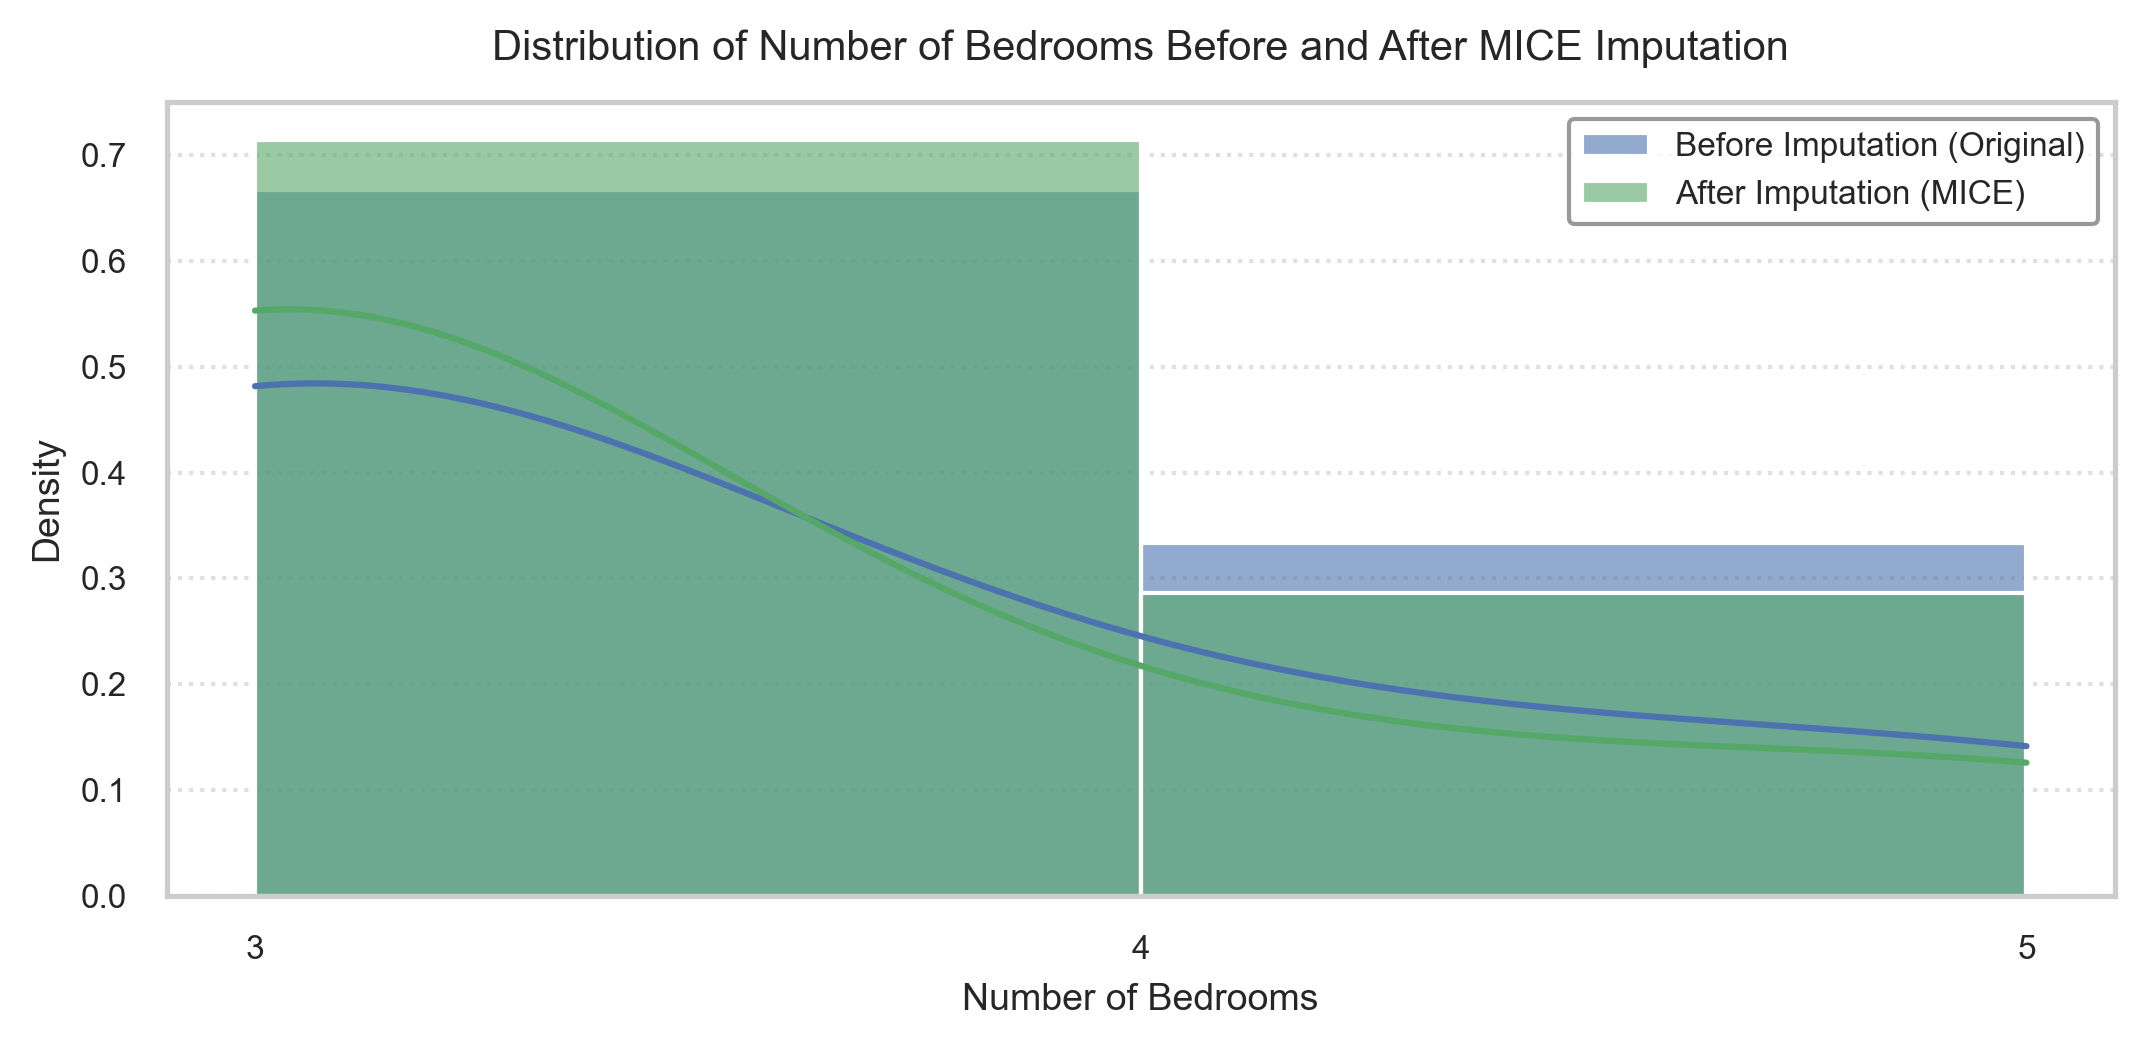

In [261]:

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

features_to_use = ['Diện tích', 'Số phòng ngủ']
X_train_sub = X_train[features_to_use].copy()

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=50,
        random_state=42
    ),
    max_iter=10,
    random_state=42
)

X_train_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X_train_sub),
    columns=features_to_use,
    index=X_train.index
)

bedrooms_after_mice_imputation = np.round(
    X_train_imputed['Số phòng ngủ']
).astype(int)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

sns.histplot(
    X_train['Số phòng ngủ'].dropna(),
    color='#4C72B0',
    label='Before Imputation (Original)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

sns.histplot(
    bedrooms_after_mice_imputation,
    color='#55A868',
    label='After Imputation (MICE)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

ax.set_title(
    'Distribution of Number of Bedrooms Before and After MICE Imputation',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Number of Bedrooms', fontsize=9)
ax.set_ylabel('Density', fontsize=9)

ax.xaxis.set_major_locator(
    MaxNLocator(integer=True, nbins=10)
)

ax.tick_params(axis='both', labelsize=8)

ax.legend(
    fontsize=8,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

plt.tight_layout()

plt.show()

# X_train['Số phòng ngủ'] = bedrooms_after_mice_imputation


- The data distribution after prediction by MICE (using Random Forest) coincides with the distribution before filling in the gaps. The MICE model gives good results. 

Fill by MICE (2 methods have the same performance)

In [262]:
X_train['Số phòng ngủ'] = bedrooms_after_mice_imputation


Apply to test

In [263]:
features_to_use_bedrooms = ['Diện tích', 'Số phòng ngủ']

X_test_sub = X_test[features_to_use_bedrooms].copy()

X_test_imputed = pd.DataFrame(
    mice_imputer.transform(X_test_sub),
    columns=features_to_use_bedrooms,
    index=X_test.index
)

X_test['Số phòng ngủ'] = np.round(
    X_test_imputed['Số phòng ngủ']
).astype(int)


In [264]:
print("=== VALIDATION OF MICE-IMPUTED BEDROOM VALUES (X_test) ===")

print(
    f"Remaining missing values in Number of Bedrooms: "
    f"{X_test['Số phòng ngủ'].isnull().sum()}"
)

print("\nFirst 5 rows of the related features in X_test:")

display(
    X_test[
        ['Diện tích', 'Khoảng giá_log', 'Số phòng ngủ']
    ].head()
)


=== VALIDATION OF MICE-IMPUTED BEDROOM VALUES (X_test) ===
Remaining missing values in Number of Bedrooms: 0

First 5 rows of the related features in X_test:


,Diện tích,Khoảng giá_log,Số phòng ngủ
7,126.0,3.258097,6
1,38.0,1.931521,4


### 2.2.2 Handling the 'Number of Bathrooms' feature

Use the previously predicted 'Number of Bedrooms' feature to help impute the 'Number of Bathrooms'.

#### 2.2.2.1 Option 1: Imputation using KNN.

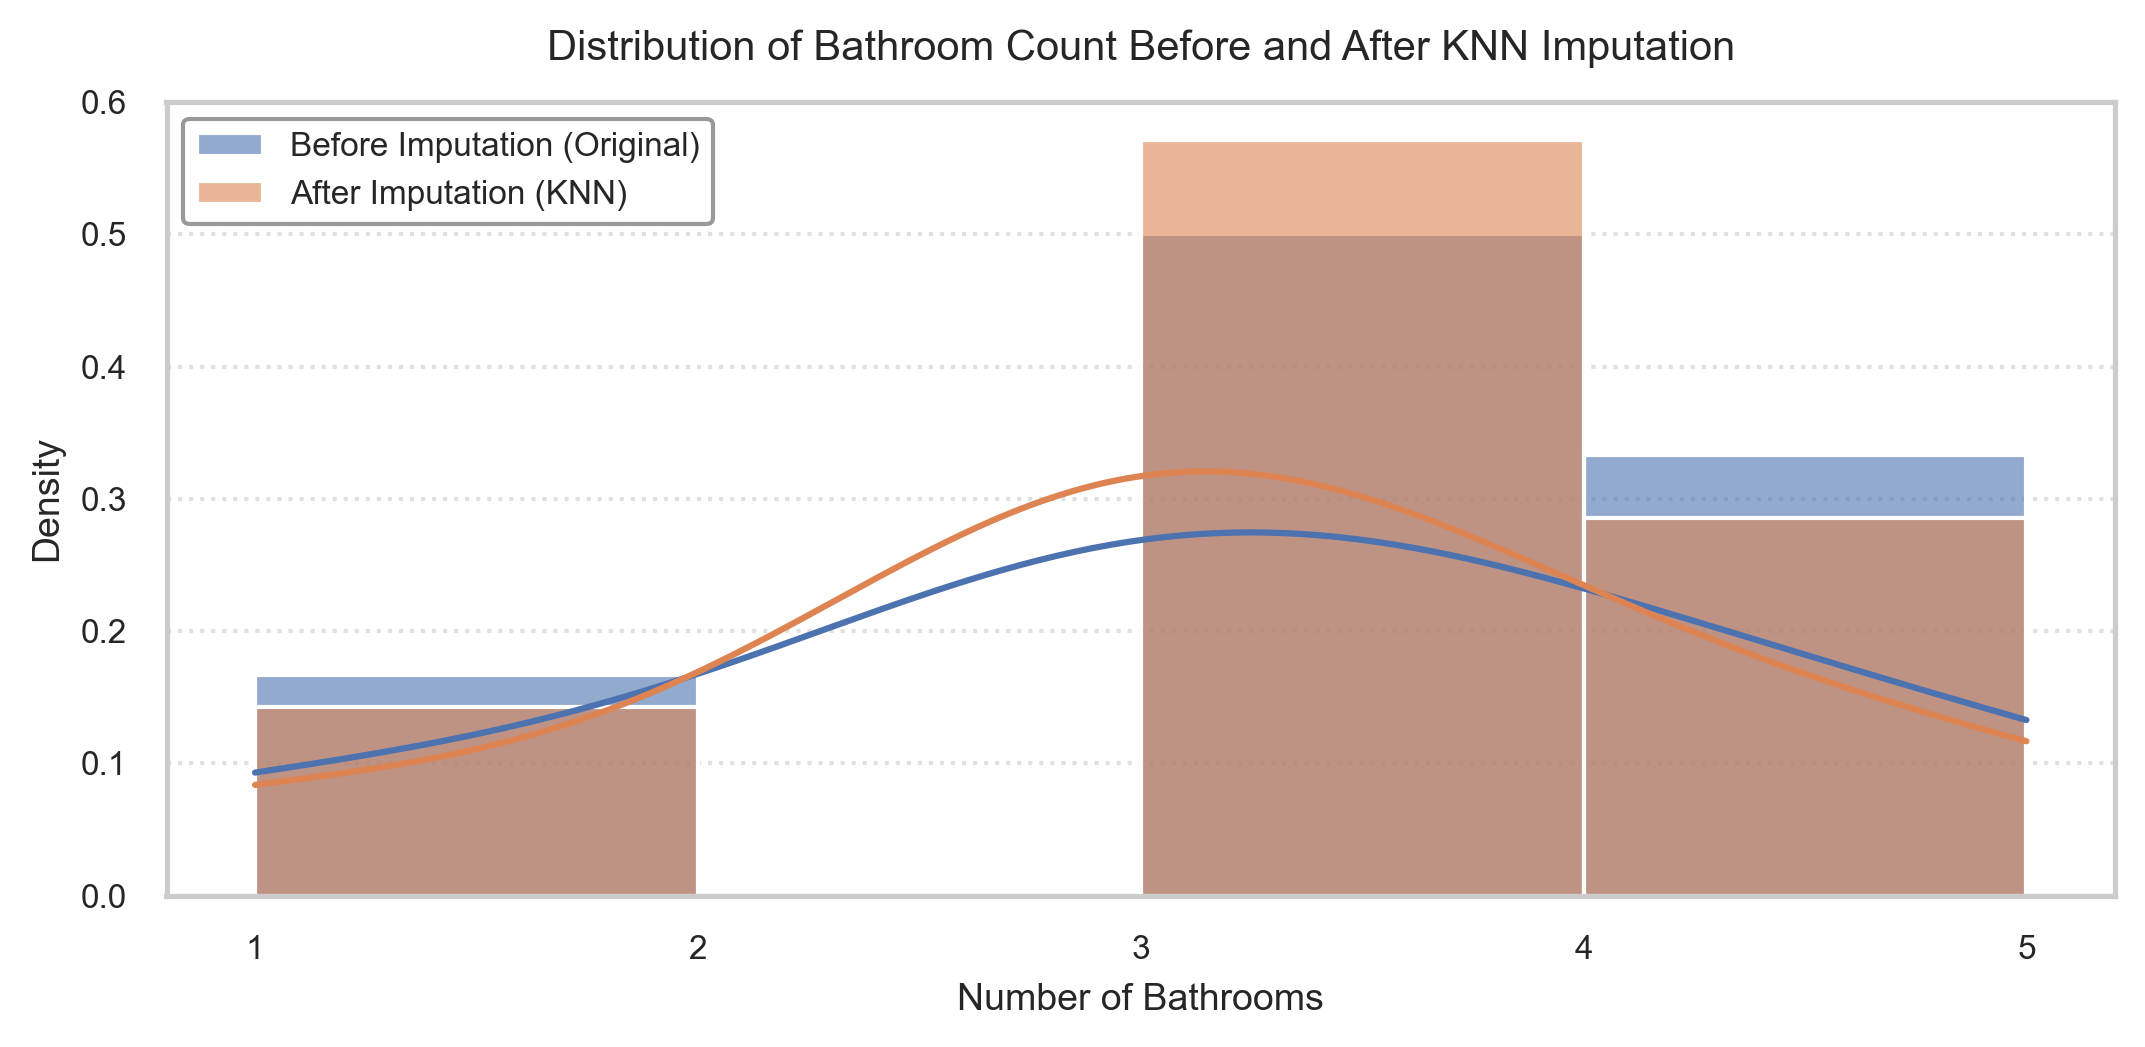

In [265]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']

X_train_sub = X_train[features_to_use].copy()

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
scaler.fit_transform(X_train_sub),
columns=features_to_use
)

knn_imputer = KNNImputer(n_neighbors=5)

X_train_imputed_scaled = knn_imputer.fit_transform(
X_train_scaled
)

X_train_imputed = pd.DataFrame(
scaler.inverse_transform(X_train_imputed_scaled),
columns=features_to_use,
index=X_train.index
)

bathrooms_after_knn = np.round(
X_train_imputed['Số phòng tắm, vệ sinh']
).astype(int)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

sns.histplot(
X_train['Số phòng tắm, vệ sinh'].dropna(),
color='#4C72B0',
label='Before Imputation (Original)',
stat='density',
alpha=0.6,
binwidth=1,
kde=True,
edgecolor='white',
ax=ax
)

sns.histplot(
bathrooms_after_knn,
color='#DD8452',
label='After Imputation (KNN)',
stat='density',
alpha=0.6,
binwidth=1,
kde=True,
edgecolor='white',
ax=ax
)

ax.set_title(
'Distribution of Bathroom Count Before and After KNN Imputation',
fontsize=10,
pad=10
)

ax.set_xlabel(
'Number of Bathrooms',
fontsize=9
)

ax.set_ylabel(
'Density',
fontsize=9
)

ax.xaxis.set_major_locator(
MaxNLocator(
integer=True,
nbins=10
)
)

ax.tick_params(
axis='both',
labelsize=8
)

ax.legend(
fontsize=8,
frameon=True,
facecolor='white',
edgecolor='gray'
)

ax.grid(
axis='y',
linestyle=':',
alpha=0.6
)

ax.grid(
axis='x',
visible=False
)

plt.tight_layout()

plt.show()


#### 2.2.2.2 Option 2: Imputation using MICE (Random Forest estimator)

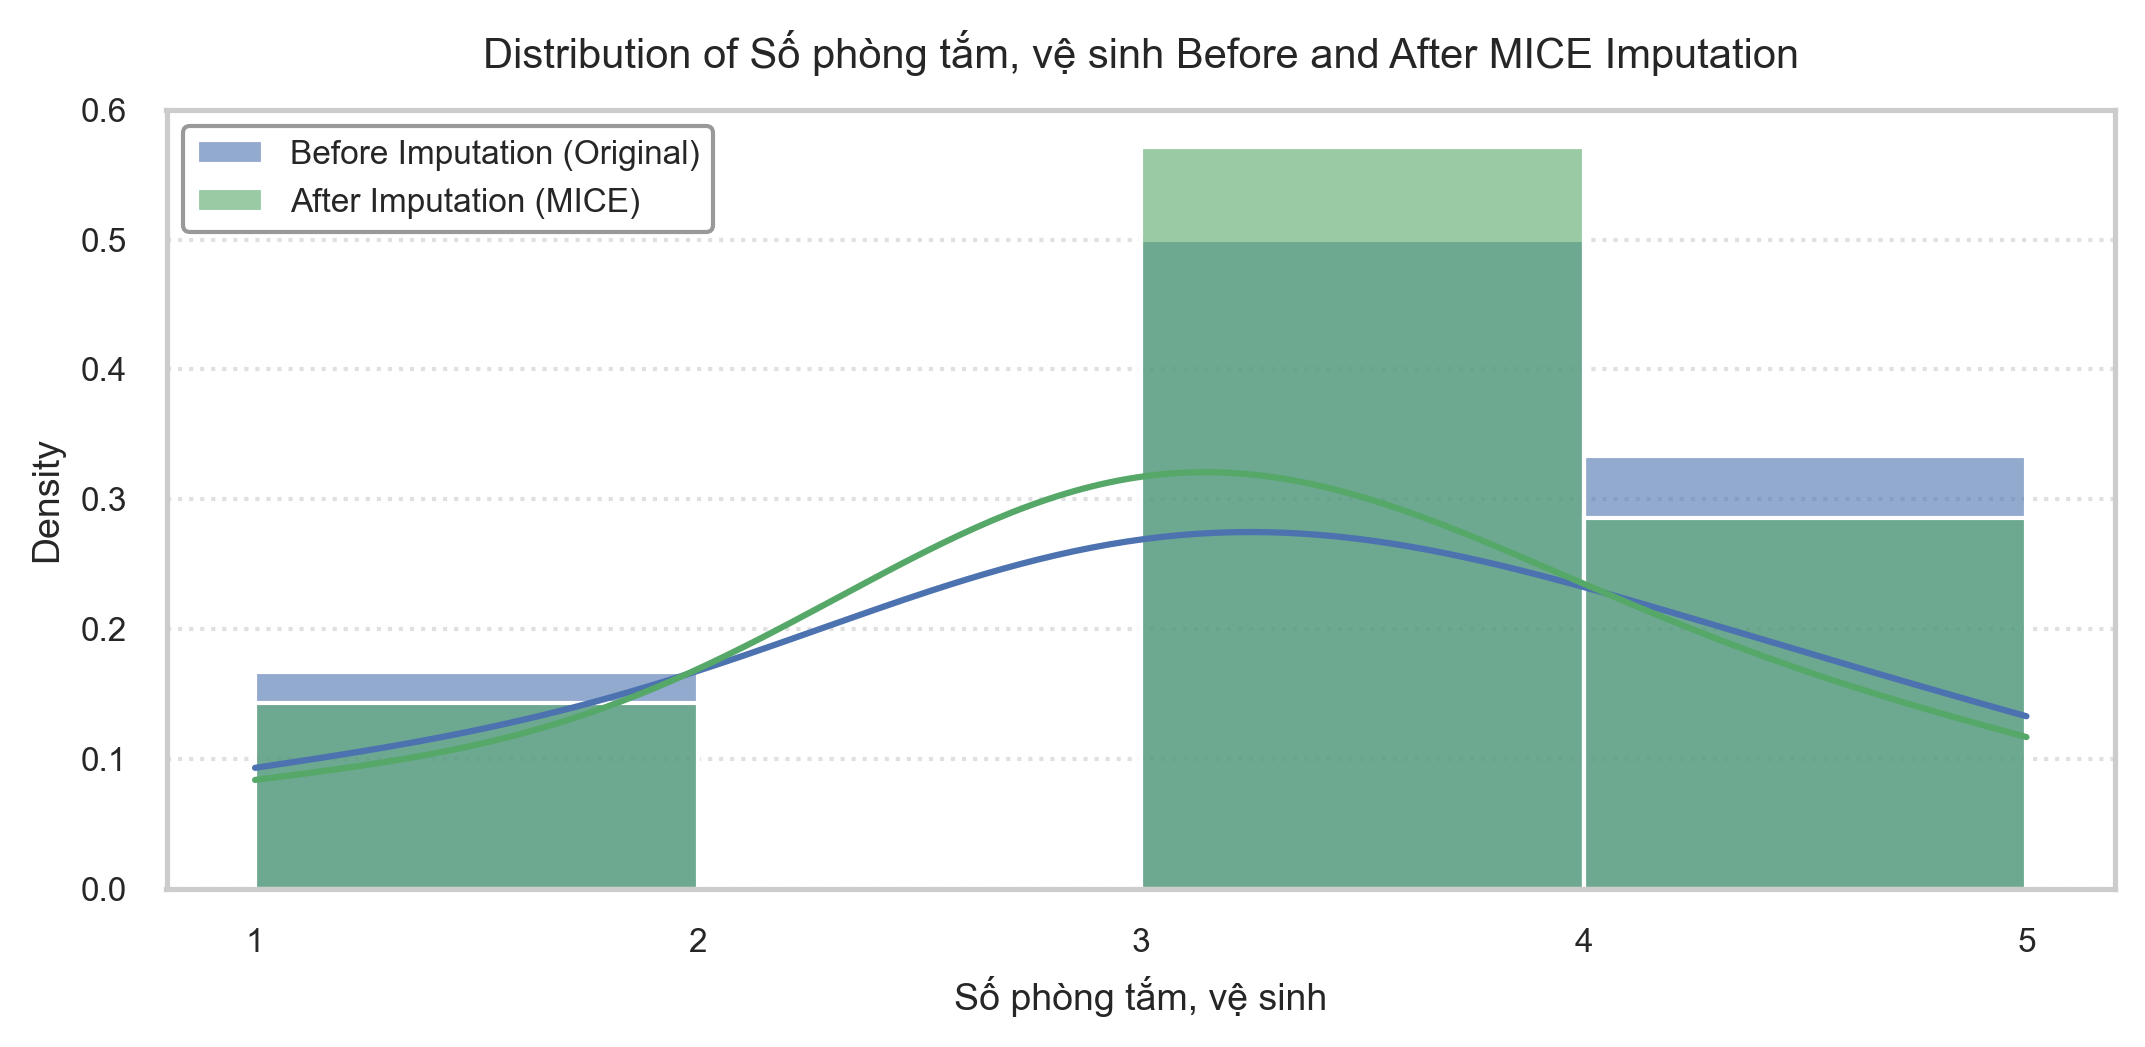

In [266]:

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

features_to_use = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh']
X_train_sub = X_train[features_to_use].copy()

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=50,
        random_state=42
    ),
    max_iter=10,
    random_state=42
)

X_train_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X_train_sub),
    columns=features_to_use,
    index=X_train.index
)

bathrooms_after_mice = np.round(
    X_train_imputed['Số phòng tắm, vệ sinh']
).astype(int)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial',
    'Helvetica',
    'DejaVu Sans'
]
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(
    figsize=(7.16, 3.5),
    dpi=300
)

sns.histplot(
    X_train['Số phòng tắm, vệ sinh'].dropna(),
    color='#4C72B0',
    label='Before Imputation (Original)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

sns.histplot(
    bathrooms_after_mice,
    color='#55A868',
    label='After Imputation (MICE)',
    stat='density',
    alpha=0.6,
    binwidth=1,
    kde=True,
    edgecolor='white',
    ax=ax
)

ax.set_title(
    'Distribution of Số phòng tắm, vệ sinh Before and After MICE Imputation',
    fontsize=10,
    pad=10
)

ax.set_xlabel(
    'Số phòng tắm, vệ sinh',
    fontsize=9
)

ax.set_ylabel(
    'Density',
    fontsize=9
)

ax.xaxis.set_major_locator(
    MaxNLocator(
        integer=True,
        nbins=10
    )
)

ax.tick_params(
    axis='both',
    labelsize=8
)

ax.legend(
    fontsize=8,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

ax.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

ax.grid(
    axis='x',
    visible=False
)

plt.tight_layout()
plt.show()


The two imputation methods show comparable performance.

In [267]:
X_train['Số phòng tắm, vệ sinh'] = bathrooms_after_knn


Apply the imputation pipeline to the test set

In [268]:
features_to_use = [
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh'
]

X_test_sub = X_test[features_to_use].copy()

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_sub),
    columns=features_to_use,
    index=X_test.index
)

X_test_imputed_scaled = knn_imputer.transform(
    X_test_scaled
)

X_test_imputed = pd.DataFrame(
    scaler.inverse_transform(X_test_imputed_scaled),
    columns=features_to_use,
    index=X_test.index
)

X_test['Số phòng tắm, vệ sinh'] = np.round(
    X_test_imputed['Số phòng tắm, vệ sinh']
).astype(int)


In [269]:
print("=== BATHROOMS AFTER KNN IMPUTATION CHECK (X_test) ===")

print(
    f"Remaining NaN values in 'Số phòng tắm, vệ sinh': "
    f"{X_test['Số phòng tắm, vệ sinh'].isnull().sum()}"
)

print("\nFirst 5 rows of Bedrooms and Bathrooms in X_test:")

display(
    X_test[
        ['Số phòng ngủ', 'Số phòng tắm, vệ sinh']
    ].head()
)


=== BATHROOMS AFTER KNN IMPUTATION CHECK (X_test) ===
Remaining NaN values in 'Số phòng tắm, vệ sinh': 0

First 5 rows of Bedrooms and Bathrooms in X_test:


,Số phòng ngủ,"Số phòng tắm, vệ sinh"
7,6,7
1,4,4


#### 2.2.3 Re-check correlations after imputation

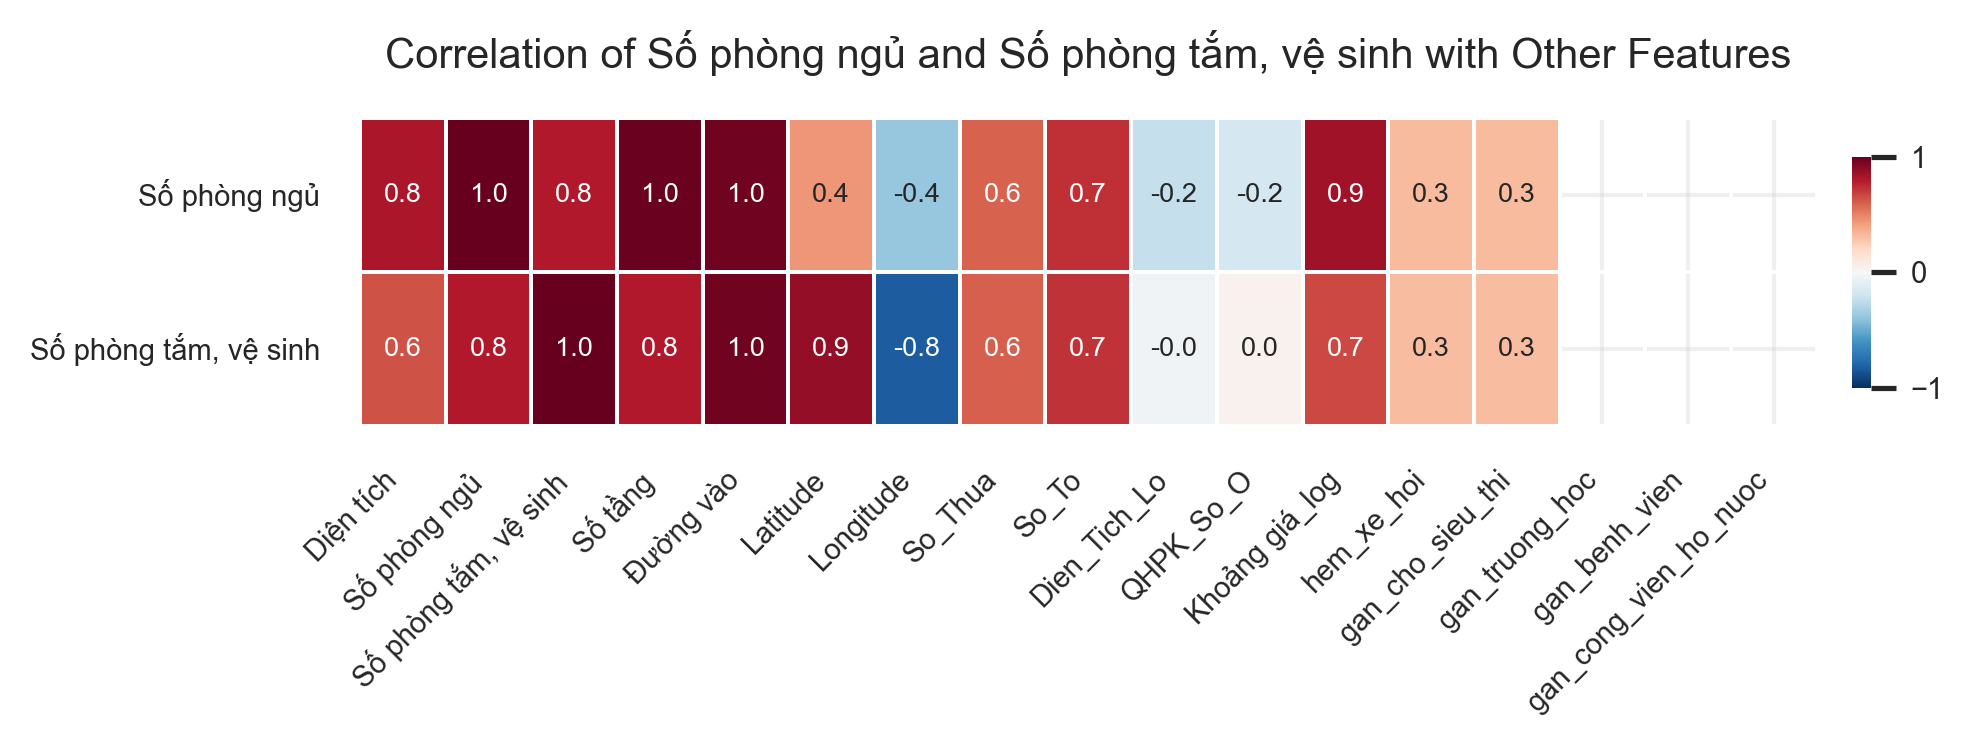

In [270]:

numeric_cols = X_train.select_dtypes(include=[np.number]).columns

correlation_matrix = X_train[numeric_cols].corr()

target_vars = [
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh'
]

target_vars = [
    col for col in target_vars
    if col in correlation_matrix.columns
]

if target_vars:
    target_corr = correlation_matrix.loc[target_vars, :]

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [
        'Arial',
        'Helvetica',
        'DejaVu Sans'
    ]
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    fig, ax = plt.subplots(
        figsize=(7.16, 2.5),
        dpi=300
    )

    sns.heatmap(
        target_corr,
        annot=True,
        cmap='RdBu_r',
        vmin=-1,
        vmax=1,
        fmt=".1f",
        linewidths=0.5,
        linecolor='#ffffff',
        annot_kws={"size": 6.5},
        cbar_kws={
            "shrink": 0.75,
            "aspect": 12,
            "pad": 0.02
        },
        ax=ax
    )

    ax.set_title(
        'Correlation of Số phòng ngủ and Số phòng tắm, vệ sinh with Other Features',
        fontsize=10,
        pad=12
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha='right',
        fontsize=7
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=7
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

else:
    print(
        "Please ensure that 'Số phòng ngủ' and "
        "'Số phòng tắm, vệ sinh' are numeric variables."
    )


The correlation matrix remains largely consistent with the original. Imputation did not destroy the relationships between features: larger properties tend to be more expensive and generally have more rooms.

- Note: The reduction in peak density after imputation is not a modelling error but reflects a Missing At Random (MAR) mechanism. Missing values are concentrated in large-area listings or whole-house listings. The imputation model fills them with correspondingly larger values (more bathrooms). This increases tail mass, which mathematically reduces the relative density near the mode. The result shows the algorithm captured the market logic rather than performing naive, majority-based imputation.

## 2.3 Handling missing values in the 'Number of Floors' column

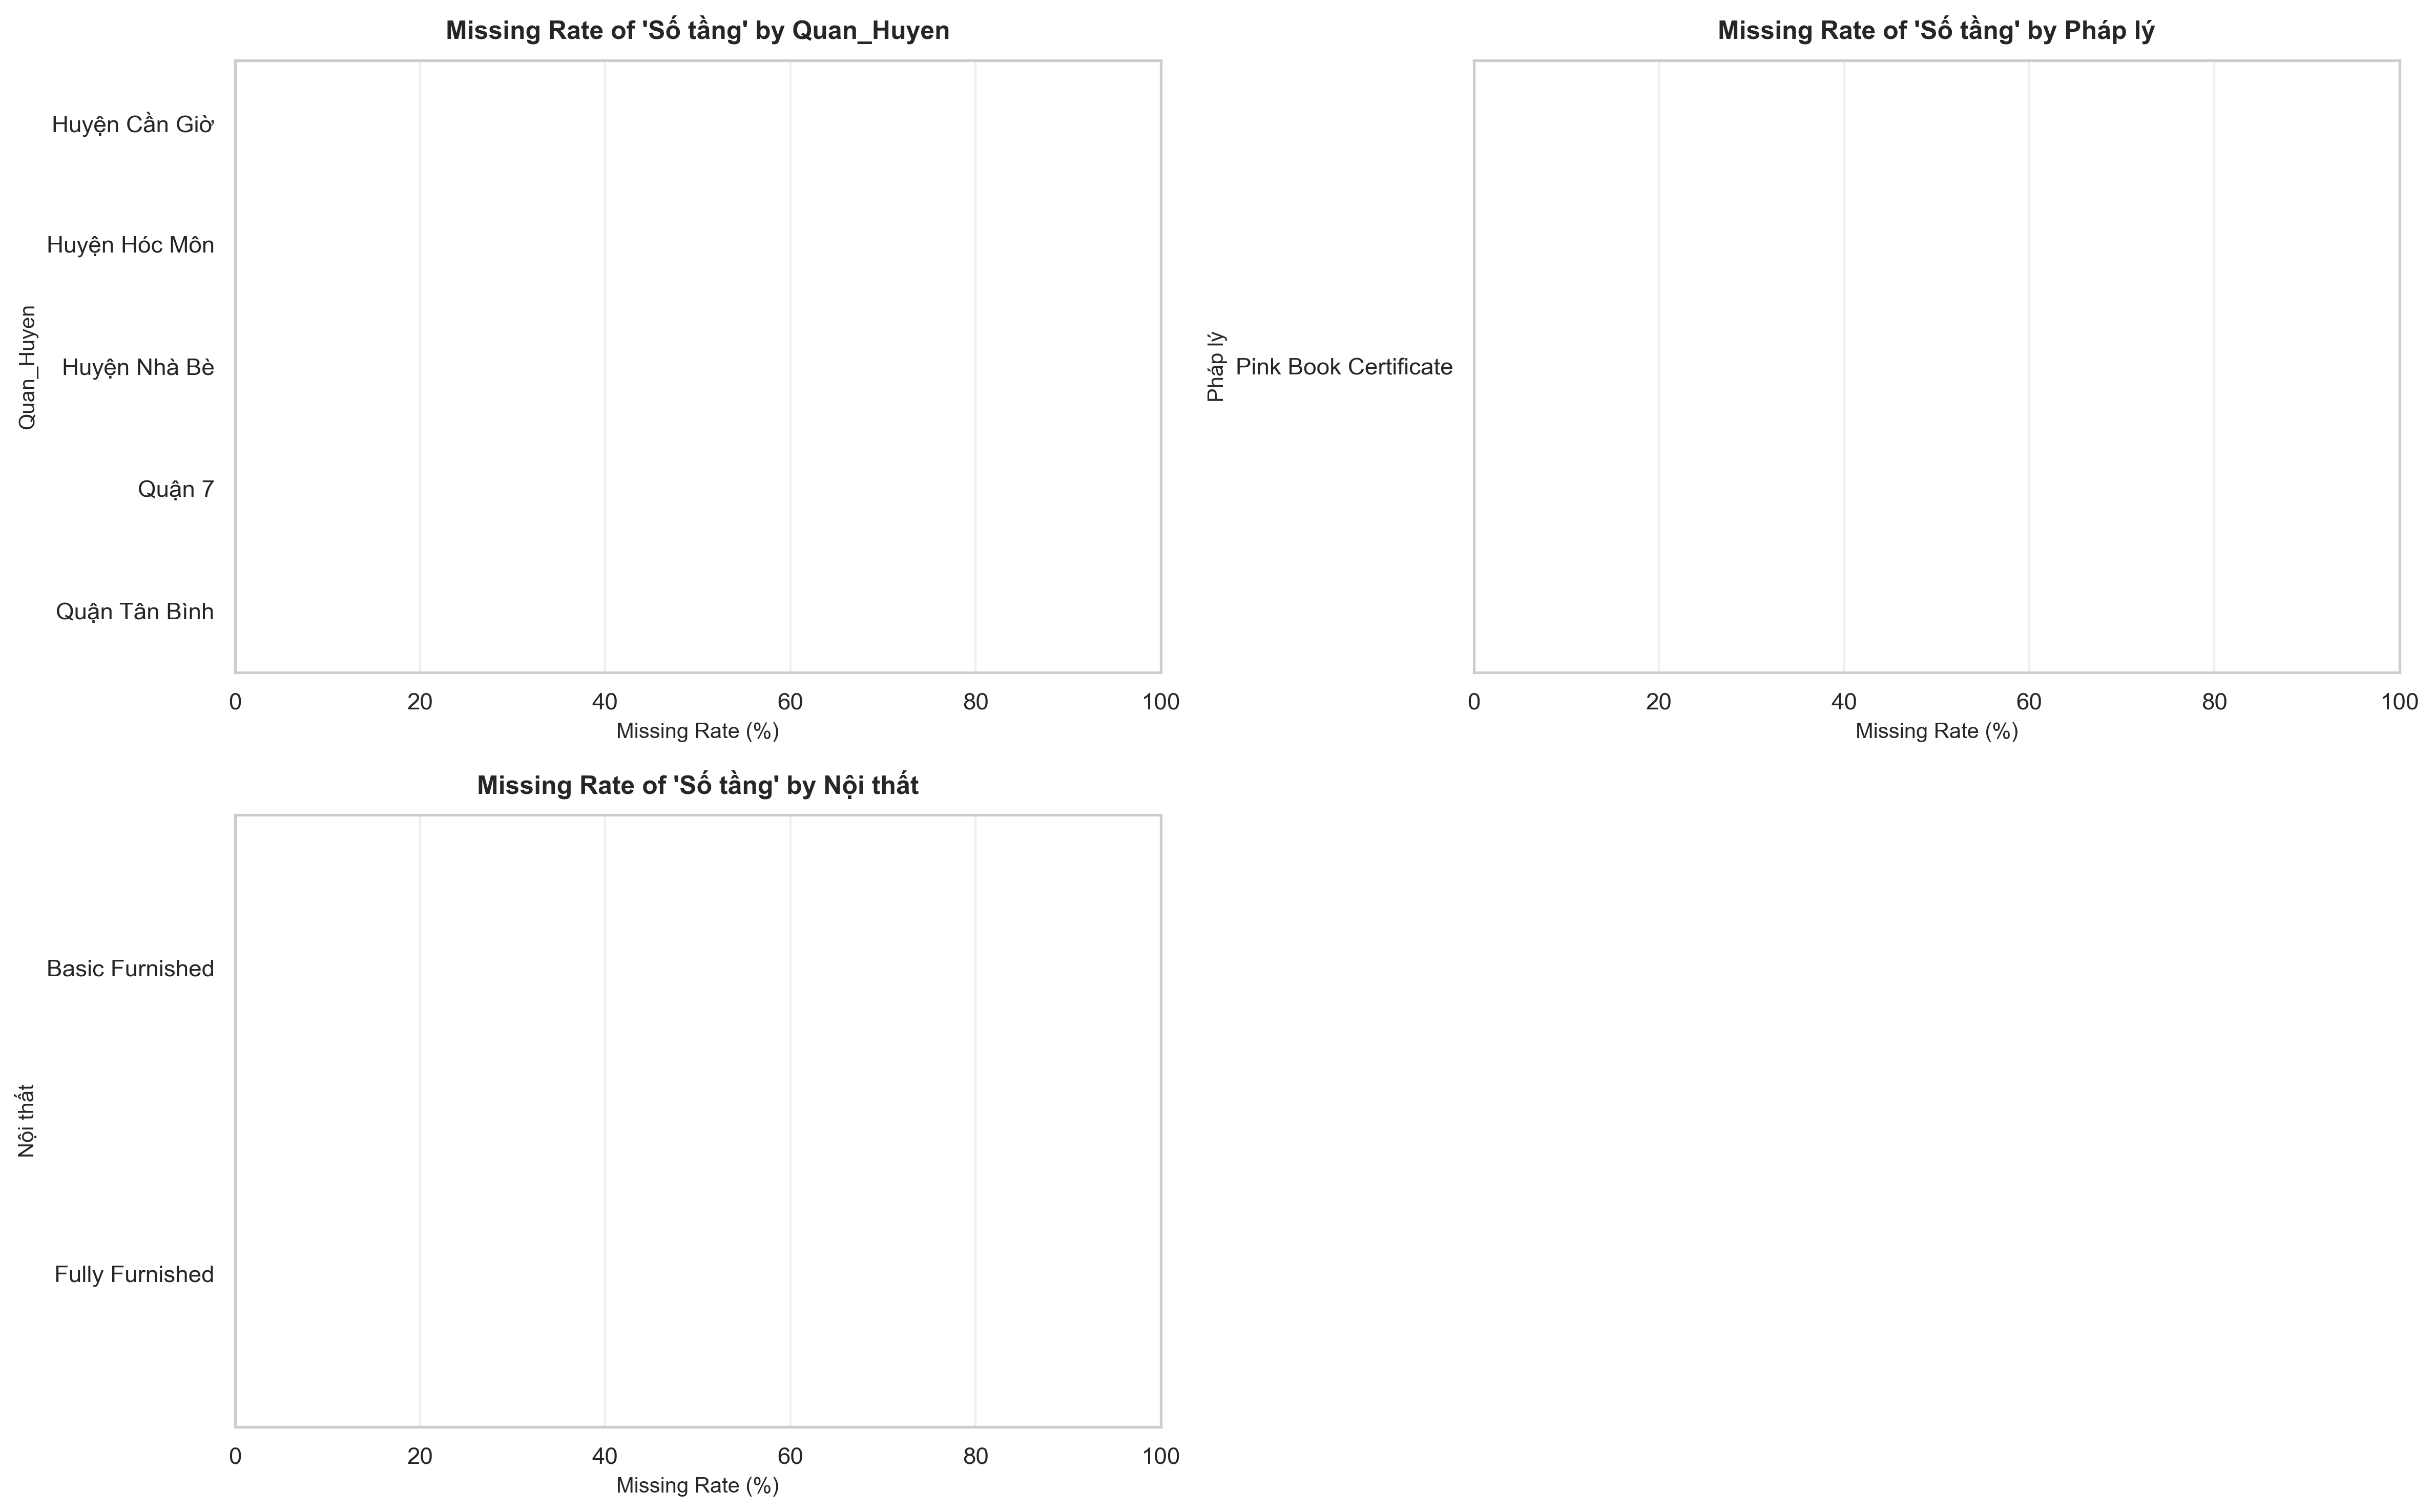

In [271]:

plt.rcParams['figure.dpi'] = 300
sns.set_theme(style="whitegrid")

df['_Is_Floors_Missing'] = df['Số tầng'].isnull()

group_columns = [
    'Quan_Huyen',
    'Pháp lý',
    'Nội thất',
    'Hướng nhà'
]

group_columns = [
    col for col in group_columns
    if col in df.columns
]

n_plots = len(group_columns)

if n_plots > 0:
    nrows = (n_plots + 1) // 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(16, 5 * nrows)
    )

    axes = axes.flatten()

    for i, col in enumerate(group_columns):
        missing_rate = (
            df.groupby(col)['_Is_Floors_Missing']
            .mean()
            .reset_index()
        )

        missing_rate['_Is_Floors_Missing'] *= 100

        missing_rate = missing_rate.sort_values(
            by='_Is_Floors_Missing',
            ascending=False
        )

        sns.barplot(
            data=missing_rate,
            y=col,
            x='_Is_Floors_Missing',
            ax=axes[i],
            palette='Reds_r',
            hue=col,
            legend=False
        )

        axes[i].set_title(
            f"Missing Rate of 'Số tầng' by {col}",
            fontsize=12,
            fontweight='bold',
            pad=10
        )

        axes[i].set_xlabel(
            "Missing Rate (%)",
            fontsize=10
        )

        axes[i].set_ylabel(
            col,
            fontsize=10
        )

        axes[i].set_xlim(0, 100)

        for p in axes[i].patches:
            width = p.get_width()

            if width > 0:
                axes[i].annotate(
                    f'{width:.1f}%',
                    (
                        width,
                        p.get_y() + p.get_height() / 2
                    ),
                    ha='left',
                    va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold'
                )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

df.drop(
    columns=['_Is_Floors_Missing'],
    inplace=True
)


The 'Number of Floors' column appears to be MNAR (Missing Not At Random):
- 'Fully Furnished' (37.73%): the largest group.
- 'Empty / Bare Shell' (3.63%): a very small share.

Although the 'Empty / Bare Shell' group represents only 3.63% of samples, we previously observed that it has the highest missing rate for 'Number of Floors' (14.4%).

### 2.3.1 Distribution statistics and outlier detection

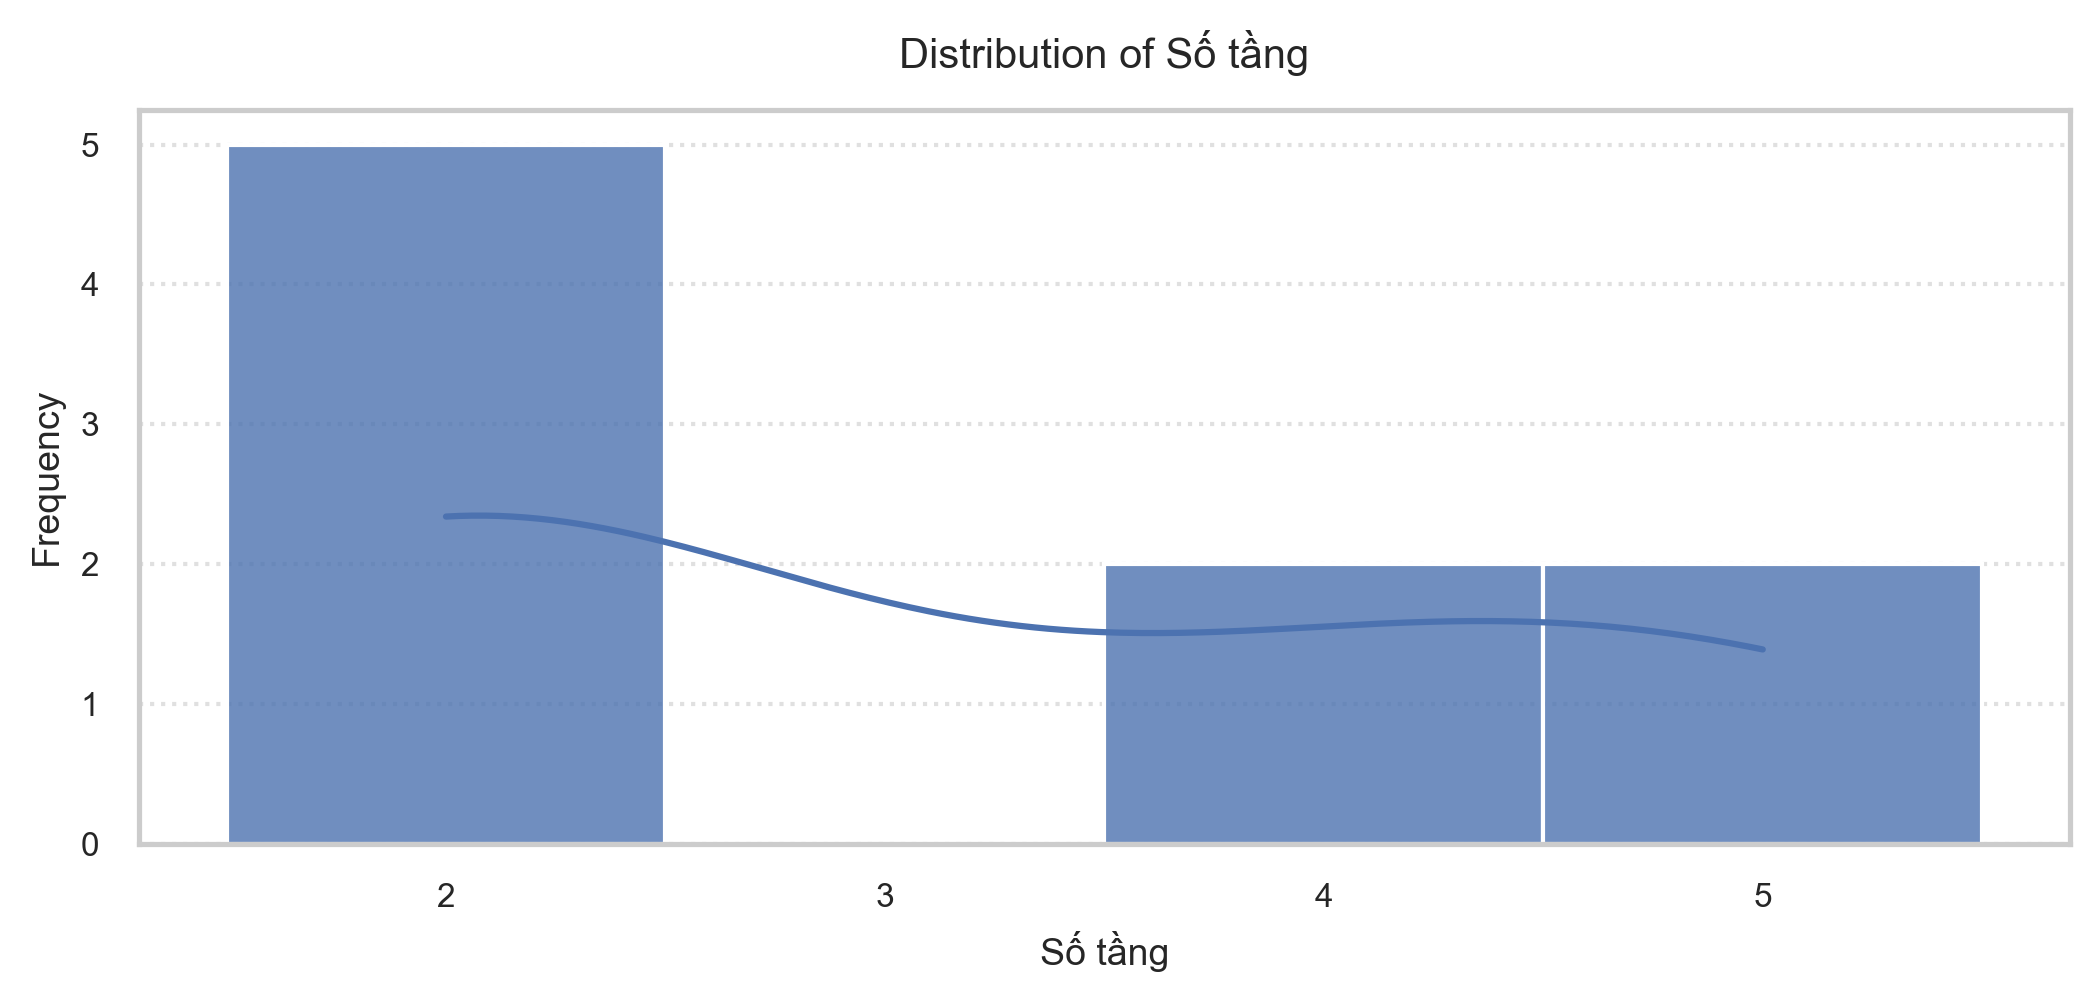

In [272]:

floors_clean = df['Số tầng'].dropna()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial',
    'Helvetica',
    'DejaVu Sans'
]
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(
    figsize=(7.16, 3.5),
    dpi=300
)

sns.histplot(
    floors_clean,
    discrete=True,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.8,
    ax=ax
)

ax.set_title(
    'Distribution of Số tầng',
    fontsize=10,
    pad=10
)

ax.set_xlabel(
    'Số tầng',
    fontsize=9
)

ax.set_ylabel(
    'Frequency',
    fontsize=9
)

ax.xaxis.set_major_locator(
    MaxNLocator(
        integer=True,
        nbins=10
    )
)

ax.tick_params(
    axis='both',
    labelsize=8
)

ax.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

ax.grid(
    axis='x',
    visible=False
)

plt.tight_layout()
plt.show()


In [273]:

so_tang_clean = X_train['Số tầng'].dropna()

Q1 = so_tang_clean.quantile(0.25)
Q3 = so_tang_clean.quantile(0.75)
IQR = Q3 - Q1
upper_bound_iqr = Q3 + 1.5 * IQR

outliers_iqr = X_train[X_train['Số tầng'] > upper_bound_iqr]

print("IQR Outlier Detection")
print(f"Upper floor threshold: {upper_bound_iqr:.2f}")
print(f"Number of outlier records: {len(outliers_iqr)} / {len(X_train)}")

threshold_99 = so_tang_clean.quantile(0.99)
outliers_extreme = X_train[X_train['Số tầng'] > threshold_99]

print("\n99th Percentile Outlier Detection")
print(f"99th percentile threshold: {threshold_99:.2f}")
print(f"Number of extreme outliers: {len(outliers_extreme)}")

print("\nTop 10 Properties with the Highest Number of Floors")

cols_to_check = [
    'Link',
    'Diện tích',
    'Khoảng giá_log',
    'Số tầng',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh'
]

cols_to_display = [col for col in cols_to_check if col in X_train.columns]

display(
    X_train
    .sort_values(by='Số tầng', ascending=False)[cols_to_display]
    .head(10)
)


IQR Outlier Detection
Upper floor threshold: 4.50
Number of outlier records: 1 / 7

99th Percentile Outlier Detection
99th percentile threshold: 4.94
Number of extreme outliers: 1

Top 10 Properties with the Highest Number of Floors


,Link,Diện tích,Khoảng giá_log,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh"
8,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,343.0,3.850148,5.0,5,5
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,58.0,2.532903,4.0,4,4
5,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,142.0,2.821379,2.0,3,3
0,https://batdongsan.com.vn/ban-nha-rieng-duong-...,49.0,1.704748,2.0,3,3
4,https://batdongsan.com.vn/ban-nha-rieng-duong-...,50.0,1.756132,2.0,3,3
3,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,61.0,1.987874,2.0,3,1
6,https://batdongsan.com.vn/ban-nha-rieng-duong-...,25.0,1.566530,2.0,3,3


This outlier is an error during data collection. Delete.

In [274]:
target_link = "https://batdongsan.com.vn/ban-nha-biet-thu-lien-ke-vinhomes-green-paradise-xa-can-gio-tp-ho-chi-minh/50-dau-tien-suat-noi-bo-dac-ck-20-np-bt-mat-bien-gia-tu-4-ty-lh-pr44024453?vrs=1"

outlier_index = df[df['Link'] == target_link].index

if not outlier_index.empty:
    print(f"Outlier record found at index: {list(outlier_index)}")

    df = df.drop(index=outlier_index)

    X_train = X_train.drop(index=outlier_index, errors='ignore')
    y_train = y_train.drop(index=outlier_index, errors='ignore')

    X_test = X_test.drop(index=outlier_index, errors='ignore')
    y_test = y_test.drop(index=outlier_index, errors='ignore')

    print("Outlier successfully removed from df, X_train, y_train, X_test, and y_test.")

    print(f"Current X_train shape: {X_train.shape}")
    print(f"Current X_test shape: {X_test.shape}")
else:
    print("No matching record was found for the specified link. Please verify the URL and try again.")


No matching record was found for the specified link. Please verify the URL and try again.


In [275]:
outlier_indices = df[df['Số tầng'] > 20].index

if not outlier_indices.empty:
    print(f"Found {len(outlier_indices)} outlier records with floor count > 20.")

    df = df.drop(index=outlier_indices)

    X_train = X_train.drop(index=outlier_indices, errors='ignore')
    y_train = y_train.drop(index=outlier_indices, errors='ignore')

    X_test = X_test.drop(index=outlier_indices, errors='ignore')
    y_test = y_test.drop(index=outlier_indices, errors='ignore')

    print("Successfully removed all outliers with floor count > 20 from df, X_train, y_train, X_test, and y_test.")

    print(f"Current X_train shape: {X_train.shape}")
    print(f"Current X_test shape: {X_test.shape}")
else:
    print("No records found with floor count greater than 20.")


No records found with floor count greater than 20.


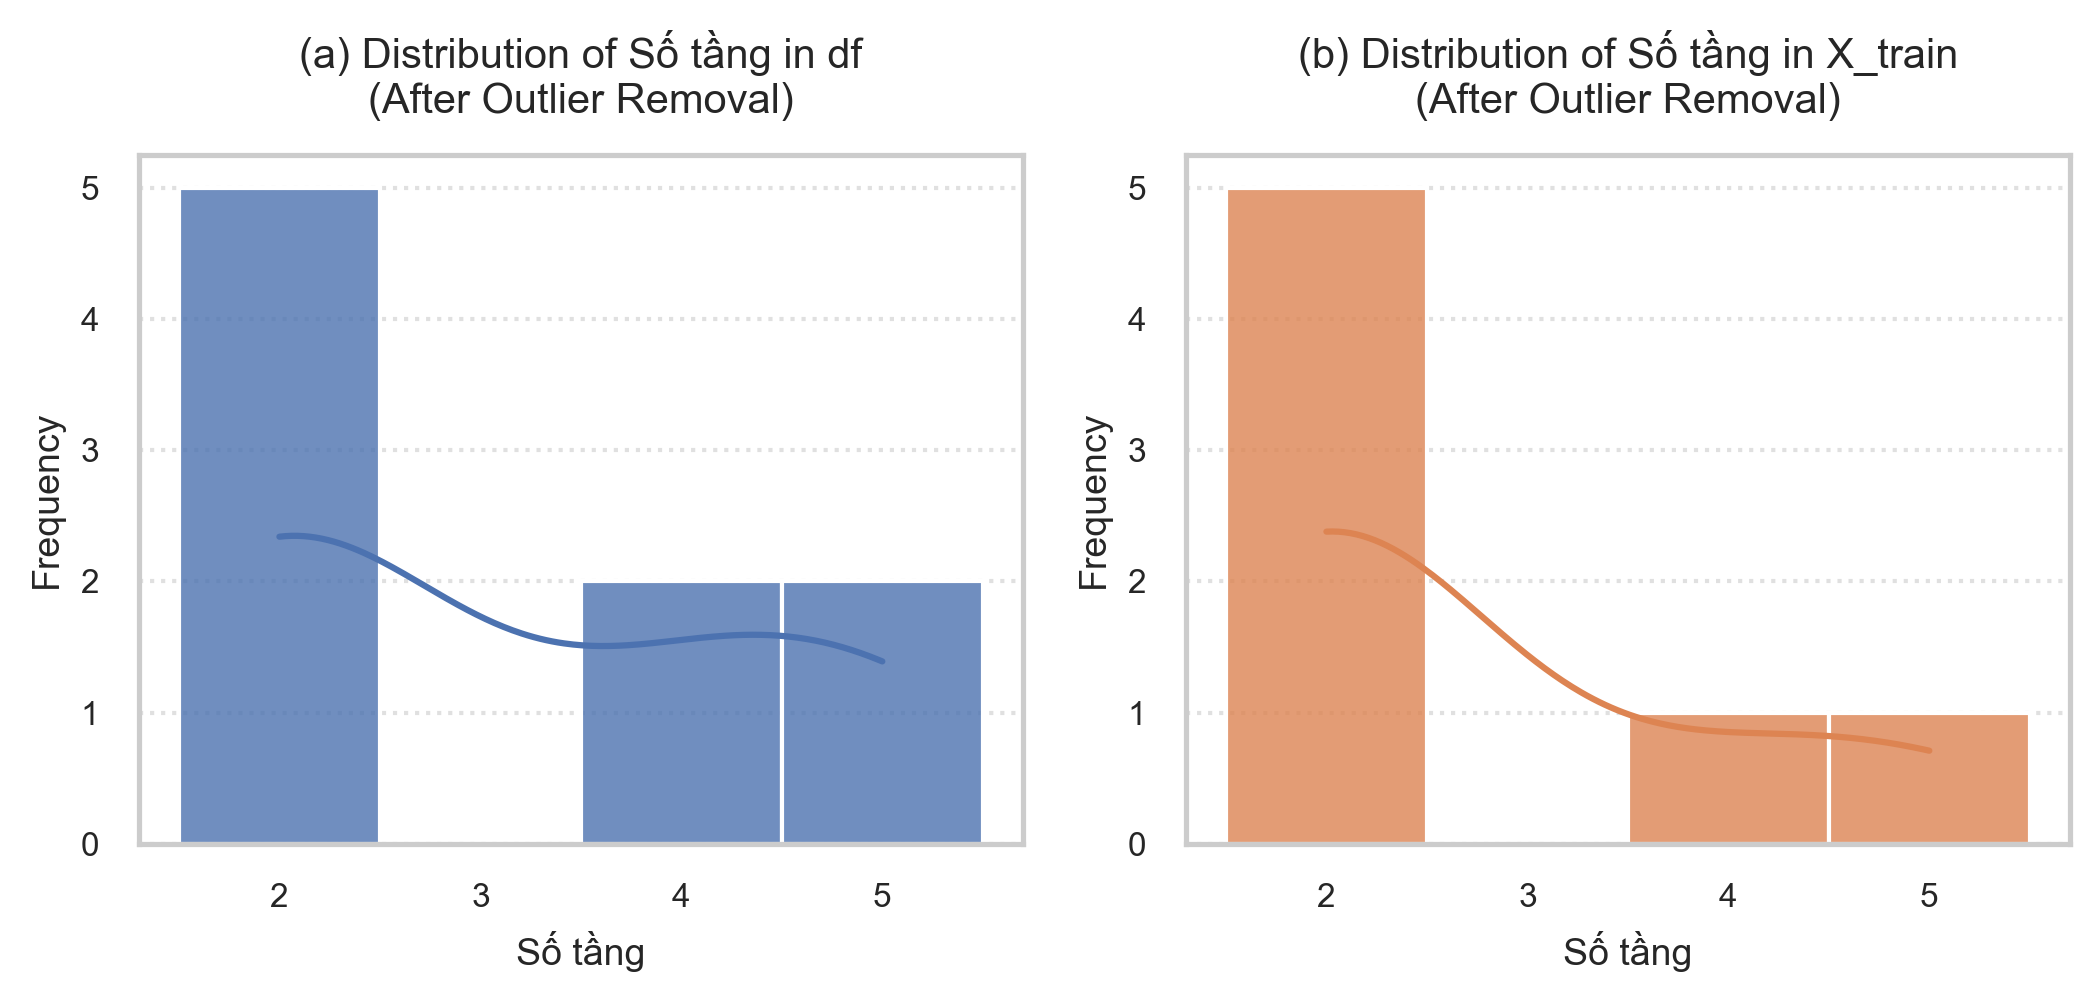

In [276]:

so_tang_df_clean = df['Số tầng'].dropna()
so_tang_train_clean = X_train['Số tầng'].dropna()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

sns.histplot(
    so_tang_df_clean,
    discrete=True,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title('(a) Distribution of Số tầng in df\n(After Outlier Removal)', fontsize=10, pad=10)
axes[0].set_xlabel('Số tầng', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[0].tick_params(axis='both', labelsize=8)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)

sns.histplot(
    so_tang_train_clean,
    discrete=True,
    kde=True,
    color='#DD8452',
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title('(b) Distribution of Số tầng in X_train\n(After Outlier Removal)', fontsize=10, pad=10)
axes[1].set_xlabel('Số tầng', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[1].tick_params(axis='both', labelsize=8)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

plt.tight_layout()

plt.show()


- In the townhouse market in large cities like Ho Chi Minh City, the distribution of the number of floors is often not a uniform bell curve but is always divided by 2 main groups of customers/objects: 
- Group "Small houses /Alley houses" (Top 2 -3 floors): These are usually houses built a long time ago, houses with small area (under 40m²), or located deep in small alleys. Construction regulations in these alleys often limit height (only allowed to build 2-3 floors). 
- "Modern townhouse" group (Top at 4 -5 floors): This is the "gold standard" of townhouses today. Popular designs are: 1 ground floor + 1 mezzanine + 2 floors + 1 terrace (equivalent to 4-5 floors). Houses on frontages or large alleys are often allowed to build up to this level to optimize space. 
- Based on the correlation matrix of missing numbers, the missing "Number of floors" is not strongly correlated with other columns, so it is highly likely that "Number of floors" is MCAR. 

- Number of records showing lack of iron (>5%) 

- With this distribution, you cannot fill in the mean or median because it will lose the distribution shape of the data (2-peak distribution). The correlations show that using a multivariate interpolation model will be able to make more accurate inferences. 

- Conclusion: Use models for multivariate interpolation. 

- Select model: 
   -Discrete data (number of bathrooms, number of bedrooms), 
    -Room numbers are divided into 2 groups. 
    -The data is skewed to the right (because outliers 14 still exist which are reasonable outliers).
-Decision tree-based models are effective for predicting these patterns.


### 2.3.2 Train the model on the test set and verify


1. Visualizing original data distribution


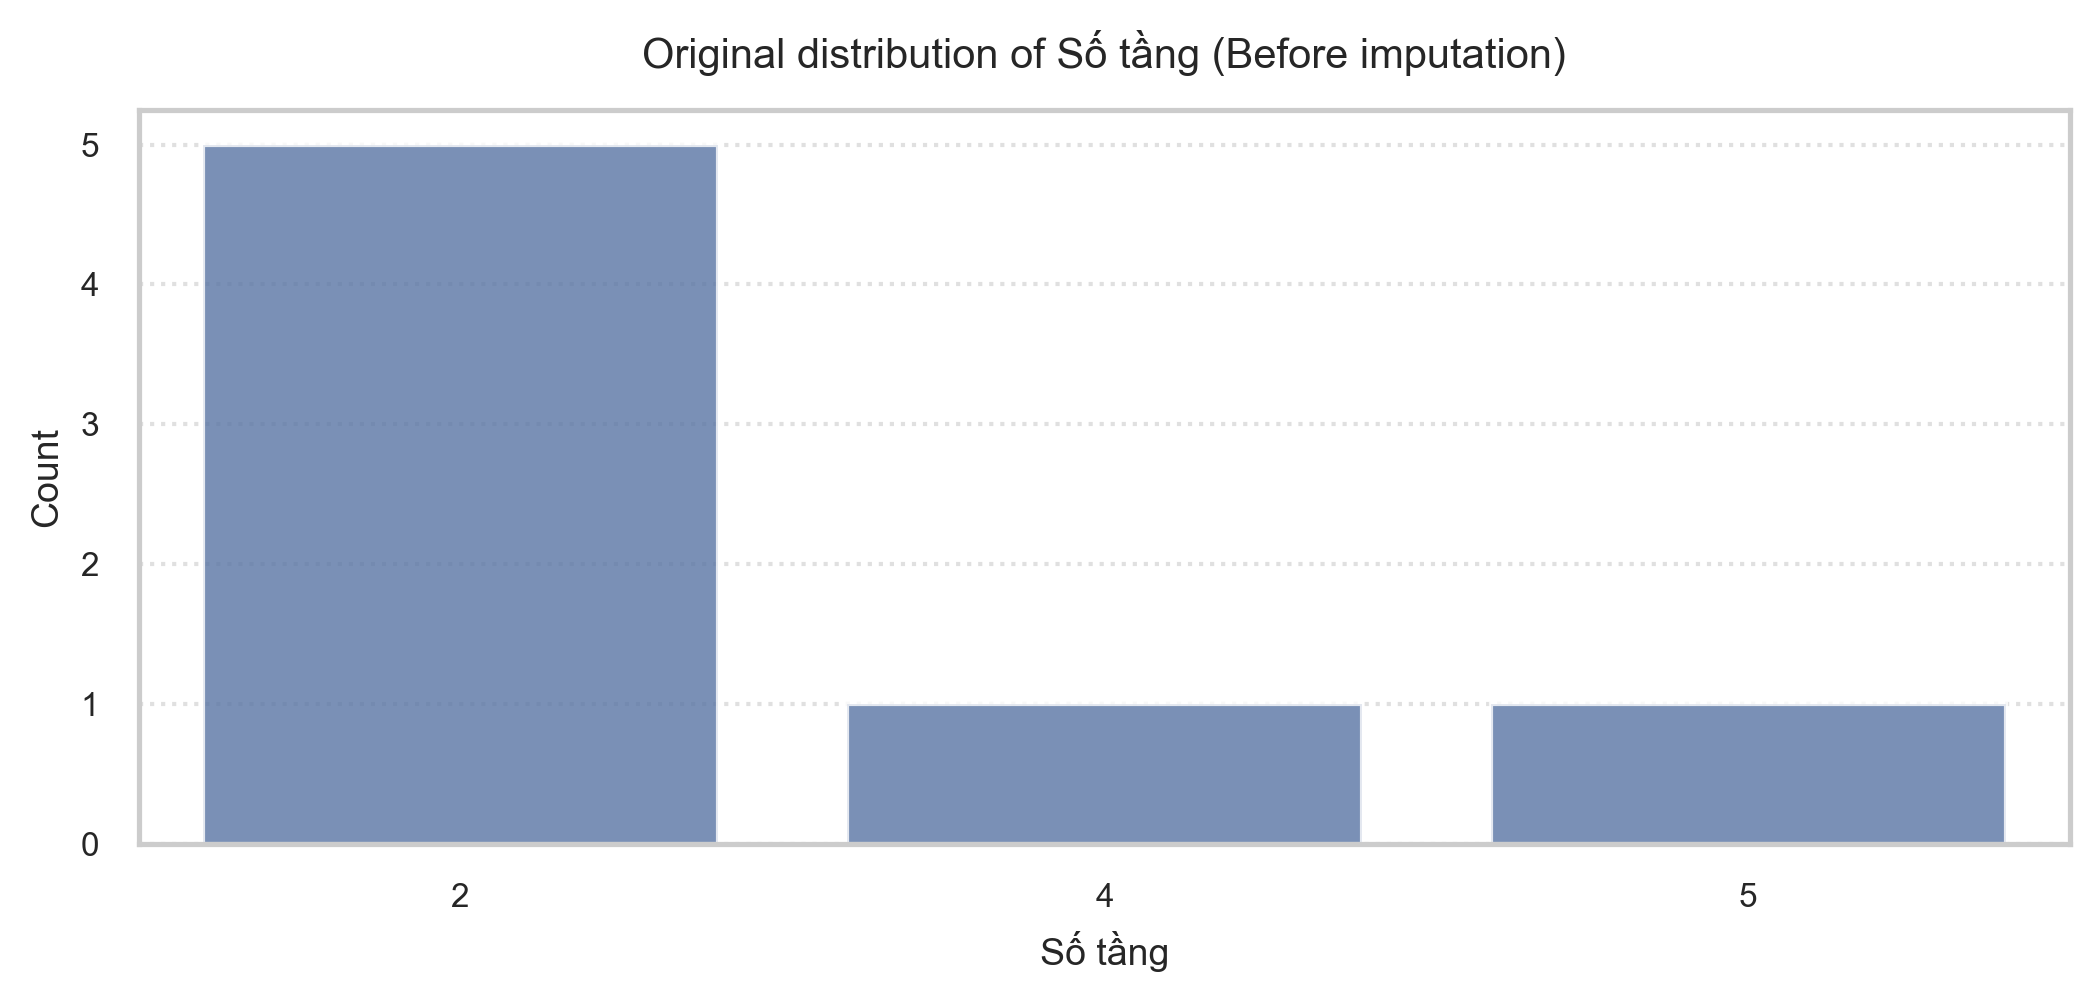


2. Running Random Forest Imputer. Please wait...
Imputation completed. Remaining NaN count: 0

3. Comparing distributions before and after imputation


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\1789293015.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')


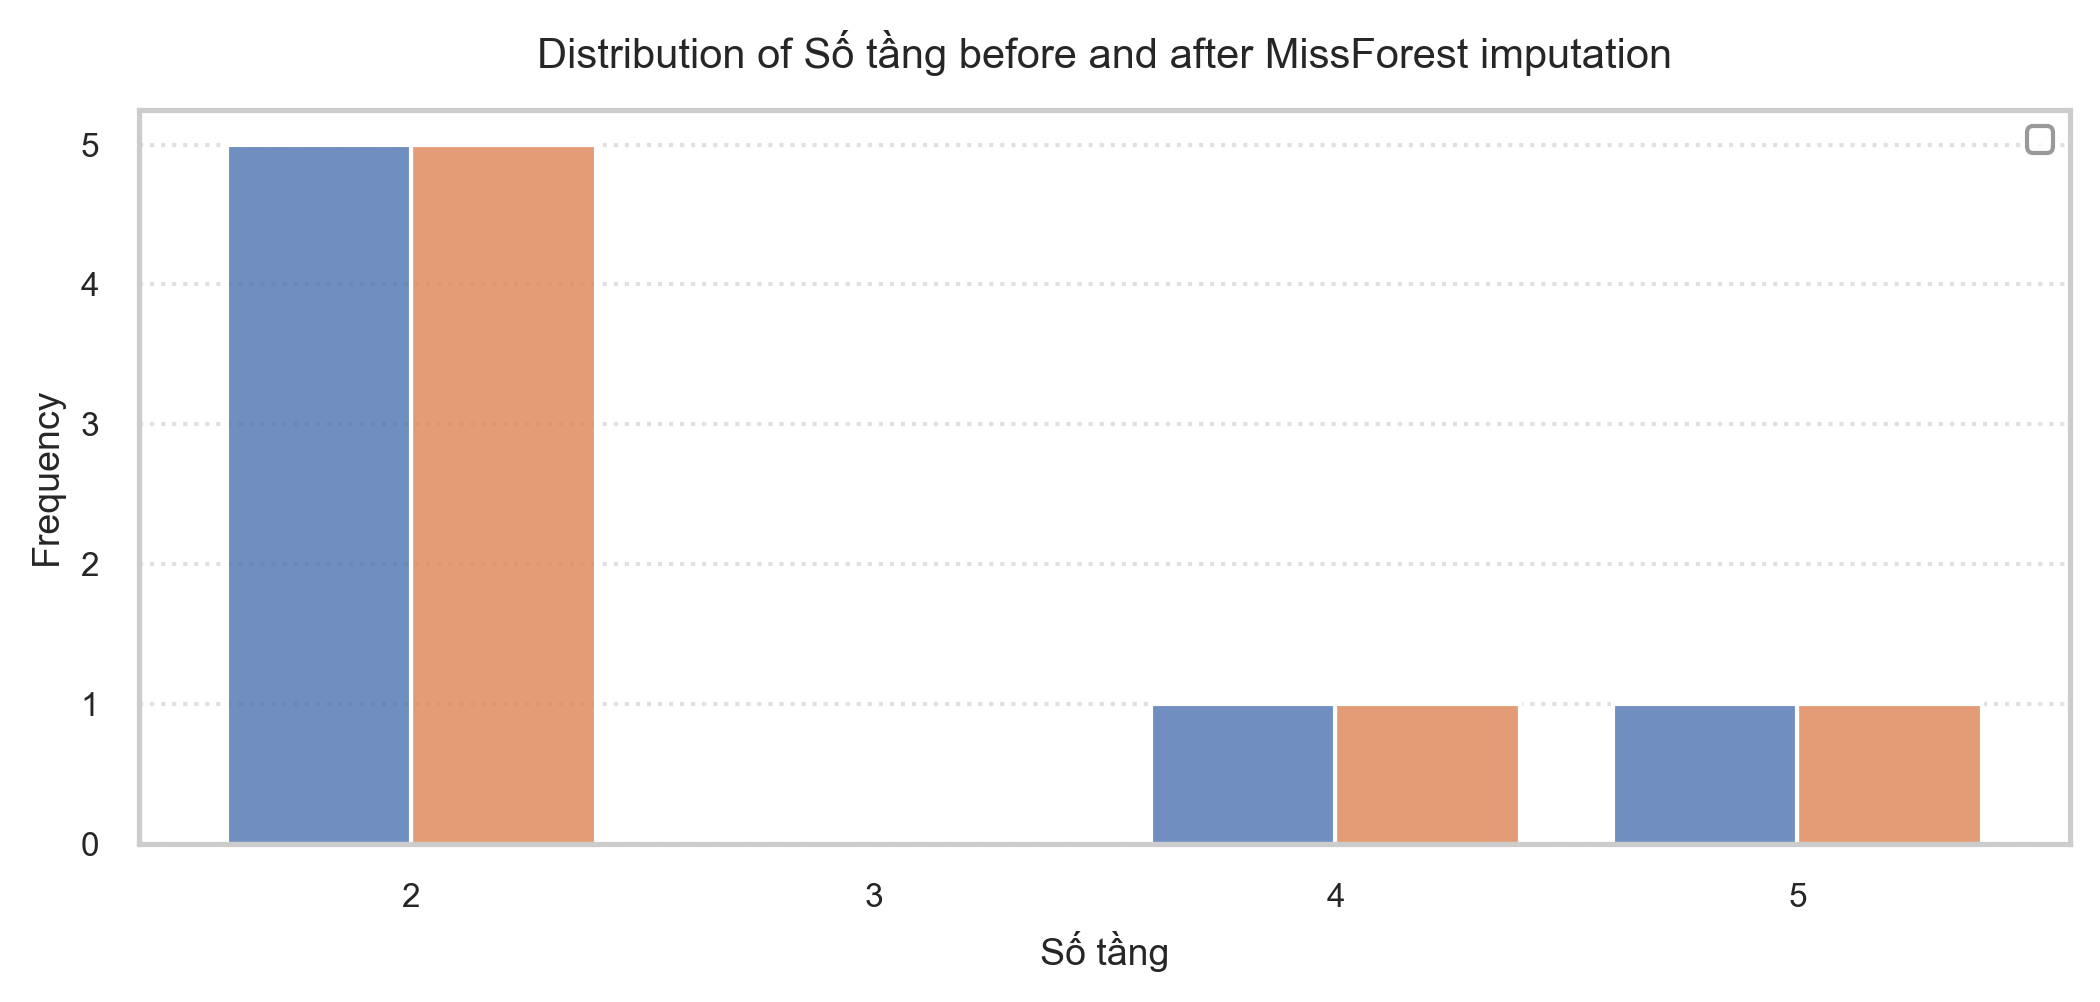

In [277]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print("1. Visualizing original data distribution")
fig, ax1 = plt.subplots(figsize=(7.16, 3.5), dpi=300)

sns.countplot(
    x=X_train['Số tầng'].dropna().astype(int),
    color='#4C72B0',
    alpha=0.8,
    edgecolor='white',
    ax=ax1
)

ax1.set_title('Original distribution of Số tầng (Before imputation)', fontsize=10, pad=10)
ax1.set_xlabel('Số tầng', fontsize=9)
ax1.set_ylabel('Count', fontsize=9)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax1.tick_params(axis='both', labelsize=8)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

print("\n2. Running Random Forest Imputer. Please wait...")

features_for_rf = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
X_train_rf = X_train[features_for_rf].copy()

rf_estimator = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

missforest_imputer = IterativeImputer(
    estimator=rf_estimator,
    max_iter=10,
    random_state=42,
    min_value=1
)

X_train_imputed_array = missforest_imputer.fit_transform(X_train_rf)
X_train_imputed_df = pd.DataFrame(
    X_train_imputed_array,
    columns=features_for_rf,
    index=X_train.index
)

X_train['Số tầng (MissForest)'] = np.round(
    X_train_imputed_df['Số tầng']
).astype(int)

print("Imputation completed. Remaining NaN count:",
      X_train['Số tầng (MissForest)'].isnull().sum())

print("\n3. Comparing distributions before and after imputation")
fig, ax2 = plt.subplots(figsize=(7.16, 3.5), dpi=300)

plot_data = pd.DataFrame({
    'Before imputation (Original)': X_train['Số tầng'],
    'After imputation (MissForest)': X_train['Số tầng (MissForest)']
})

sns.histplot(
    data=plot_data,
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    palette=['#4C72B0', '#DD8452'],
    alpha=0.8,
    edgecolor='white',
    ax=ax2
)

ax2.set_title('Distribution of Số tầng before and after MissForest imputation', fontsize=10, pad=10)
ax2.set_xlabel('Số tầng', fontsize=9)
ax2.set_ylabel('Frequency', fontsize=9)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
ax2.tick_params(axis='both', labelsize=8)
ax2.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='gray')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()


Due to the good model and small sample number, the dry distribution is highly skewed when filling in gaps.

### 2.3.3 Apply to train and test

In [278]:
X_train['Số tầng'] = X_train['Số tầng (MissForest)']
X_train = X_train.drop(columns=['Số tầng (MissForest)'])


In [279]:

features_for_rf = [
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng'
]

X_test_rf = X_test[features_for_rf].copy()

X_test_imputed_array = missforest_imputer.transform(X_test_rf)

X_test_imputed_df = pd.DataFrame(
    X_test_imputed_array,
    columns=features_for_rf,
    index=X_test.index
)

X_test['Số tầng'] = np.round(X_test_imputed_df['Số tầng']).astype(int)

print("Imputation for X_test completed successfully.")
print("Remaining NaN values in 'Số tầng':", X_test['Số tầng'].isnull().sum())

if 'Số tầng (MissForest)' in X_train.columns:
    X_train['Số tầng'] = X_train['Số tầng (MissForest)']
    X_train = X_train.drop(columns=['Số tầng (MissForest)'])
    print("Training set finalized: 'Số tầng' column cleaned and updated.")


Imputation for X_test completed successfully.
Remaining NaN values in 'Số tầng': 0


## 2.4Column processing 'Đường vào'

### 2.4.1 Outlier distribution and processing


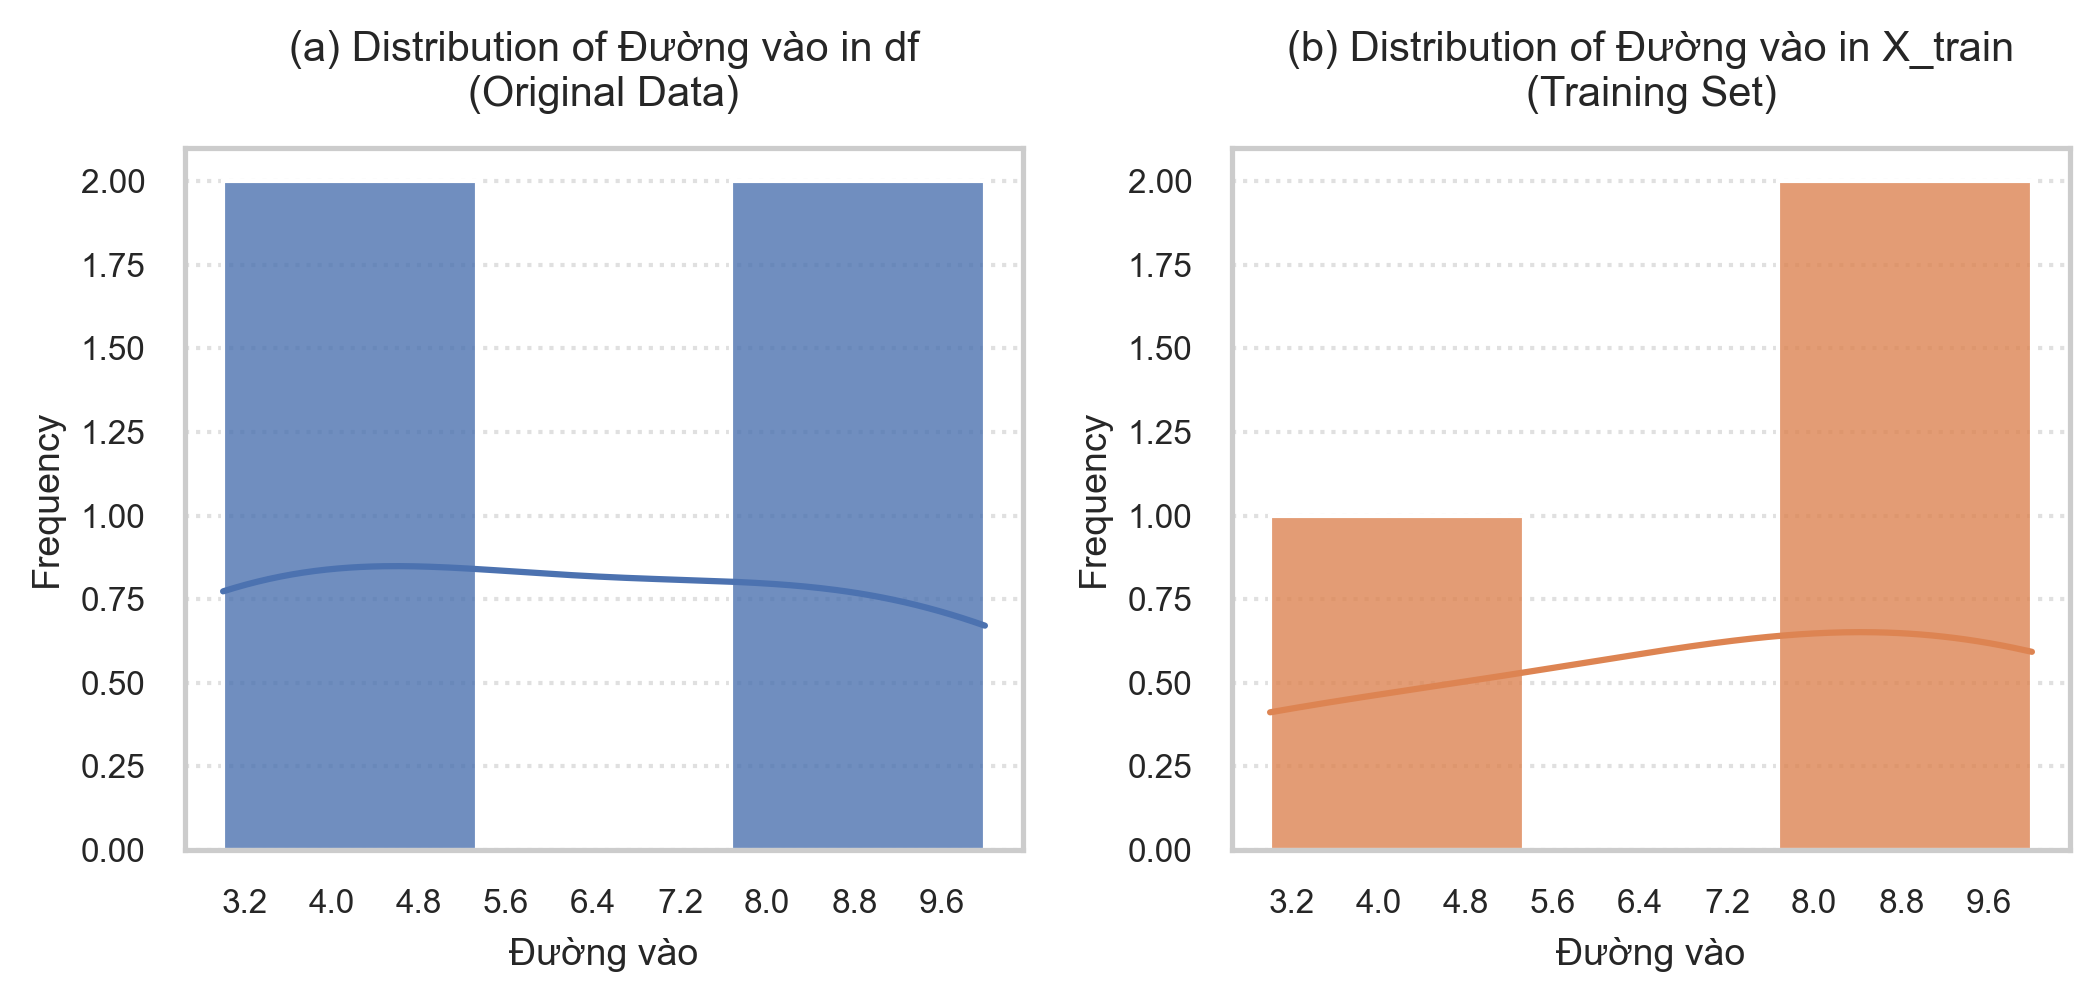

In [280]:

duong_vao_df = df['Đường vào'].dropna()
duong_vao_train = X_train['Đường vào'].dropna()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

sns.histplot(
    duong_vao_df,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title('(a) Distribution of Đường vào in df\n(Original Data)', fontsize=10, pad=10)
axes[0].set_xlabel('Đường vào', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0].tick_params(axis='both', labelsize=8)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)

sns.histplot(
    duong_vao_train,
    kde=True,
    color='#DD8452',
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title('(b) Distribution of Đường vào in X_train\n(Training Set)', fontsize=10, pad=10)
axes[1].set_xlabel('Đường vào', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1].tick_params(axis='both', labelsize=8)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

plt.tight_layout()
plt.show()


In [281]:

outliers_duong_vao = df[df['Đường vào'] > 50]

print(f"Total number of records with street width > 50m: {len(outliers_duong_vao)}\n")

if not outliers_duong_vao.empty:
    print("=== DETAILED LIST OF STREET WIDTH OUTLIERS ===")

    cols_to_display = [c for c in ['Link', 'Đường vào', 'Diện tích', 'Số tầng'] if c in df.columns]

    display(outliers_duong_vao[cols_to_display].sort_values(by='Đường vào', ascending=False))
else:
    print("No records found with street width greater than 50m.")


Total number of records with street width > 50m: 0

No records found with street width greater than 50m.


These Outliers are absurd: In a big city like Ho Chi Minh City, the widest street (like Vo Van Kiet and Nguyen Van Linh avenues) is only about 40m -60m.
These outliers are a consequence of:
-error when crawling data
-Error when entering data
-Delete

In [282]:
outlier_dv_indices = df[df['Đường vào'] > 50].index

if not outlier_dv_indices.empty:
    print(f"Detected {len(outlier_dv_indices)} outlier records with street width > 50m.")

    df = df.drop(index=outlier_dv_indices)

    X_train = X_train.drop(index=outlier_dv_indices, errors='ignore')
    y_train = y_train.drop(index=outlier_dv_indices, errors='ignore')
    X_test = X_test.drop(index=outlier_dv_indices, errors='ignore')
    y_test = y_test.drop(index=outlier_dv_indices, errors='ignore')

    print("Successfully removed all outliers with street width > 50m from df, X_train, y_train, X_test, and y_test.")

    print(f"Current X_train shape: {X_train.shape}")
    print(f"Current X_test shape: {X_test.shape}")
else:
    print("No records found with street width greater than 50m.")


No records found with street width greater than 50m.


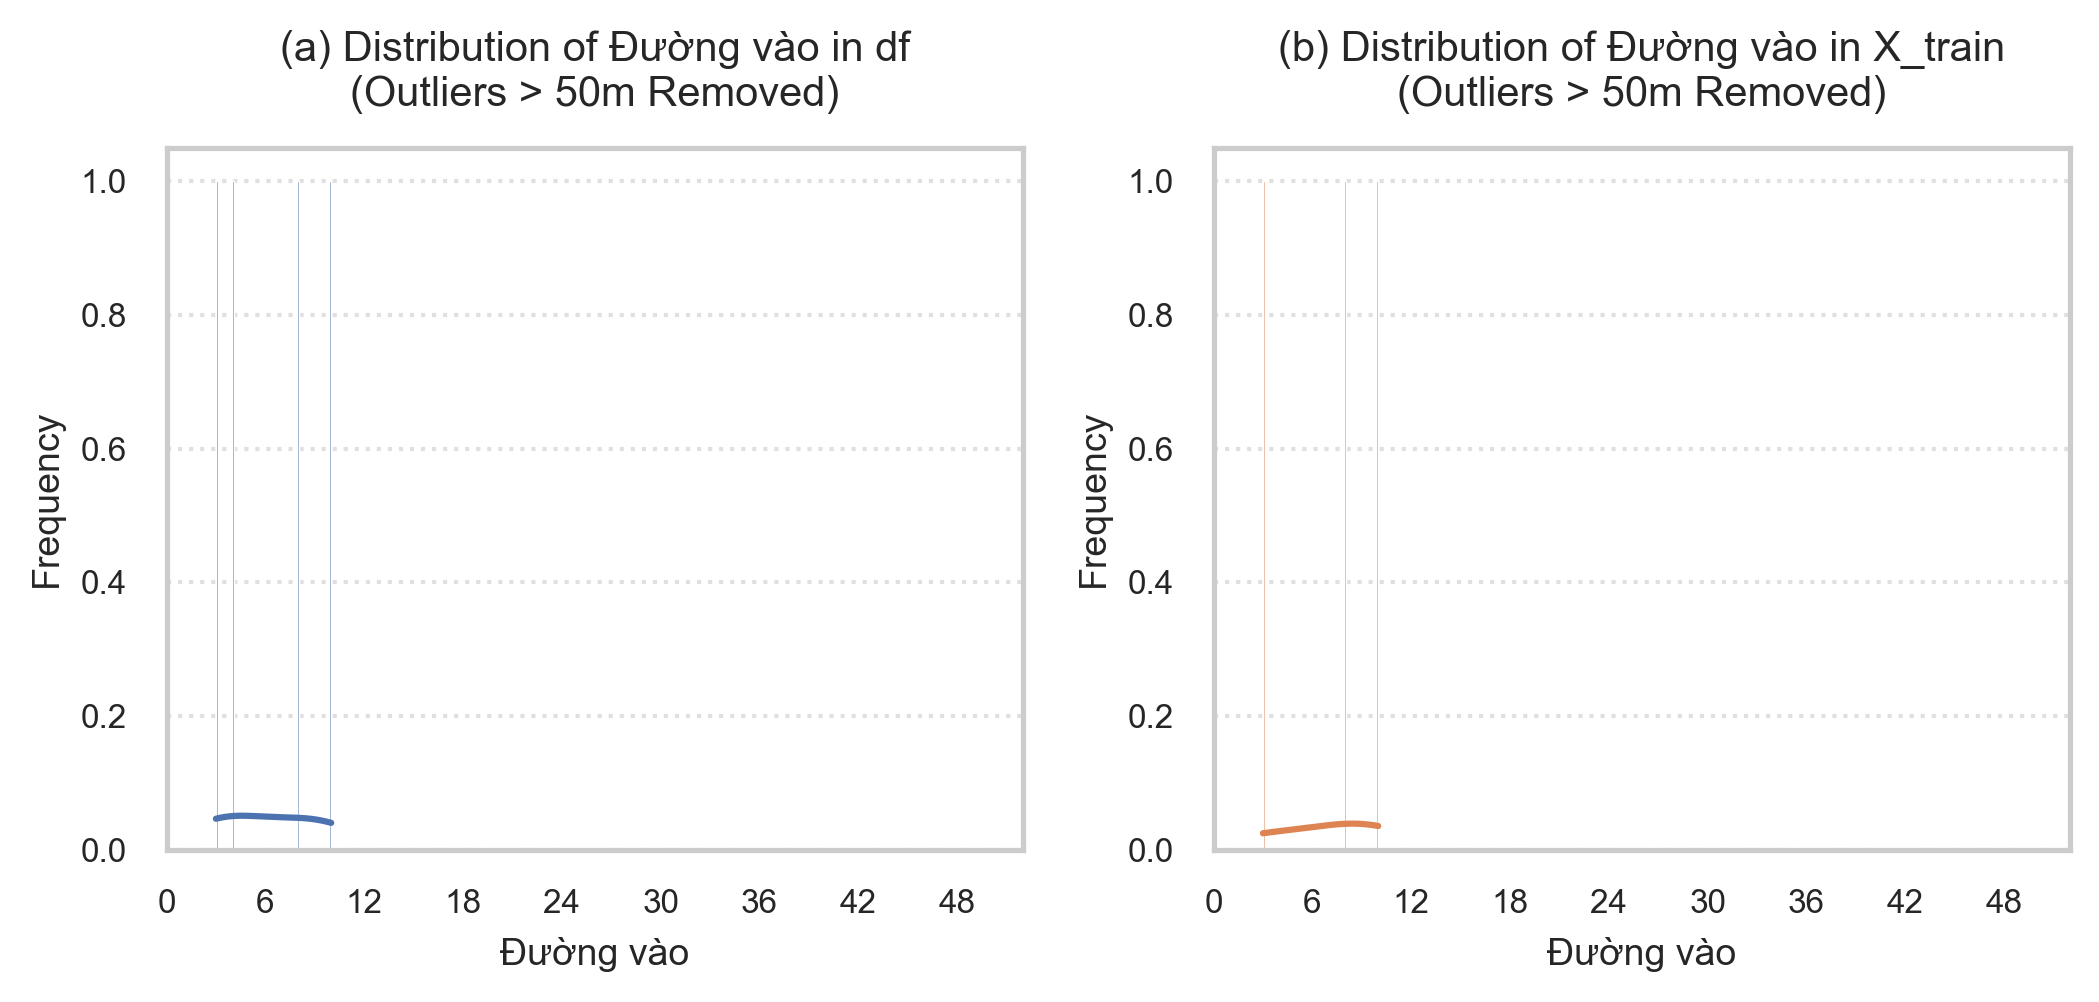

In [283]:

clean_df_dv = df['Đường vào'].dropna()
clean_train_dv = X_train['Đường vào'].dropna()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5), dpi=300)

sns.histplot(
    clean_df_dv,
    bins=50,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title('(a) Distribution of Đường vào in df\n(Outliers > 50m Removed)', fontsize=10, pad=10)
axes[0].set_xlabel('Đường vào', fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=9)
axes[0].set_xlim(0, 52)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0].tick_params(axis='both', labelsize=8)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].grid(axis='x', visible=False)

sns.histplot(
    clean_train_dv,
    bins=50,
    kde=True,
    color='#DD8452',
    edgecolor='white',
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title('(b) Distribution of Đường vào in X_train\n(Outliers > 50m Removed)', fontsize=10, pad=10)
axes[1].set_xlabel('Đường vào', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)
axes[1].set_xlim(0, 52)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1].tick_params(axis='both', labelsize=8)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].grid(axis='x', visible=False)

plt.tight_layout()
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\1764059445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\1764059445.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\1764059445.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\1764059445.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1

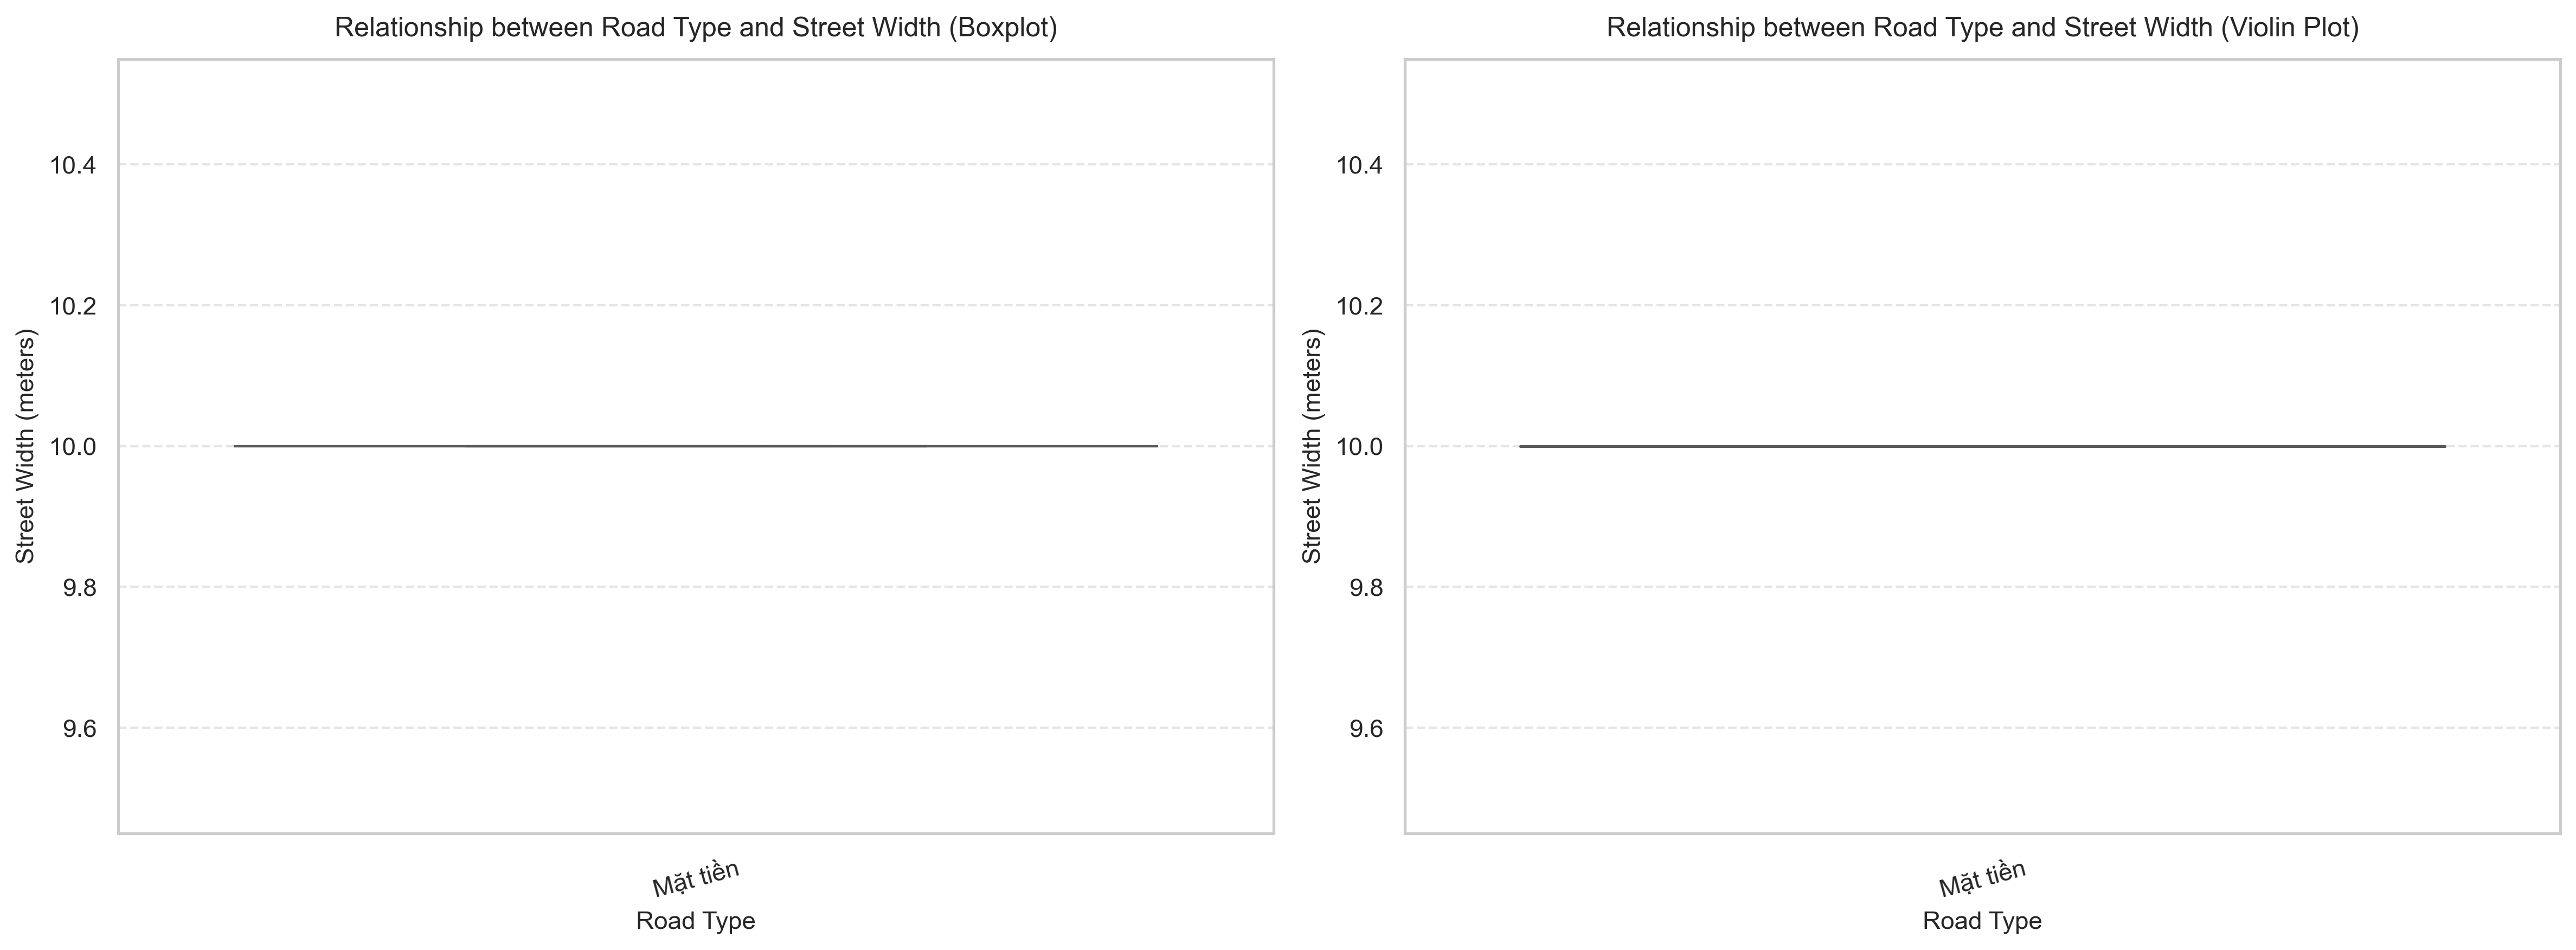

In [284]:

plot_data = X_train[['Loại đường vào', 'Đường vào']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Relationship between Road Type and Street Width (Boxplot)', fontsize=12, pad=10)
axes[0].set_xlabel('Road Type', fontsize=11)
axes[0].set_ylabel('Street Width (meters)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

sns.violinplot(
    data=plot_data,
    x='Loại đường vào',
    y='Đường vào',
    palette='Set2',
    inner='quartile',
    ax=axes[1]
)

axes[1].set_title('Relationship between Road Type and Street Width (Violin Plot)', fontsize=12, pad=10)
axes[1].set_xlabel('Road Type', fontsize=11)
axes[1].set_ylabel('Street Width (meters)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


Analyzing missingness pattern of 'Đường vào' across features...



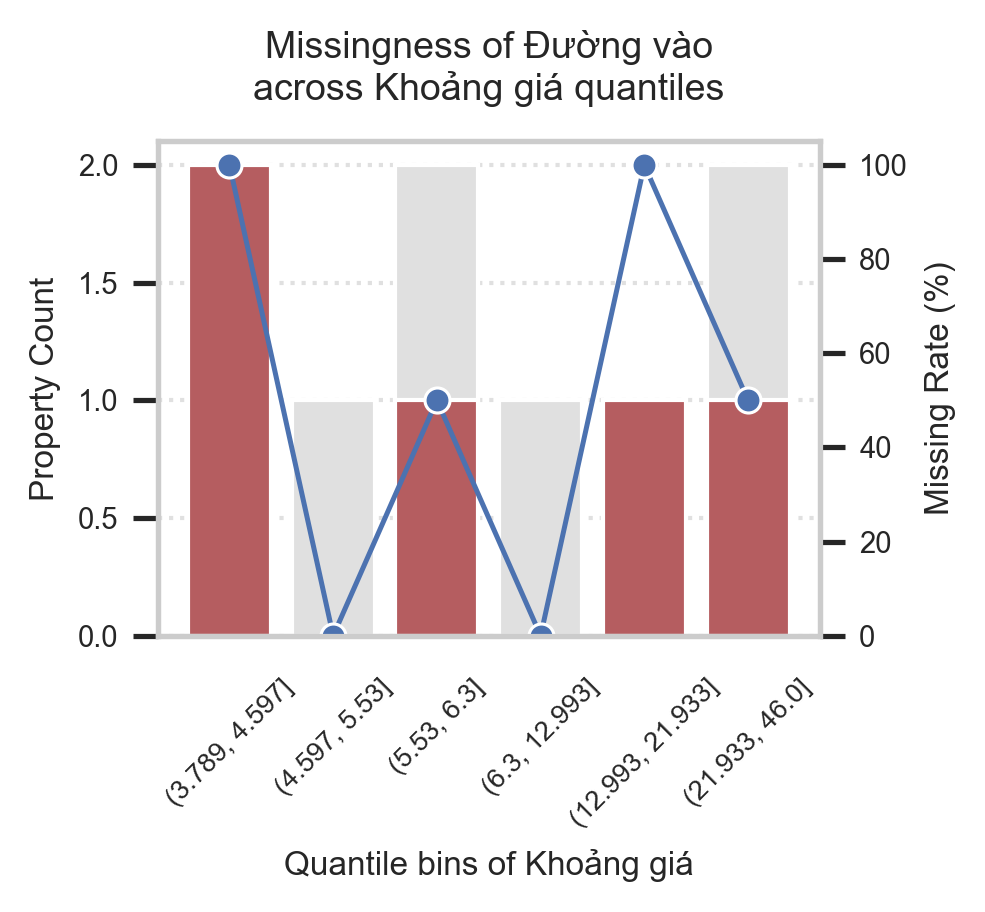

Completed plot for: Khoảng giá



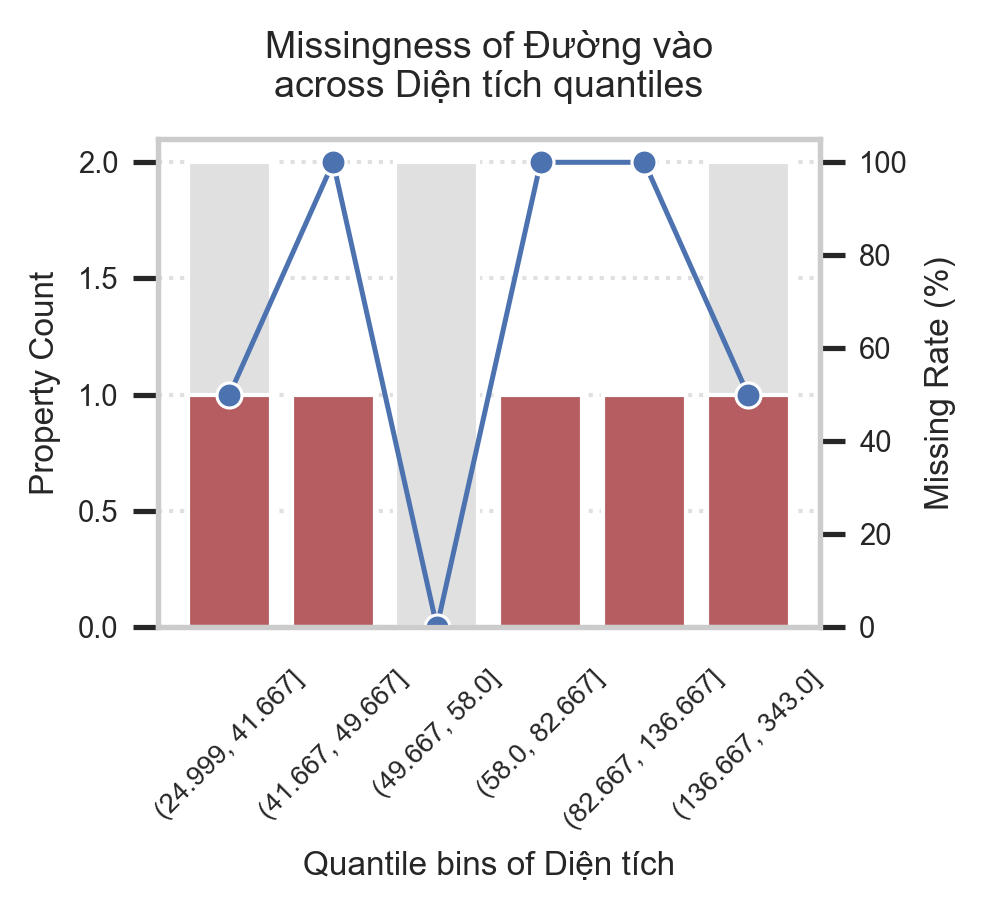

Completed plot for: Diện tích



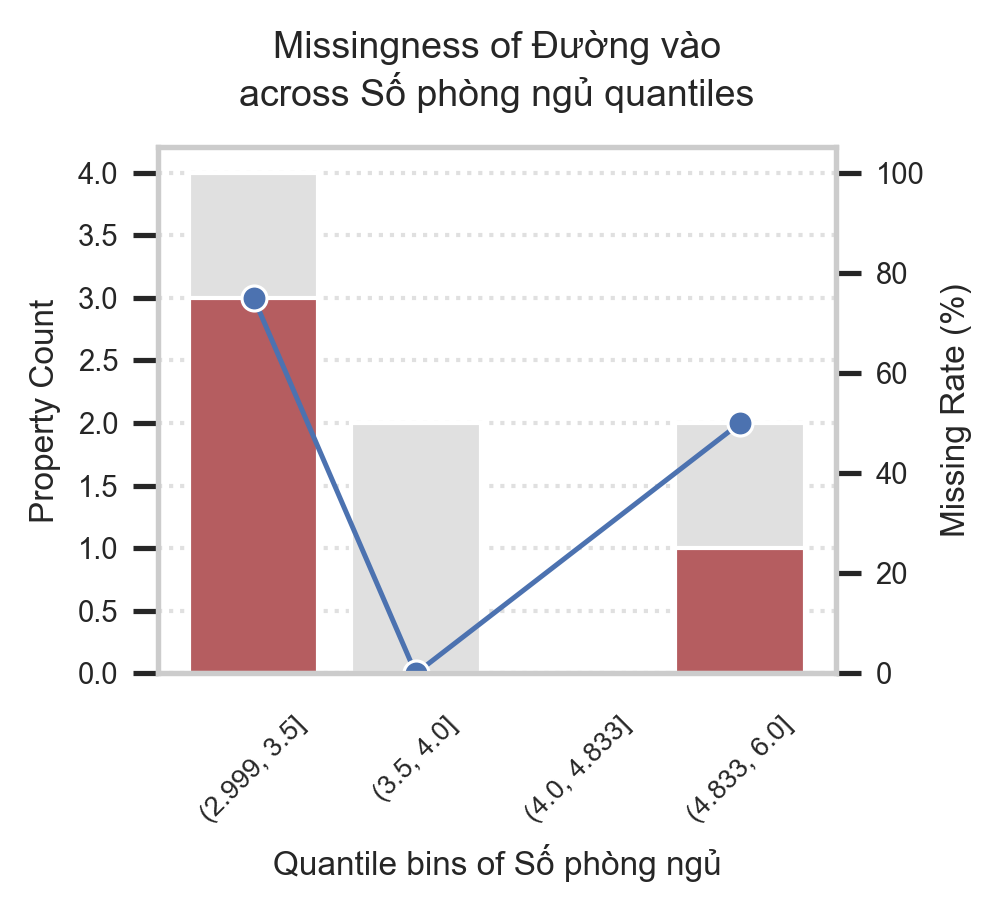

Completed plot for: Số phòng ngủ



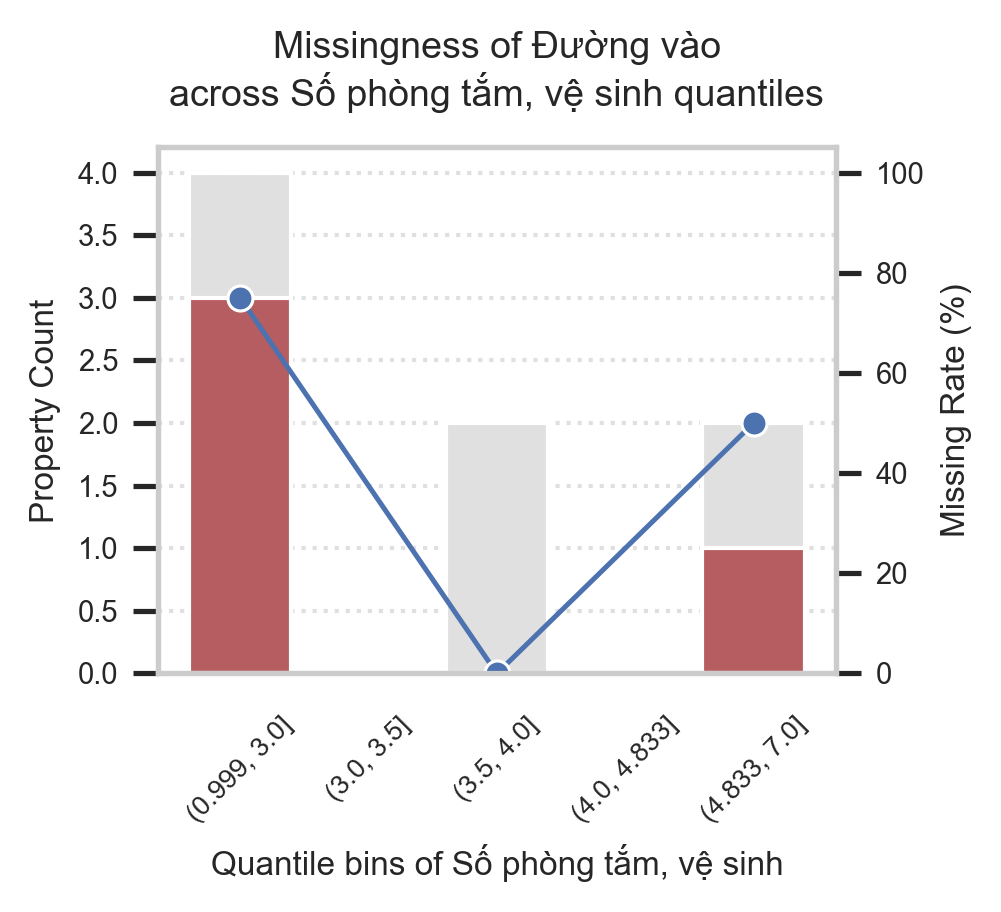

Completed plot for: Số phòng tắm, vệ sinh



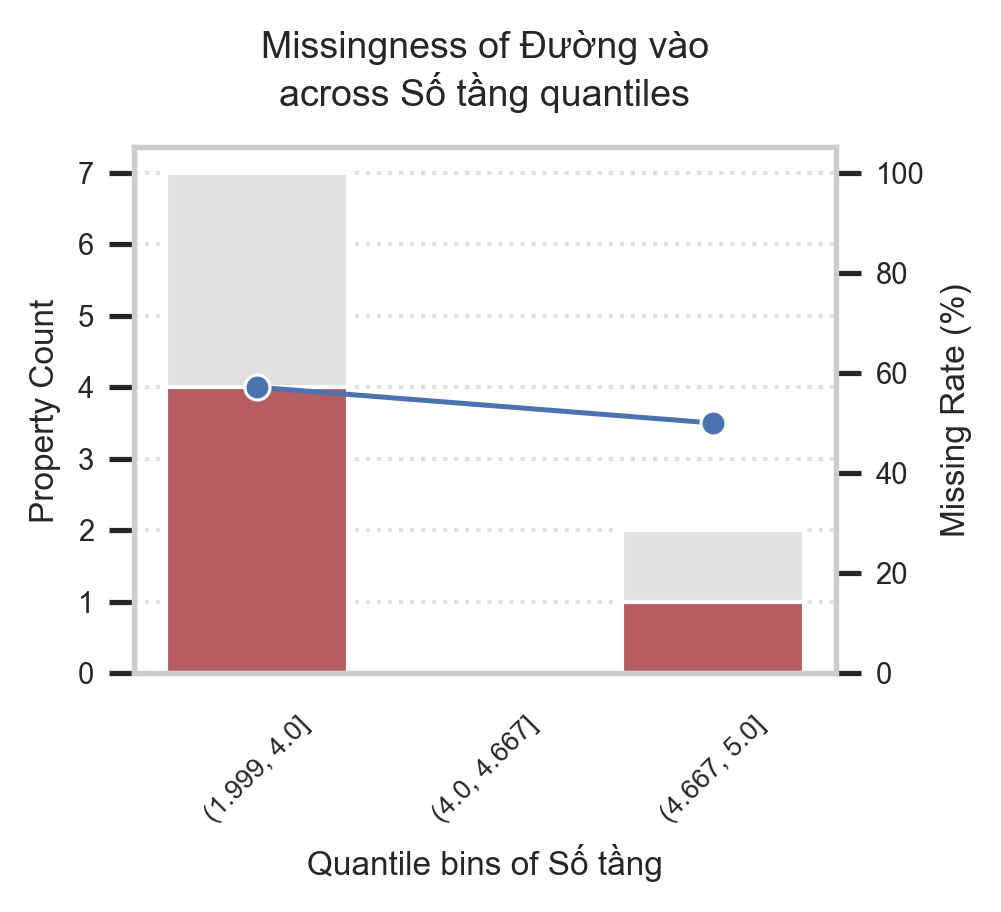

Completed plot for: Số tầng



In [285]:

def plot_missing_correlation_single_col(df, feature_cols, missing_col='Đường vào', q=6):
    print(f"Analyzing missingness pattern of '{missing_col}' across features...\n")

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    for col in feature_cols:
        df_plot = df.dropna(subset=[col]).copy()

        df_plot['Quantile_bin'] = pd.qcut(df_plot[col], q=q, duplicates='drop')

        missing_stats = df_plot.groupby('Quantile_bin', observed=False)[missing_col].agg(
            total='size',
            missing=lambda x: x.isna().sum()
        ).reset_index()

        missing_stats['missing_rate'] = (missing_stats['missing'] / missing_stats['total']) * 100

        fig, ax1 = plt.subplots(figsize=(3.5, 3.2), dpi=300)

        sns.barplot(
            data=missing_stats,
            x='Quantile_bin',
            y='total',
            color='#E0E0E0',
            ax=ax1,
            edgecolor='white'
        )

        sns.barplot(
            data=missing_stats,
            x='Quantile_bin',
            y='missing',
            color='#C44E52',
            ax=ax1,
            edgecolor='white'
        )

        ax2 = ax1.twinx()

        sns.lineplot(
            x=np.arange(len(missing_stats)),
            y='missing_rate',
            data=missing_stats,
            color='#4C72B0',
            marker='o',
            linewidth=1.2,
            ax=ax2
        )

        ax1.set_ylabel('Property Count', fontsize=8)
        ax1.set_xlabel(f'Quantile bins of {col}', fontsize=8)
        ax1.tick_params(axis='x', rotation=45, labelsize=6.5)
        ax1.tick_params(axis='y', labelsize=7)

        ax2.set_ylabel('Missing Rate (%)', fontsize=8)
        ax2.tick_params(axis='y', labelsize=7)
        ax2.set_ylim(0, 105)

        ax1.grid(axis='y', linestyle=':', alpha=0.6)
        ax1.grid(axis='x', visible=False)
        ax2.grid(False)

        ax1.set_title(f'Missingness of {missing_col}\nacross {col} quantiles', fontsize=9, pad=10)

        plt.tight_layout()
        plt.show()

        print(f"Completed plot for: {col}\n" + "=" * 50 + "\n")


cols_to_check = [
    'Khoảng giá',
    'Diện tích',
    'Số phòng ngủ',
    'Số phòng tắm, vệ sinh',
    'Số tầng'
]

plot_missing_correlation_single_col(df, cols_to_check, missing_col='Đường vào', q=6)


MAR:
- Houses with higher prices are usually not located in alleys or in special geographical locations (rivers, seas, mountains, etc.) 
- The lack of "Access Road" data is not random (MCAR) but depends strongly on the size of the property. The bigger the house, the more floors, and the more rooms, the more likely the advertiser is to leave the "Entrance" column blank. This is completely logical and realistic: large-scale houses are often villas or houses facing large streets, where alley width is no longer a factor to worry about. 

phân phối bị sai lệch. Thử nghiệm nội suy bằng MICE và KNN

In [286]:
print(X_train.columns)


Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude',
       'Mô tả', 'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'So_Thua',
       'So_To', 'Dien_Tich_Lo', 'Ten_Do_An', 'QHPK_So_O', 'QHPK_Chuc_Nang',
       'QHPK_Dien_Tich', 'QHPK_Ty_Le', 'QHPK_Ma_QU', 'QHPK_Ma_O_Pho',
       'Trang_Thai', 'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc'],
      dtype='object')


Running KNN imputer experiment...


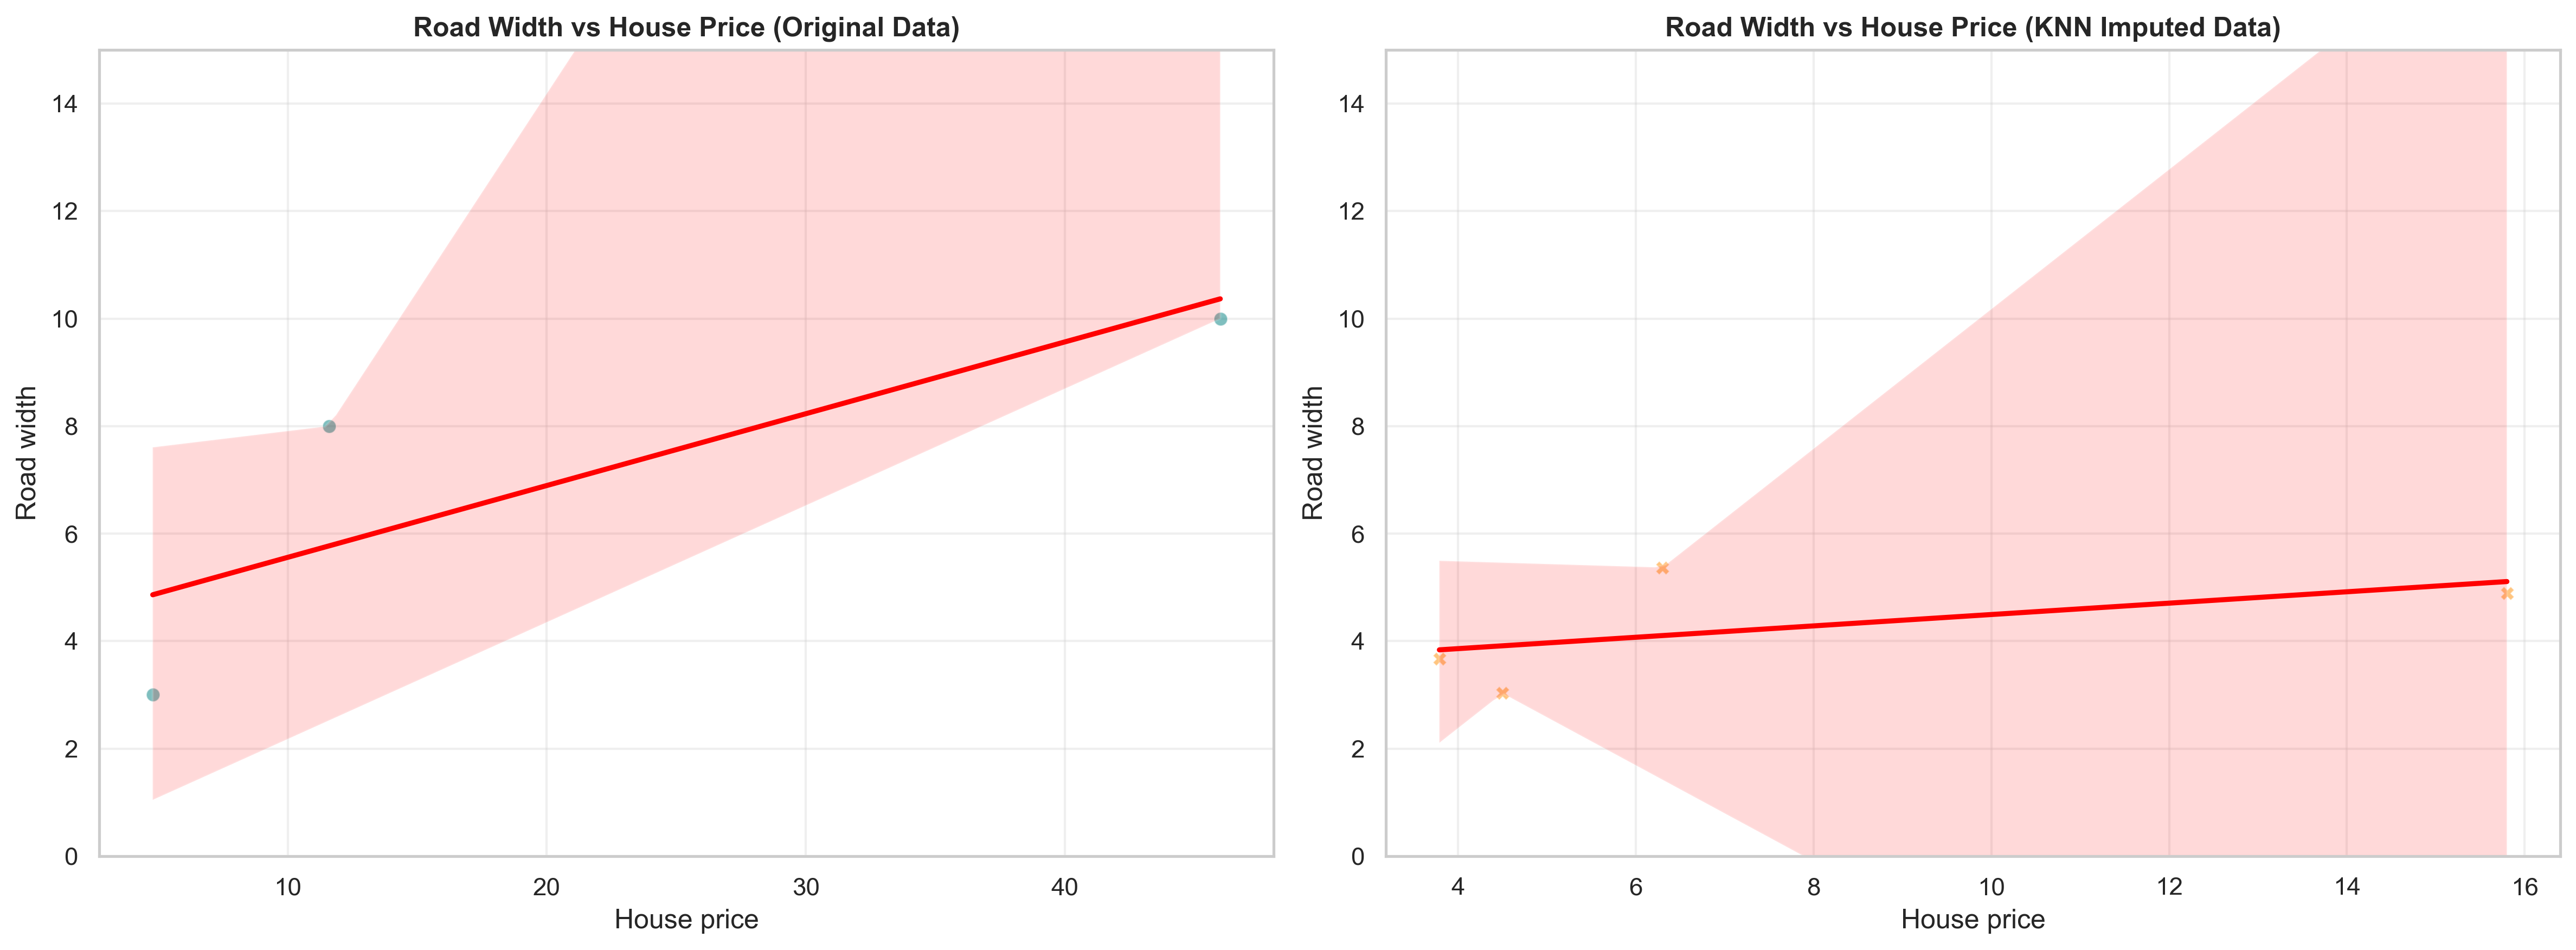

KNN Imputer experiment completed successfully.


In [287]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

print("Running KNN imputer experiment...")

num_cols = ['Diện tích', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Đường vào']

missing_cols = [col for col in num_cols if col not in X_train.columns]
if missing_cols:
    raise KeyError(f"Missing columns in X_train: {missing_cols}. Check X_train.columns.")

X_train_knn = X_train[num_cols].copy()

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_knn),
    columns=num_cols,
    index=X_train.index
)

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_knn_imputed_scaled = pd.DataFrame(
    knn_imputer.fit_transform(X_train_scaled),
    columns=num_cols,
    index=X_train.index
)

X_train_knn_imputed = pd.DataFrame(
    scaler.inverse_transform(X_train_knn_imputed_scaled),
    columns=num_cols,
    index=X_train.index
)

missing_idx = X_train['Đường vào'].isna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot_original = pd.DataFrame({
    'Road width': X_train.loc[~missing_idx, 'Đường vào'],
    'House price': y_train.loc[~missing_idx]
})

df_plot_imputed = pd.DataFrame({
    'Road width': X_train_knn_imputed.loc[missing_idx, 'Đường vào'],
    'House price': y_train.loc[missing_idx]
})

sns.scatterplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='teal',
    ax=axes[0]
)

sns.regplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[0]
)

axes[0].set_title('Road Width vs House Price (Original Data)', fontweight='bold')
axes[0].set_ylim(0, X_train['Đường vào'].max() + 5)

sns.scatterplot(
    data=df_plot_imputed,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='darkorange',
    marker='X',
    ax=axes[1]
)

sns.regplot(
    data=df_plot_imputed,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[1]
)

axes[1].set_title('Road Width vs House Price (KNN Imputed Data)', fontweight='bold')
axes[1].set_ylim(0, X_train['Đường vào'].max() + 5)

plt.tight_layout()
plt.show()

print("KNN Imputer experiment completed successfully.")


Running MICE imputer experiment...


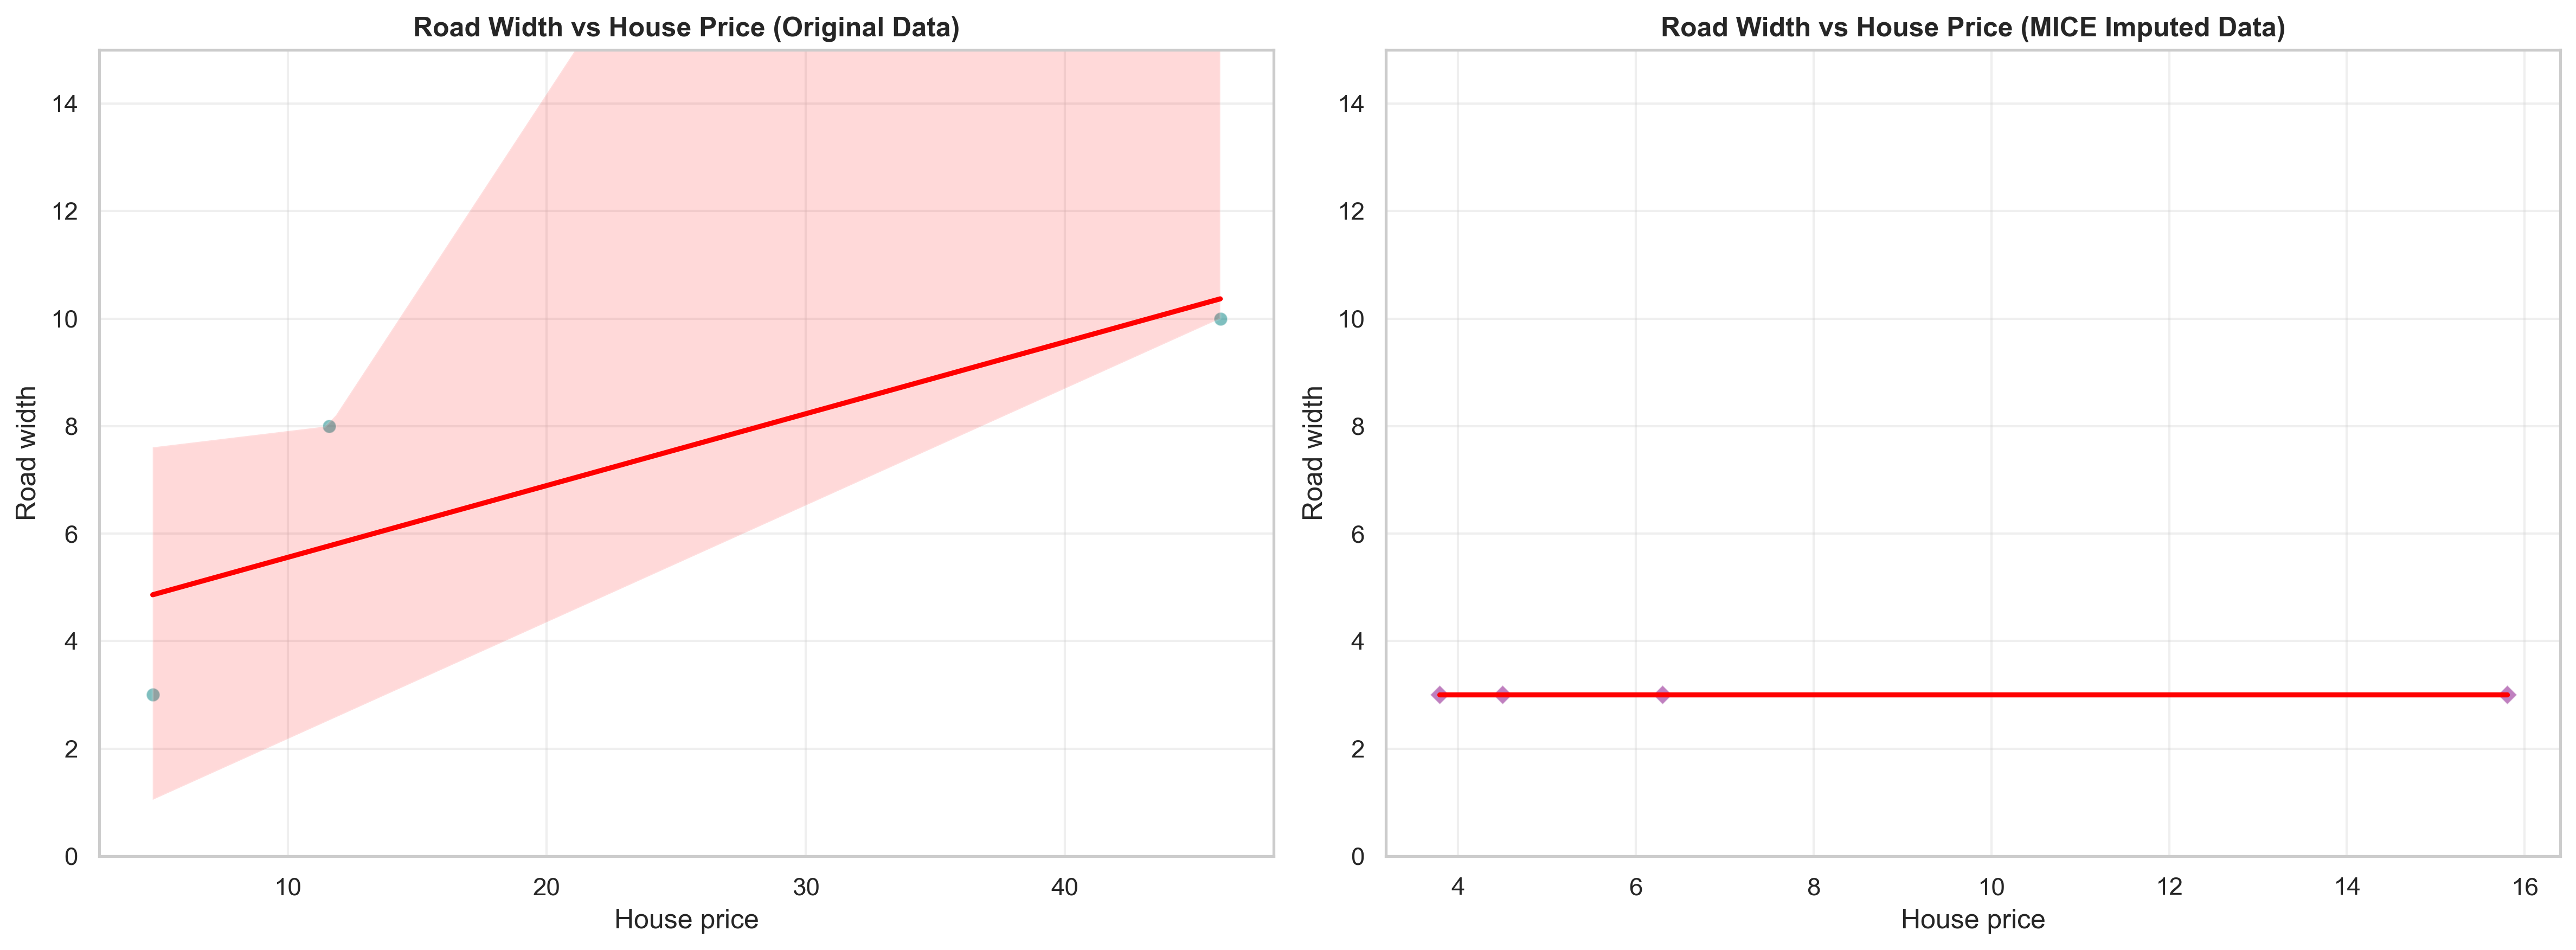

MICE imputer experiment completed successfully.


In [288]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

print("Running MICE imputer experiment...")

X_train_mice = X_train[num_cols].copy()

mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0
)

X_train_mice_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X_train_mice),
    columns=num_cols,
    index=X_train.index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot_mice_imputed = pd.DataFrame({
    'Road width': X_train_mice_imputed.loc[missing_idx, 'Đường vào'],
    'House price': y_train.loc[missing_idx]
})

sns.scatterplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='teal',
    ax=axes[0]
)

sns.regplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[0]
)

axes[0].set_title('Road Width vs House Price (Original Data)', fontweight='bold')
axes[0].set_ylim(0, X_train['Đường vào'].max() + 5)

sns.scatterplot(
    data=df_plot_mice_imputed,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='purple',
    marker='D',
    ax=axes[1]
)

sns.regplot(
    data=df_plot_mice_imputed,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[1]
)

axes[1].set_title('Road Width vs House Price (MICE Imputed Data)', fontweight='bold')
axes[1].set_ylim(0, X_train['Đường vào'].max() + 5)

plt.tight_layout()
plt.show()

print("MICE imputer experiment completed successfully.")


Running MICE imputer experiment...


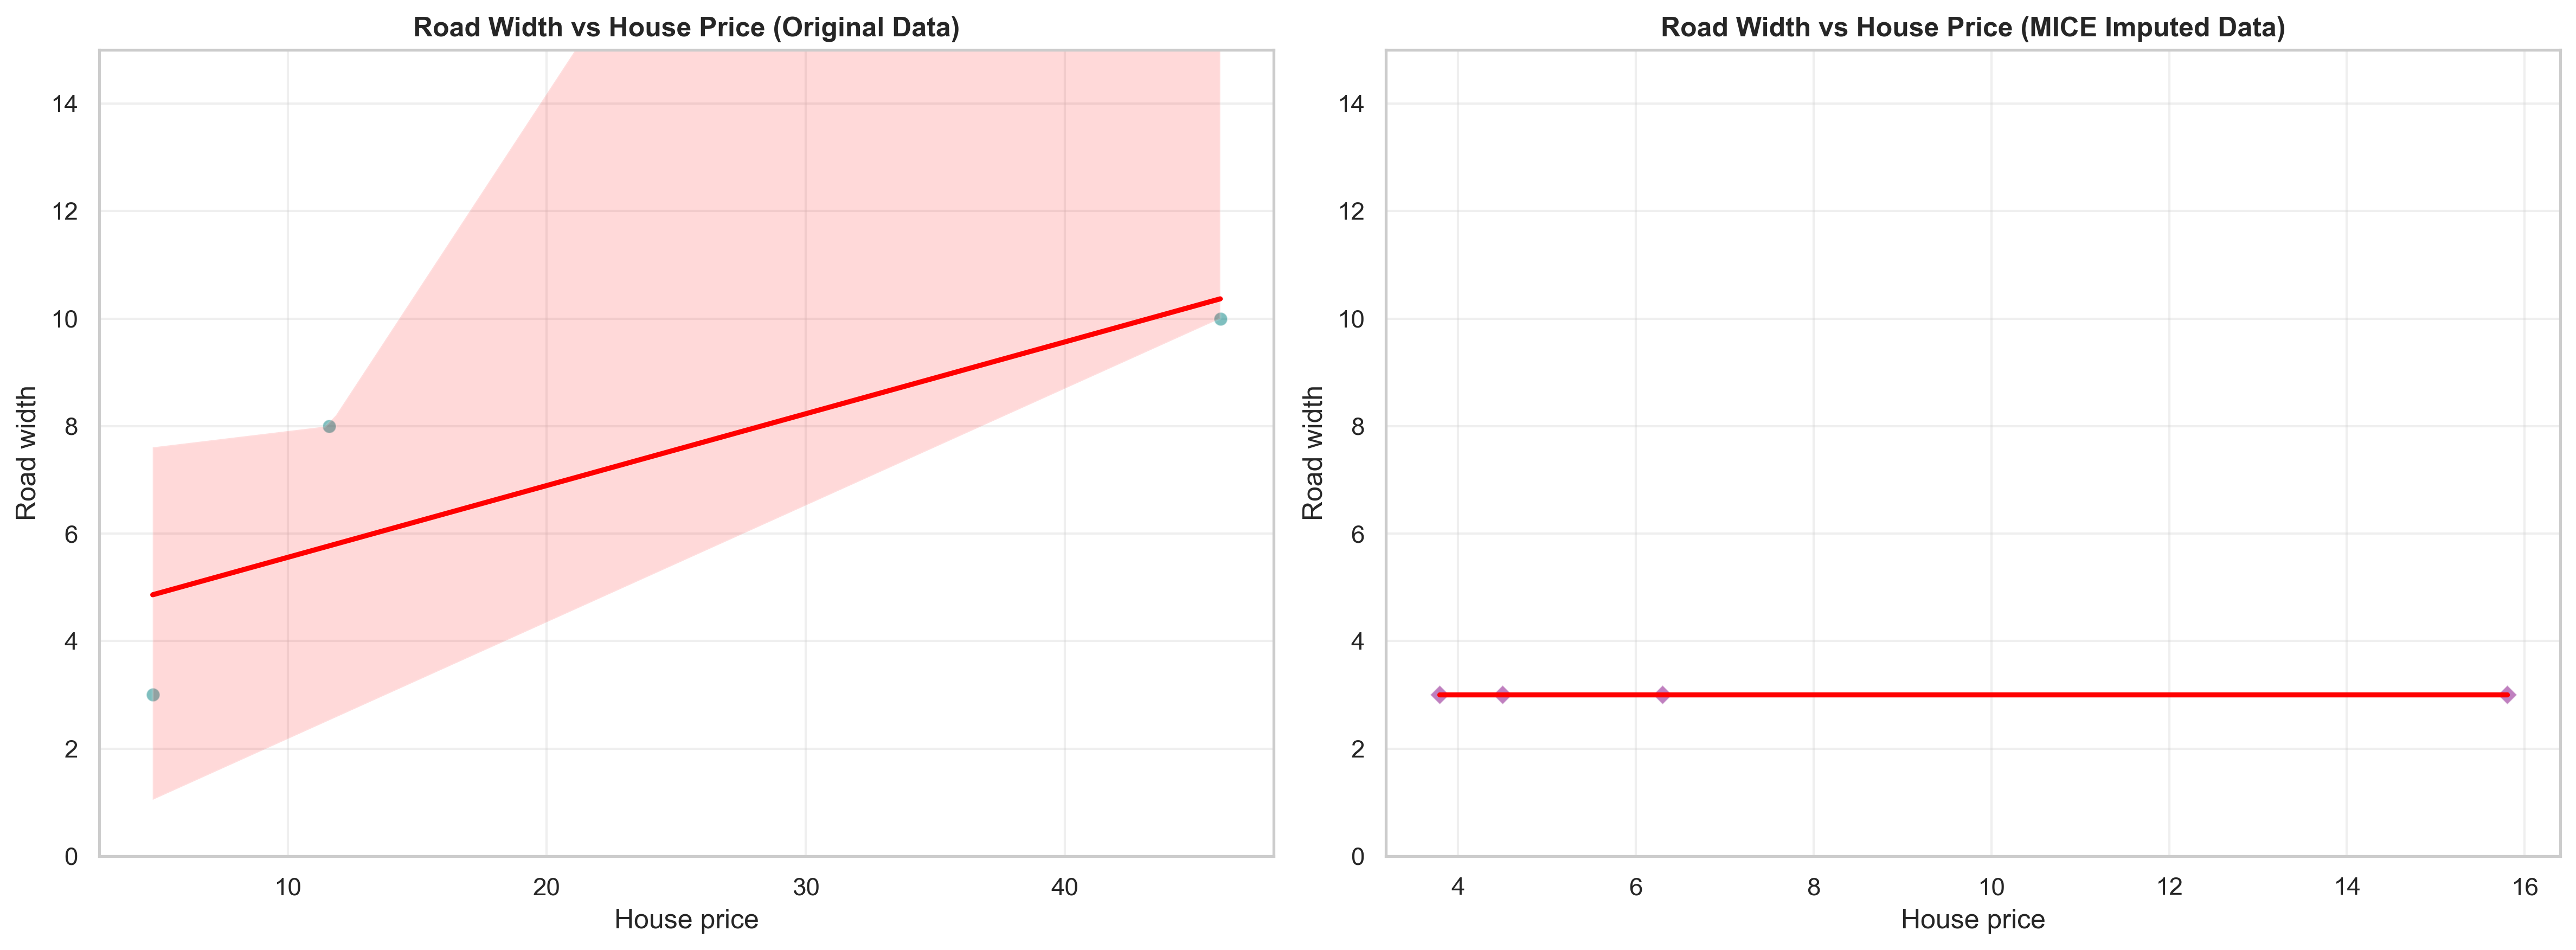

MICE imputer experiment completed successfully.


In [289]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

print("Running MICE imputer experiment...")

X_train_mice = X_train[num_cols].copy()

mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0
)

X_train_mice_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X_train_mice),
    columns=num_cols,
    index=X_train.index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot_mice_imputed = pd.DataFrame({
    'Road width': X_train_mice_imputed.loc[missing_idx, 'Đường vào'],
    'House price': y_train.loc[missing_idx]
})

sns.scatterplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='teal',
    ax=axes[0]
)

sns.regplot(
    data=df_plot_original,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[0]
)

axes[0].set_title('Road Width vs House Price (Original Data)', fontweight='bold')
axes[0].set_ylim(0, X_train['Đường vào'].max() + 5)

sns.scatterplot(
    data=df_plot_mice_imputed,
    x='House price',
    y='Road width',
    alpha=0.5,
    color='purple',
    marker='D',
    ax=axes[1]
)

sns.regplot(
    data=df_plot_mice_imputed,
    x='House price',
    y='Road width',
    scatter=False,
    color='red',
    ax=axes[1]
)

axes[1].set_title('Road Width vs House Price (MICE Imputed Data)', fontweight='bold')
axes[1].set_ylim(0, X_train['Đường vào'].max() + 5)

plt.tight_layout()
plt.show()

print("MICE imputer experiment completed successfully.")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\2791429924.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')


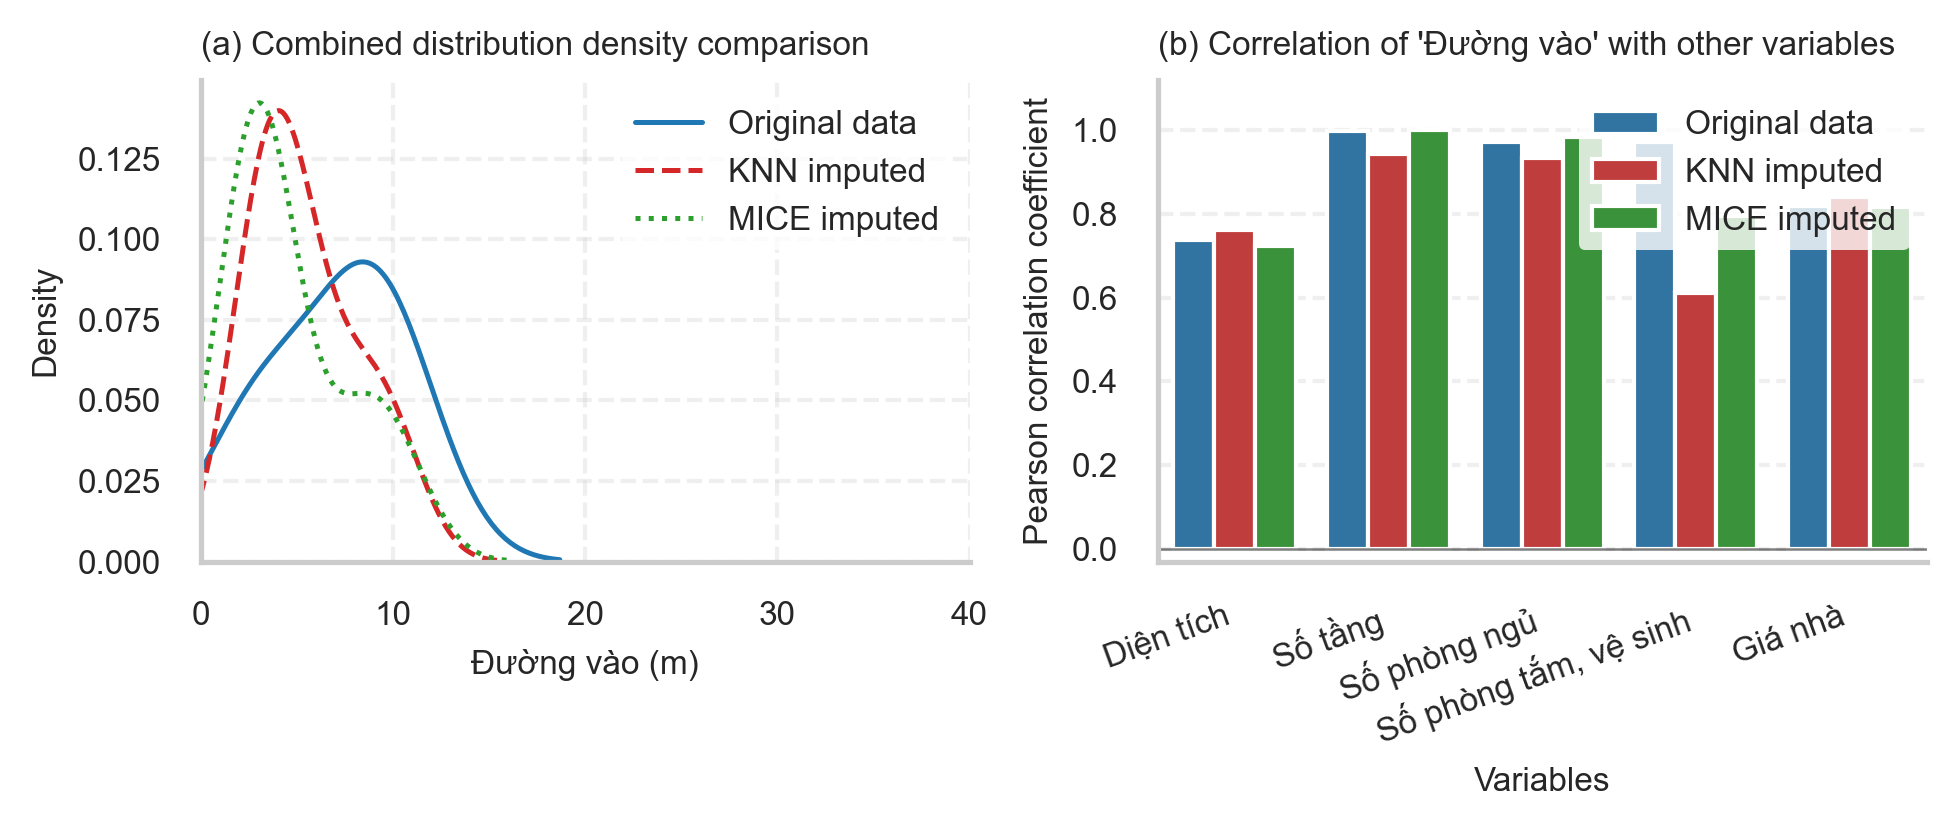

In [290]:

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300
})

sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8))

COLOR_ORIGINAL = '#1f77b4'
COLOR_MEDIAN = '#d62728'
COLOR_TREE = '#2ca02c'
PALETTE = [COLOR_ORIGINAL, COLOR_MEDIAN, COLOR_TREE]

sns.kdeplot(data=X_train['Đường vào'].dropna(), ax=axes[0], label='Original data', color=COLOR_ORIGINAL, linewidth=1.2)
sns.kdeplot(data=X_train_knn_imputed['Đường vào'], ax=axes[0], label='KNN imputed', color=COLOR_MEDIAN, linestyle='--', linewidth=1.2)
sns.kdeplot(data=X_train_mice_imputed['Đường vào'], ax=axes[0], label='MICE imputed', color=COLOR_TREE, linestyle=':', linewidth=1.2)

axes[0].set_title('(a) Combined distribution density comparison', loc='left')
axes[0].set_xlim(0, 40)
axes[0].set_xlabel('Đường vào (m)')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=True, facecolor='white', edgecolor='none')

df_orig = X_train[num_cols].copy()
df_orig['Giá nhà'] = y_train

df_med = X_train_knn_imputed[num_cols].copy()
df_med['Giá nhà'] = y_train

df_tree = X_train_mice_imputed[num_cols].copy()
df_tree['Giá nhà'] = y_train

compare_cols = [col for col in df_orig.columns if col != 'Đường vào']

corr_orig = df_orig.corr()['Đường vào'][compare_cols]
corr_med = df_med.corr()['Đường vào'][compare_cols]
corr_tree = df_tree.corr()['Đường vào'][compare_cols]

corr_summary = pd.DataFrame({
    'Feature': compare_cols,
    'Original data': corr_orig.values,
    'KNN imputed': corr_med.values,
    'MICE imputed': corr_tree.values
})

corr_melted = corr_summary.melt(id_vars='Feature', var_name='Method', value_name='Correlation')

sns.barplot(data=corr_melted, x='Feature', y='Correlation', hue='Method', ax=axes[1], palette=PALETTE)

axes[1].set_title("(b) Correlation of 'Đường vào' with other variables", loc='left')
axes[1].set_xlabel('Variables')
axes[1].set_ylabel('Pearson correlation coefficient')

max_corr = corr_melted['Correlation'].max()
axes[1].set_ylim(-0.03, max_corr + 0.12)
axes[1].axhline(0, color='black', linewidth=0.6, alpha=0.5)
axes[1].legend(title='', frameon=True, facecolor='white', edgecolor='none', loc='upper right')

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig("imputation_comparison_a4_fitted.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [291]:
print("🚀 APPLYING MICE IMPUTATION TO FULL PIPELINE (TRAIN & TEST)...")

# STEP 1: Handle categorical variable
for dataset in [X_train, X_test]:
    if 'Loại đường vào' in dataset.columns:
        dataset['Loại đường vào'] = dataset['Loại đường vào'].fillna('Unknown')

# STEP 2: Create MNAR flag (Missing Not At Random indicator)
# This helps the model capture "information hiding behavior"
for dataset in [X_train, X_test]:
    dataset['duong_vao_null_flag'] = dataset['Đường vào'].isna().astype(int)

# STEP 3: MICE imputation
num_features = ['Diện tích', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Đường vào']

final_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0
)

X_train[num_features] = final_imputer.fit_transform(X_train[num_features])
X_test[num_features] = final_imputer.transform(X_test[num_features])

print("✅ Missing value processing completed without data leakage!")
print(f"   -> Remaining NaN in X_train 'Đường vào': {X_train['Đường vào'].isna().sum()}")
print(f"   -> Remaining NaN in X_test 'Đường vào': {X_test['Đường vào'].isna().sum()}")


🚀 APPLYING MICE IMPUTATION TO FULL PIPELINE (TRAIN & TEST)...
✅ Missing value processing completed without data leakage!
   -> Remaining NaN in X_train 'Đường vào': 0
   -> Remaining NaN in X_test 'Đường vào': 0


## 2.5 Processing properties obtained from Ho Chi Minh City planning website.


### 2.5.1. remove columns that have individual identifiers (no generality for learning) or redundant information: 'So_Lose'; 'So_To'; 'Ten_Do_An'; 'QHPK_Ma_O_Pho'; 'Trang_Thai'.


- So_Lo & So_To (Plot number, Sheet number): Remove. This is like the ID of the plot. They have too large a number of unique values ​​(cardinality) and bring no mathematical rules to the machine learning model. 
- Ten_Do_An: Quit. Project names are often very long and non-standardized text. The nature of the project is expressed through the functional and proportional columns below. 
- QHPK_Ma_O_Pho: Quit. This column contains many missing values ​​and is only for local administrative management, with little impact on the core value of real estate. 
- Trang_Thai: Quit. This column only contains the status of a successful data crawl or API query, it has no intrinsic value about house prices. 

In [292]:
cols_to_drop = ['So_Thua', 'So_To', 'Ten_Do_An', 'QHPK_Ma_O_Pho', 'Trang_Thai']

# Drop columns from both X_train and X_test
# Use errors='ignore' to avoid errors if columns were already removed
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# Print verification results
print("✅ Selected identifier columns have been successfully removed!")
print(f"   -> Remaining number of features in X_train: {X_train.shape[1]}")
print(f"   -> Remaining number of features in X_test : {X_test.shape[1]}")


✅ Selected identifier columns have been successfully removed!
   -> Remaining number of features in X_train: 28
   -> Remaining number of features in X_test : 28


### 2.5.2 Unify 'Quan_Huyen' & 'Phuong_Xa' and 'Address'


Another source of information about administrative boundaries is the address column filled in by the broker. The data collected from the planning website may not be accurate with GPS coordinates but is complete. The broker's data, although accurate, is not complete. The solution is to extract the columns about that administrative boundary from the Address. If the value of any column is missing, the value will be taken from the planning website.

Reasons to use Rule_base instead of LLM: The address column on the website is written according to a fixed template (the problem is just whether there is missing information or not). Using LLM will only cause redundancy and reduce effectiveness.

In [293]:
print(X_train.columns)


Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude',
       'Mô tả', 'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo',
       'QHPK_So_O', 'QHPK_Chuc_Nang', 'QHPK_Dien_Tich', 'QHPK_Ty_Le',
       'QHPK_Ma_QU', 'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi',
       'gan_truong_hoc', 'gan_benh_vien', 'gan_cong_vien_ho_nuoc',
       'duong_vao_null_flag'],
      dtype='object')


In [294]:

print("🚀 STANDARDIZING ADMINISTRATIVE BOUNDARY INFORMATION...")

def parse_address_unified(addr):
    """
    Extract Street, Ward, District from address string.
    Uses boundary anchors (comma or start of string) to avoid mis-parsing street names.
    """
    if pd.isna(addr):
        return pd.Series({
            'Street_mg': np.nan,
            'Ward_mg': np.nan,
            'District_mg': np.nan
        })

    addr_str = str(addr)

    # --- 1. Street ---
    street = np.nan
    m_street = re.search(r'(?:^|,)\s*(Street|Road)\s+([^,]+)', addr_str, re.IGNORECASE)
    if m_street:
        street = m_street.group(1).capitalize() + ' ' + m_street.group(2).strip()

    # --- 2. Ward / Commune ---
    ward = np.nan
    m_ward = re.search(r'(?:^|,)\s*(Ward|Commune|Town)\s+([^,]+)', addr_str, re.IGNORECASE)
    if m_ward:
        ward = m_ward.group(1).capitalize() + ' ' + m_ward.group(2).strip()

    # --- 3. District / City level ---
    district = np.nan
    matches = re.findall(
        r'(?:^|,)\s*(District|County|City|Province|TP\.?)\s+([^,]+)',
        addr_str,
        re.IGNORECASE
    )

    for prefix, name in matches:
        name_clean = name.strip()

        # Skip global city-level duplicates if needed
        if name_clean.lower() not in ['ho chi minh', 'hcm']:
            prefix_clean = prefix.capitalize().replace('Tp.', 'City').replace('Tp', 'City')
            district = f"{prefix_clean} {name_clean}"
            break

    return pd.Series({
        'Street_mg': street,
        'Ward_mg': ward,
        'District_mg': district
    })


# Apply for both train and test (avoid data leakage)
for dataset_name, dataset in [('X_train', X_train), ('X_test', X_test)]:

    extracted = dataset['Địa chỉ'].apply(parse_address_unified)

    dataset['District'] = extracted['District_mg'].fillna(dataset['Quan_Huyen'])
    dataset['Ward'] = extracted['Ward_mg'].fillna(dataset['Phuong_Xa'])
    dataset['Street'] = extracted['Street_mg']

    print(f"✅ Processed administrative boundaries for {dataset_name}.")
    print(f"   -> Missing District values: {dataset['District'].isna().sum()}")
    print(f"   -> Missing Ward values    : {dataset['Ward'].isna().sum()}")


🚀 STANDARDIZING ADMINISTRATIVE BOUNDARY INFORMATION...
✅ Processed administrative boundaries for X_train.
   -> Missing District values: 0
   -> Missing Ward values    : 0
✅ Processed administrative boundaries for X_test.
   -> Missing District values: 0
   -> Missing Ward values    : 0


### 2.5.3 Handle the problem of multiple values ​​in one cell of 'Ty_Le_Dien_Tich_Nha' and 'QHPK_Chuc_Nang'.


Subdivision planning in Vietnam has hundreds of different terms (from residential land, mixed land, park land, isolated green trees, technical infrastructure land, river protection corridors...). If each soil type turns into a column (One-Hot Encoding), the model will suffer from Curse of Dimensionality, extremely sparse data matrix (Sparse) and dilute the prediction algorithm.

To completely solve this problem, we need to apply Domain-driven Aggregation. In Vietnamese real estate, buyers (and models) actually only care about 3 or 4 major impact groups based on the risk level/potential of the land.

In [295]:
from collections import Counter

print("🚀 EXTRACTING ALL PLANNING LAND USE CATEGORIES...")

all_land_types = []

def extract_land_types(text):
    if pd.isna(text):
        return []
    return [item.strip().lower() for item in str(text).split('|') if item.strip()]

for row_val in X_train['QHPK_Chuc_Nang']:
    all_land_types.extend(extract_land_types(row_val))

land_type_counts = Counter(all_land_types)

print(f"✅ Completed! Found {len(land_type_counts)} unique land use categories.\n")
print("📊 LAND USE FREQUENCY TABLE (Descending Order):")
print("-" * 60)
print(f"{'LAND USE TYPE':<45} | {'FREQUENCY'}")
print("-" * 60)

for land_name, count in land_type_counts.most_common():
    print(f"{land_name:<45} | {count}")

print("-" * 60)


🚀 EXTRACTING ALL PLANNING LAND USE CATEGORIES...
✅ Completed! Found 14 unique land use categories.

📊 LAND USE FREQUENCY TABLE (Descending Order):
------------------------------------------------------------
LAND USE TYPE                                 | FREQUENCY
------------------------------------------------------------
đất giao thông                                | 8
đất ở                                         | 2
công trình công cộng hiện hữu                 | 2
đất nhóm nhà ở hiện trạng                     | 1
đất trung tâm y tế                            | 1
đất ở hiện hữu cải tạo chỉnh trang            | 1
khu dân cư hiện hữu chỉnh trang               | 1
đất ở hiện hữu chỉnh trang                    | 1
đất công viên cây xanh - thể dục thể thao     | 1
đất cây xanh công viên - thể dục thể thao     | 1
sông rạch                                     | 1
đất cây xanh cách ly                          | 1
mặt nước                                      | 1
đất ở xây dựng mới     

- Nhóm 1 - Giao thông & Hạ tầng
- Nhóm 2 - Công cộng, Cây xanh & Mặt nước (Không được xây dựng mới / Quy hoạch treo)
- Nhóm 3 - Hỗn hợp, Thương mại & Công nghiệp (Khác)
- Nhóm 4 - Đất Ở (An toàn, giá trị cao)

In [296]:

print("🚀 AGGREGATING AND COMPUTING PLANNING LAND-USE RATIOS...")

def calculate_land_ratios(row):
    transport_area = 0.0
    public_green_area = 0.0
    other_area = 0.0
    residential_area = 0.0

    if pd.isna(row['QHPK_Chuc_Nang']) or pd.isna(row['QHPK_Dien_Tich']):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    list_cn = [str(x).strip().lower() for x in str(row['QHPK_Chuc_Nang']).split('|')]
    list_dt_str = str(row['QHPK_Dien_Tich']).split('|')

    for i in range(min(len(list_cn), len(list_dt_str))):
        cn = list_cn[i]

        try:
            dt = float(list_dt_str[i].strip())
        except ValueError:
            dt = 0.0

        if any(kw in cn for kw in ['transport', 'road', 'road reserve', 'infrastructure', 'bus depot']):
            transport_area += dt

        elif any(kw in cn for kw in [
            'park', 'green', 'water', 'river', 'canal', 'lake',
            'education', 'school', 'hospital', 'healthcare',
            'public', 'administration', 'religion', 'military',
            'sports'
        ]):
            public_green_area += dt

        elif any(kw in cn for kw in [
            'mixed', 'commercial', 'service', 'industrial',
            'warehouse', 'office'
        ]):
            other_area += dt

        elif any(kw in cn for kw in ['residential', 'housing', 'apartment', 'urban']):
            residential_area += dt

        else:
            other_area += dt

    total_area = float(row['Dien_Tich_Lo']) if pd.notna(row['Dien_Tich_Lo']) and float(row['Dien_Tich_Lo']) > 0 else 1.0

    return pd.Series([
        min((transport_area / total_area) * 100, 100.0),
        min((public_green_area / total_area) * 100, 100.0),
        min((other_area / total_area) * 100, 100.0),
        min((residential_area / total_area) * 100, 100.0),
    ])

for dataset_name, dataset in [('X_train', X_train), ('X_test', X_test)]:

    new_cols = [
        'Transport_Ratio',
        'Public_Green_Ratio',
        'Other_Land_Ratio',
        'Residential_Ratio'
    ]

    dataset[new_cols] = dataset.apply(calculate_land_ratios, axis=1)

    dataset.drop(
        columns=['QHPK_Chuc_Nang', 'QHPK_Dien_Tich', 'QHPK_Ty_Le', 'QHPK_Ma_QU', 'QHPK_So_O'],
        inplace=True,
        errors='ignore'
    )

    print(f"✅ Completed land-use ratio engineering for {dataset_name}.")

print("\n👀 SAMPLE OUTPUT:")
display(X_train[['Dien_Tich_Lo',
                 'Transport_Ratio',
                 'Public_Green_Ratio',
                 'Other_Land_Ratio',
                 'Residential_Ratio']].head())


🚀 AGGREGATING AND COMPUTING PLANNING LAND-USE RATIOS...
✅ Completed land-use ratio engineering for X_train.
✅ Completed land-use ratio engineering for X_test.

👀 SAMPLE OUTPUT:


,Dien_Tich_Lo,Transport_Ratio,Public_Green_Ratio,Other_Land_Ratio,Residential_Ratio
5,1378.7,0.0,0.0,100.000000,0.0
0,112.7,0.0,0.0,100.000000,0.0
8,410.1,0.0,0.0,100.000000,0.0
2,3286.7,0.0,0.0,100.000000,0.0
4,255.0,0.0,0.0,99.984314,0.0


In [297]:

print("🚀 RE-CALCULATING FULL MISSING VALUE REPORT...\n")

def missing_value_report(df, dataset_name):
    """
    Compute count and percentage of missing values in a DataFrame.
    Only display columns that contain missing values.
    """

    missing_count = df.isnull().sum()
    missing_pct = df.isnull().mean() * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing Percentage (%)': missing_pct
    })

    missing_df = missing_df[missing_df['Missing Count'] > 0] \
        .sort_values(by='Missing Count', ascending=False)

    print(f"📊 MISSING VALUE REPORT: {dataset_name}")
    print("-" * 50)

    if missing_df.empty:
        print("✅ No missing values found in this dataset.")
    else:
        print(missing_df.round(2).to_string())

    print("=" * 50 + "\n")


missing_value_report(X_train, "X_TRAIN")
missing_value_report(X_test, "X_TEST")


🚀 RE-CALCULATING FULL MISSING VALUE REPORT...

📊 MISSING VALUE REPORT: X_TRAIN
--------------------------------------------------
        Missing Count  Missing Percentage (%)
Street              7                   100.0

📊 MISSING VALUE REPORT: X_TEST
--------------------------------------------------
        Missing Count  Missing Percentage (%)
Street              2                   100.0



Initializing MAR verification analysis and plotting (IEEE format)...


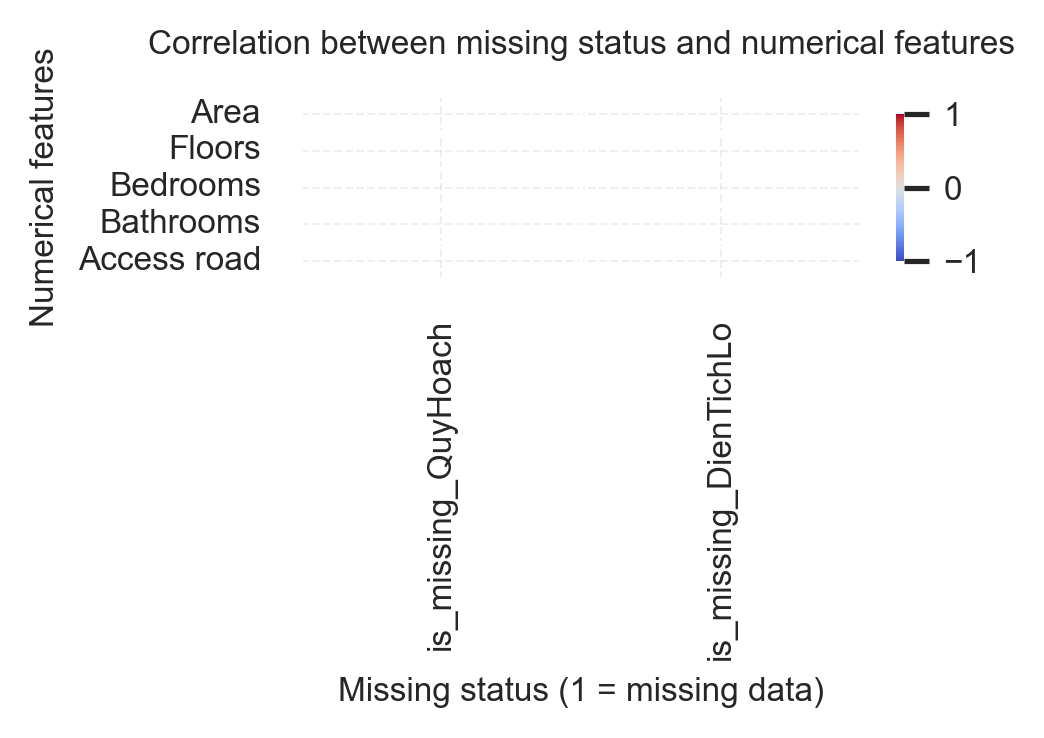

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\2645446371.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


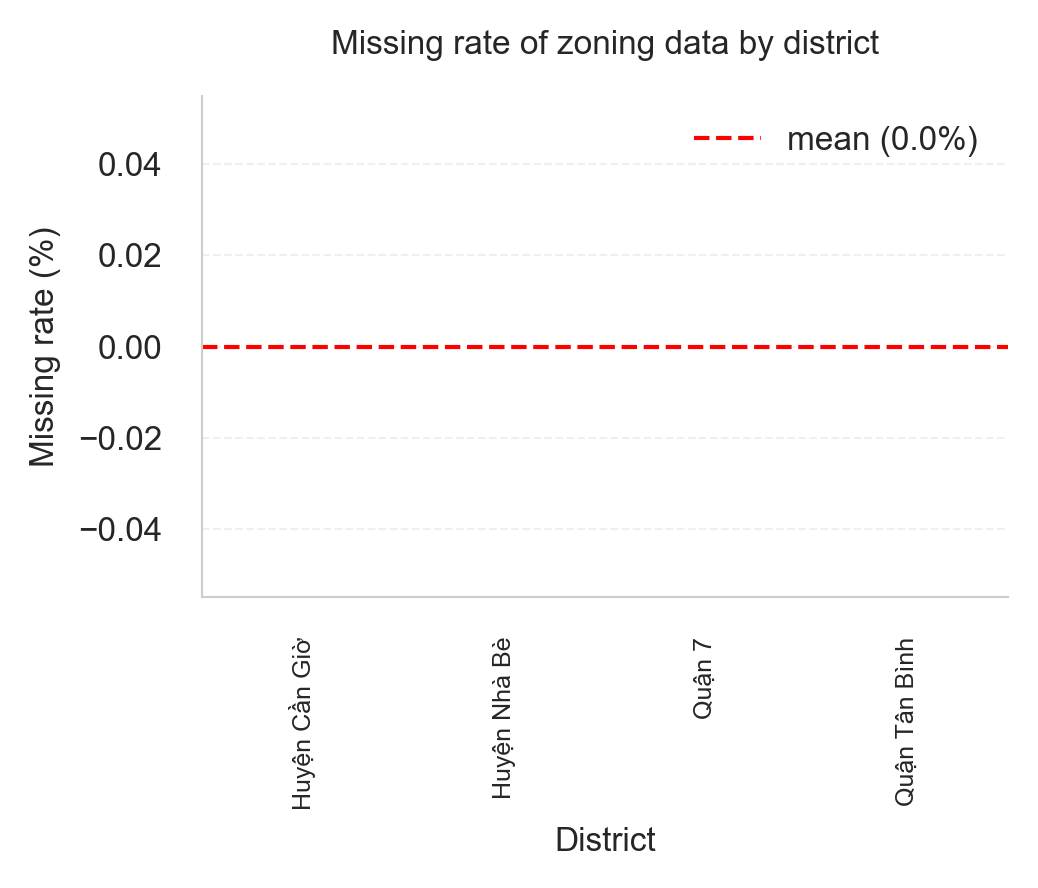

Completed IEEE MAR charts generation.


In [298]:

print("Initializing MAR verification analysis and plotting (IEEE format)...")

IEEE_COLUMN_WIDTH = 3.5

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'axes.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.color': '#e0e0e0'
})

sns.set_style("whitegrid", {'grid.linestyle': '--'})

df_eda = X_train.copy()

df_eda['is_missing_QuyHoach'] = df_eda['Dien_Tich_Lo'].isna().astype(int)
df_eda['is_missing_DienTichLo'] = df_eda['Dien_Tich_Lo'].isna().astype(int)

num_features = ['Diện tích', 'Số tầng', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Đường vào']
flag_cols = ['is_missing_QuyHoach', 'is_missing_DienTichLo']

corr_matrix = df_eda[num_features + flag_cols].corr().loc[num_features, flag_cols]

fig1, ax1 = plt.subplots(figsize=(IEEE_COLUMN_WIDTH, 2.5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 7},
    ax=ax1,
    cbar_kws={'shrink': 0.8}
)

ax1.set_title('Correlation between missing status and numerical features', pad=10)
ax1.set_ylabel('Numerical features')
ax1.set_xlabel('Missing status (1 = missing data)')
ax1.set_xticklabels(['is_missing_QuyHoach', 'is_missing_DienTichLo'])
ax1.set_yticklabels(['Area', 'Floors', 'Bedrooms', 'Bathrooms', 'Access road'], rotation=0)

plt.tight_layout()
plt.show()

if 'Quan_Huyen' in df_eda.columns:
    missing_by_district = df_eda.groupby('Quan_Huyen')['is_missing_QuyHoach'].mean() * 100
    missing_by_district = missing_by_district.sort_values(ascending=False)

    fig2, ax2 = plt.subplots(figsize=(IEEE_COLUMN_WIDTH, 3.0))

    sns.barplot(
        x=missing_by_district.index,
        y=missing_by_district.values,
        palette='viridis',
        ax=ax2
    )

    plt.xticks(rotation=90, fontsize=6)

    ax2.set_title('Missing rate of zoning data by district', pad=10)
    ax2.set_xlabel('District')
    ax2.set_ylabel('Missing rate (%)')

    mean_missing = df_eda['is_missing_QuyHoach'].mean() * 100
    ax2.axhline(
        y=mean_missing,
        color='red',
        linestyle='--',
        linewidth=1.0,
        label=f'mean ({mean_missing:.1f}%)'
    )

    ax2.legend(loc='upper right', frameon=False)
    sns.despine(ax=ax2)

    plt.tight_layout()
    plt.show()
else:
    print("District column not found in dataset.")

print("Completed IEEE MAR charts generation.")


Calculating and plotting geographical distribution (IEEE format)...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\3849934543.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


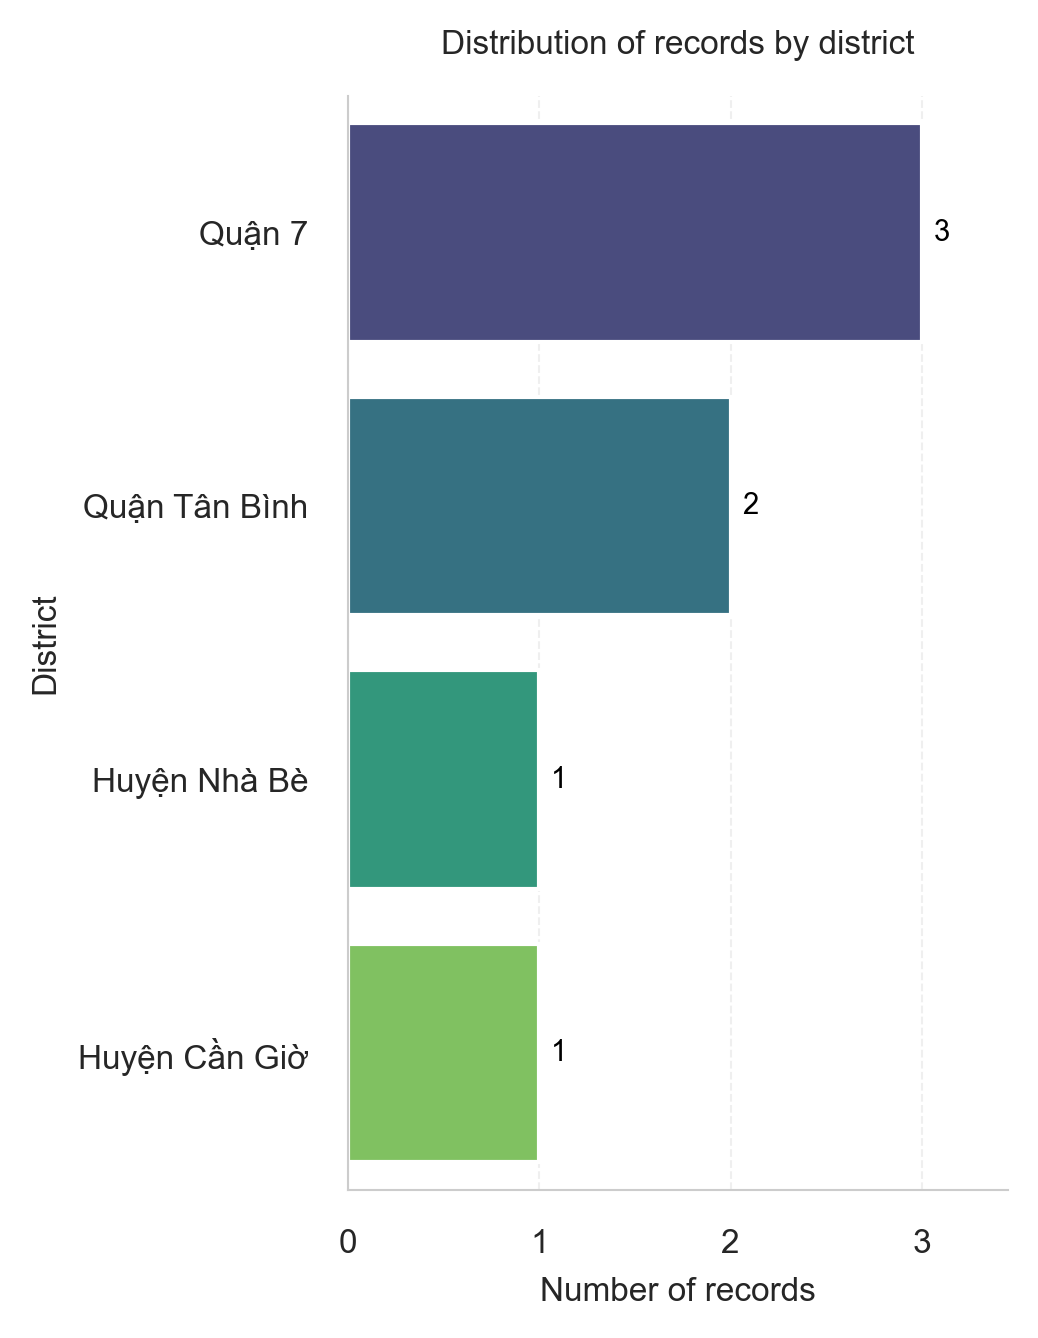

Top 5 districts with highest number of records:
Top 1: Quận 7               ->     3 records (42.9%)
Top 2: Quận Tân Bình        ->     2 records (28.6%)
Top 3: Huyện Nhà Bè         ->     1 records (14.3%)
Top 4: Huyện Cần Giờ        ->     1 records (14.3%)


In [299]:

print("Calculating and plotting geographical distribution (IEEE format)...")

IEEE_COLUMN_WIDTH = 3.5
IEEE_FIGURE_HEIGHT = 4.5

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'axes.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.color': '#e0e0e0'
})

sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.axisbelow': True})

fig, ax = plt.subplots(figsize=(IEEE_COLUMN_WIDTH, IEEE_FIGURE_HEIGHT))

district_counts = X_train['Quan_Huyen'].value_counts(dropna=False)

sns.barplot(
    x=district_counts.values,
    y=district_counts.index.astype(str),
    palette="viridis",
    ax=ax
)

max_val = max(district_counts.values)

for i, v in enumerate(district_counts.values):
    ax.text(v + (max_val * 0.02), i, f"{v:,}", va='center', fontsize=7, color='black')

ax.set_title('Distribution of records by district', pad=10)
ax.set_xlabel('Number of records')
ax.set_ylabel('District')

ax.set_xlim(0, max_val * 1.15)
ax.yaxis.grid(False)

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print("Top 5 districts with highest number of records:")
for rank, (district, count) in enumerate(district_counts.head(5).items(), 1):
    pct = (count / len(X_train)) * 100
    print(f"Top {rank}: {str(district):<20} -> {count:>5,} records ({pct:.1f}%)")


Insight:
-The MAR hypothesis is 100% confirmed (Central -Peripheral Differentiation)
    -Core central districts (Districts 1, 3, 4, 5, 10, Phu Nhuan, Binh Thanh...) have a shortage rate of almost 0%.
    -In contrast, the suburban districts (Can Gio, Cu Chi, Binh Chanh, Hoc Mon) have very high shortage rates (from 30% to 90%).
    -This accurately reflects the state's current state of digitizing cadastral data: The center does it first, the suburbs do it later or are updating.
-"Thu Duc City" incident
    -Chart number 2 shows that District 2, District 9 and Thu Duc City have a shortage rate reaching 100%.
    -In reality: District 2 and District 9 have now been merged into the City. Thu Duc.
-Technically: The loss of 100% of data in this area proves that the government's planning lookup API may have changed the separate endpoint for the Thu Duc area after the merger, or the GIS map of this area is locked.
    -Combined with the distribution chart of the number of records by district (Thu Duc City, District 2, District 9 combined has more than 600 records), the loss of planning information in this cluster is a huge flaw for the model.
-Extreme data imbalance (Data Imbalance) between districts.
-It is reasonable to use an Imputer (like MICE) to fill in the gaps for suburban districts. However, with the District 2/District 9/Thu Duc cluster lacking 100% of planning data, MICE will have no facilities in that area to study.

The imbalance problem will be solved by turning to tree models like CatBoost.

Initializing multivariate correlation analysis and baseline distributions (IEEE format)...


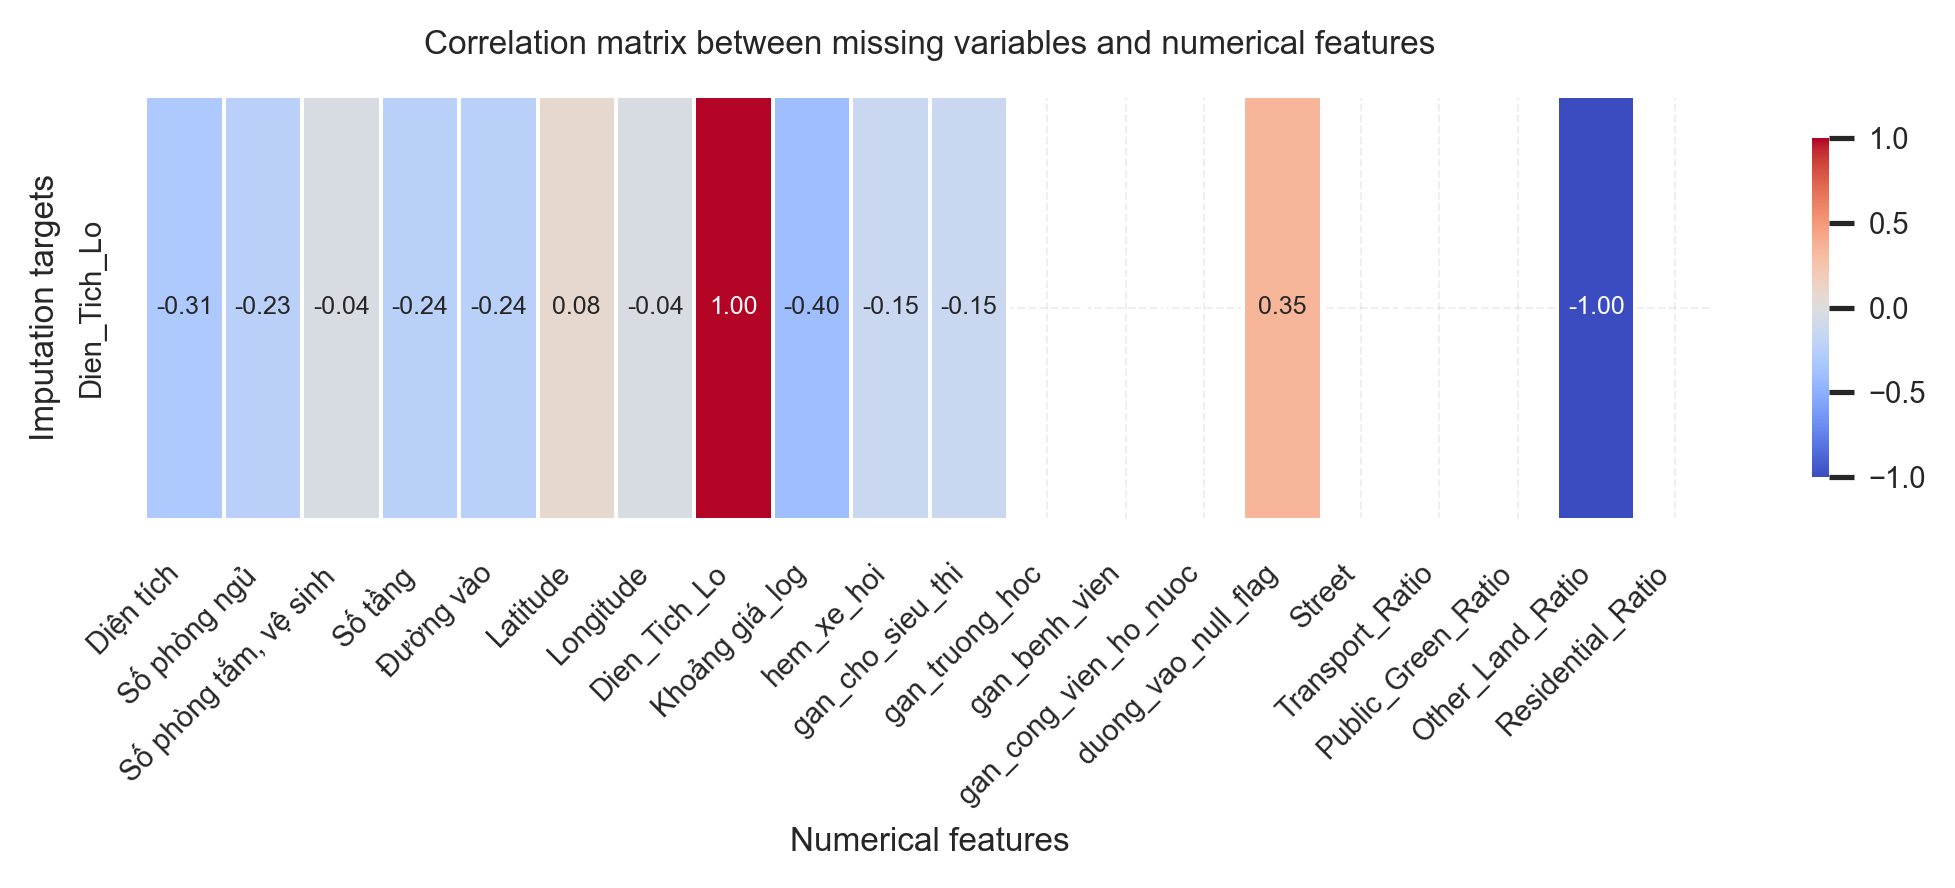

Plotting baseline distributions...


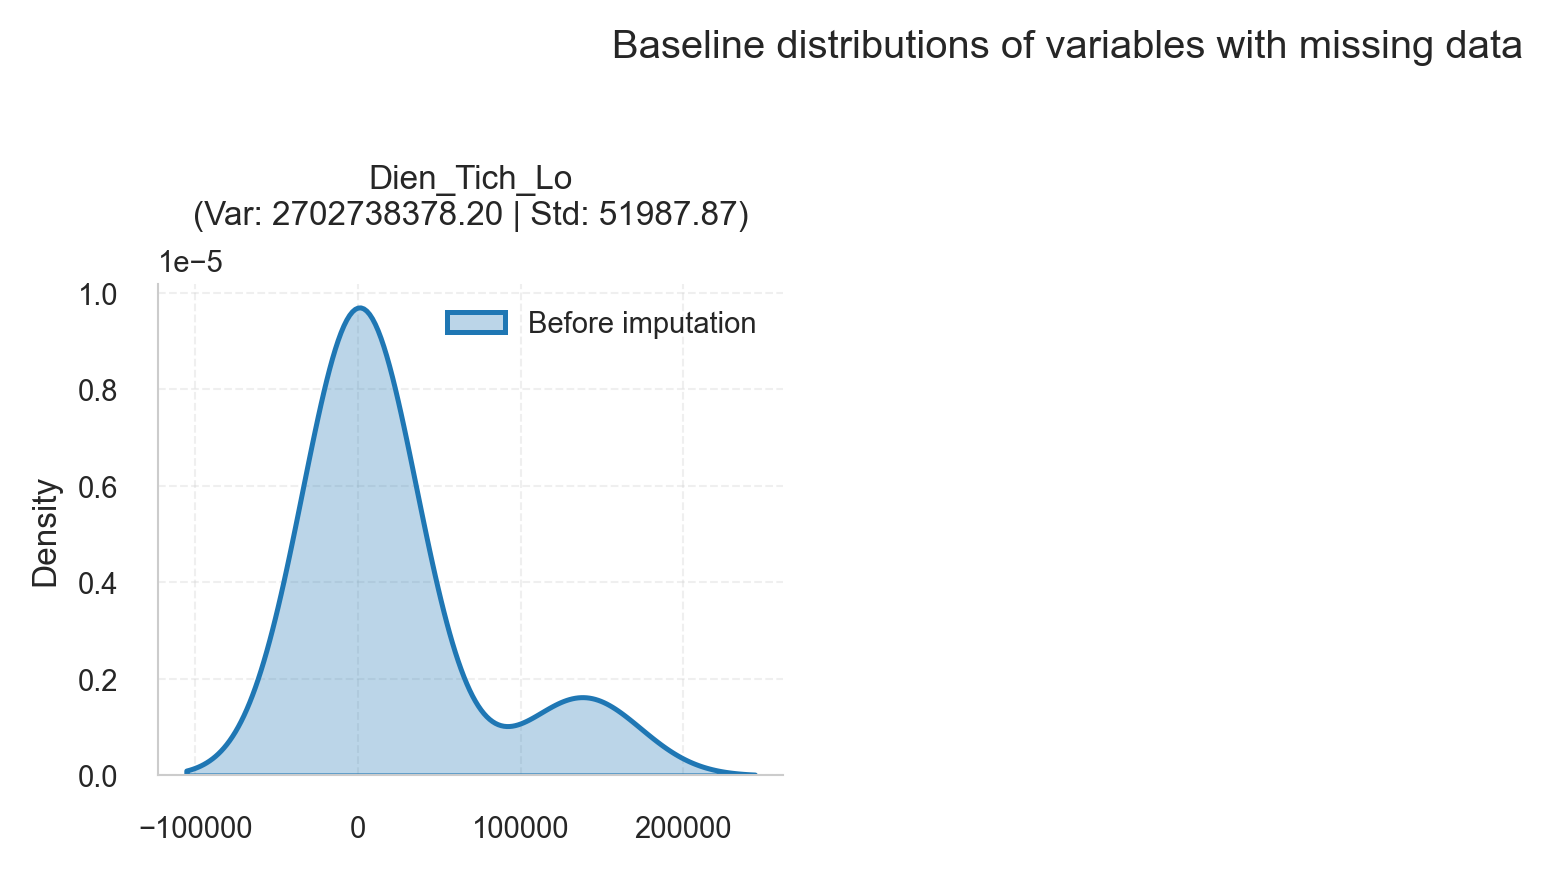

Successfully generated correlation and distribution analysis.


In [300]:

print("Initializing multivariate correlation analysis and baseline distributions (IEEE format)...")

IEEE_DOUBLE_COLUMN_WIDTH = 7.16

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'axes.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.color': '#e0e0e0'
})

sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.axisbelow': True})

missing_target_cols = [
    'Dien_Tich_Lo'
]

if missing_target_cols:
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    fig1, ax1 = plt.subplots(figsize=(IEEE_DOUBLE_COLUMN_WIDTH, 3.0))

    corr_matrix = X_train[numeric_cols].corr()
    corr_with_missing = corr_matrix.loc[missing_target_cols, :]

    sns.heatmap(
        corr_with_missing,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=0.5,
        vmin=-1,
        vmax=1,
        annot_kws={"size": 6},
        ax=ax1,
        cbar_kws={'shrink': 0.8}
    )

    ax1.set_title('Correlation matrix between missing variables and numerical features', pad=10)
ax1.set_xlabel('Numerical features')
ax1.set_ylabel('Imputation targets')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Plotting baseline distributions...")

fig2, axes = plt.subplots(nrows=2, ncols=3, figsize=(IEEE_DOUBLE_COLUMN_WIDTH, 4.5))
axes = axes.flatten()

for i, col in enumerate(missing_target_cols):
    data_clean = X_train[col].dropna()

    sns.kdeplot(
        data_clean,
        ax=axes[i],
        color='#1f77b4',
        fill=True,
        alpha=0.3,
        linewidth=1.2,
        label='Before imputation'
    )

    var_val = data_clean.var()
    std_val = data_clean.std()

    axes[i].set_title(f'{col}\n(Var: {var_val:.2f} | Std: {std_val:.2f})', pad=6)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')
    axes[i].legend(loc='upper right', frameon=False)

    sns.despine(ax=axes[i])

for j in range(i + 1, len(axes)):
    fig2.delaxes(axes[j])

fig2.suptitle('Baseline distributions of variables with missing data', y=1.02)

plt.tight_layout()
plt.show()

print("Successfully generated correlation and distribution analysis.")


chạy MICE thẳng trên các cột số học hiện tại là chắc chắn thất bại vì tương quan quá thấp.

Initializing spatial boxplot analysis (IEEE double-column format)...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17128\2616136666.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


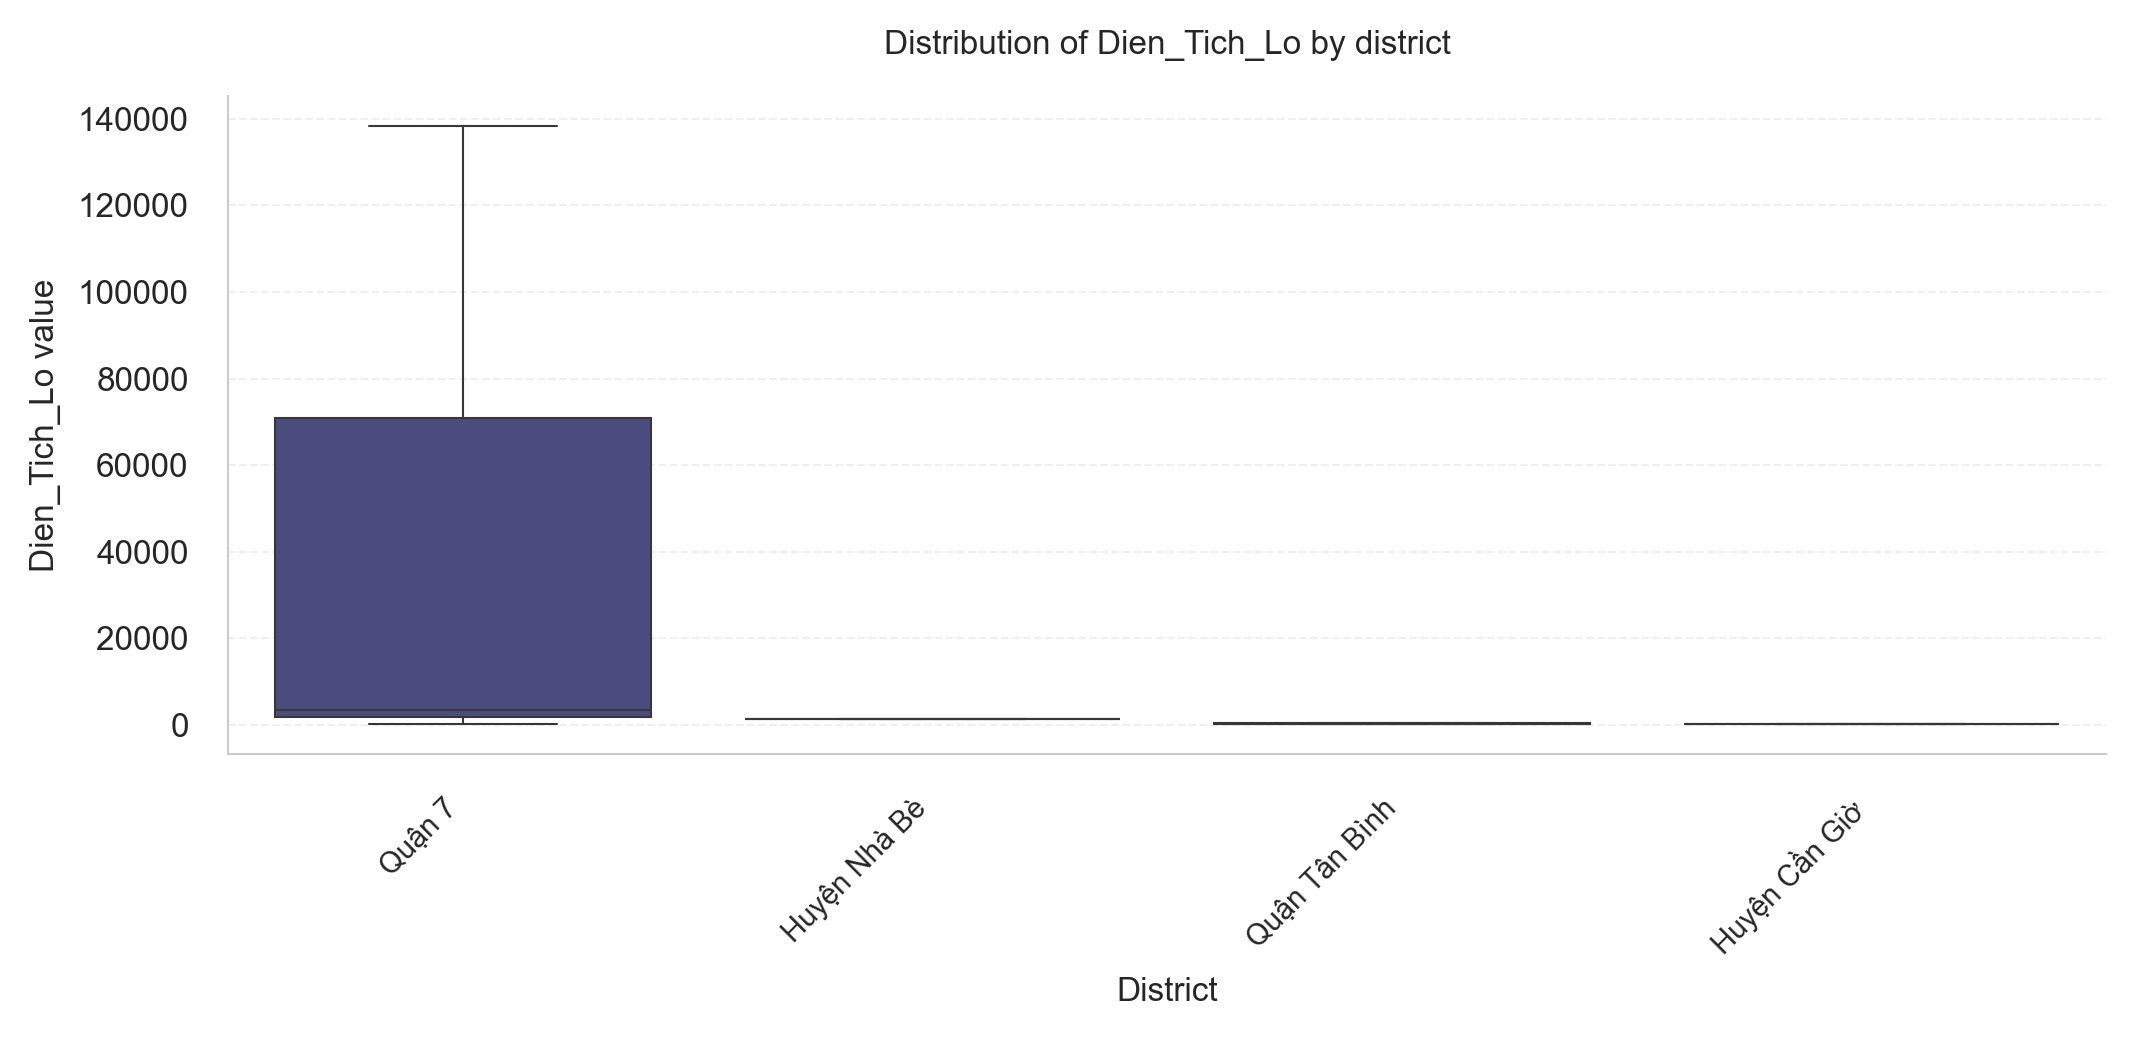

Successfully generated all diagnostic boxplots.


In [301]:

print("Initializing spatial boxplot analysis (IEEE double-column format)...")

missing_target_cols = [
    'Dien_Tich_Lo'
]

IEEE_DOUBLE_COLUMN_WIDTH = 7.16
IEEE_FIGURE_HEIGHT = 3.5

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'axes.edgecolor': 'black',
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'grid.color': '#e0e0e0'
})

if 'Quan_Huyen' in X_train.columns:
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.axisbelow': True})

    for idx, col in enumerate(missing_target_cols):

        if X_train[col].dropna().empty:
            print(f"Variable '{col}' is entirely NaN. Skipping.")
            continue

        fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COLUMN_WIDTH, IEEE_FIGURE_HEIGHT))

        order = X_train.groupby('Quan_Huyen')[col].median().sort_values(ascending=False).index

        sns.boxplot(
            x='Quan_Huyen',
            y=col,
            data=X_train,
            order=order,
            palette='viridis',
            linewidth=0.5,
            fliersize=1.5,
            flierprops={
                'marker': 'o',
                'markeredgewidth': 0.3,
                'markerfacecolor': 'none'
            },
            ax=ax
        )

        ax.set_title(f'Distribution of {col} by district', pad=10)
        ax.set_xlabel('District')
        ax.set_ylabel(f'{col} value')

        ax.tick_params(axis='x', rotation=45, labelsize=7)

        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment('right')

        ax.xaxis.grid(False)
        sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

    print("Successfully generated all diagnostic boxplots.")
else:
    print("Column Quan_Huyen not found in dataset.")


- độ dài của các hộp màu (đại diện cho khoảng phân vị từ 25% đến 75% dữ liệu) và các đường râu (whiskers) quá rộng
- Quận/Huyện có ảnh hưởng đến Tỷ lệ đất ở, nhưng nó không đủ mạnh để đóng đinh một con số cụ thể.
- việc dùng MICE (dù có mã hóa biến Quận/Huyện đi nữa) sẽ ép mô hình dự đoán ra các giá trị trung bình nằm ở giữa hộp
- giữ nguyên giá trị NaN và sử dụng các thuật toán dạng Cây quyết định (Tree-based) tiên tiến như XGBoost hoặc LightGBM — những thuật toán sinh ra để tự động phân luồng và không bị ảnh hưởng với dữ liệu khuyết thiếu.

Điền các gía trị khuyết thiếu thành một nhãn riêng là unknown.

In [302]:

print("Initializing unified missing value handling for categorical variables...")

clean_target_cols = ['Quan_Huyen', 'Phuong_Xa', 'Đường_Từ_Địa_Chỉ']

for name, dataset in [('X_train', X_train), ('X_test', X_test)]:
    print(f"\nCleaning missing values on dataset: {name}")

    for col in clean_target_cols:
        if col in dataset.columns:

            missing_before = dataset[col].isna().sum()

            dataset[col] = dataset[col].fillna('Unknown')

            missing_after = dataset[col].isna().sum()

            print(f"Feature [{col}]: {missing_before} missing -> {missing_after} remaining")

        else:
            print(f"Warning: Feature [{col}] not found in {name}.")

print("\nCompleted unified cleaning step.")
print("All missing categorical geospatial values have been replaced with 'Unknown'.")


Initializing unified missing value handling for categorical variables...

Cleaning missing values on dataset: X_train
Feature [Quan_Huyen]: 0 missing -> 0 remaining
Feature [Phuong_Xa]: 0 missing -> 0 remaining

Cleaning missing values on dataset: X_test
Feature [Quan_Huyen]: 0 missing -> 0 remaining
Feature [Phuong_Xa]: 0 missing -> 0 remaining

Completed unified cleaning step.
All missing categorical geospatial values have been replaced with 'Unknown'.


## 2.6 Handling latitude and longitude columns.


📊 CHECKING SPATIAL OUTLIERS (LATITUDE & LONGITUDE)...


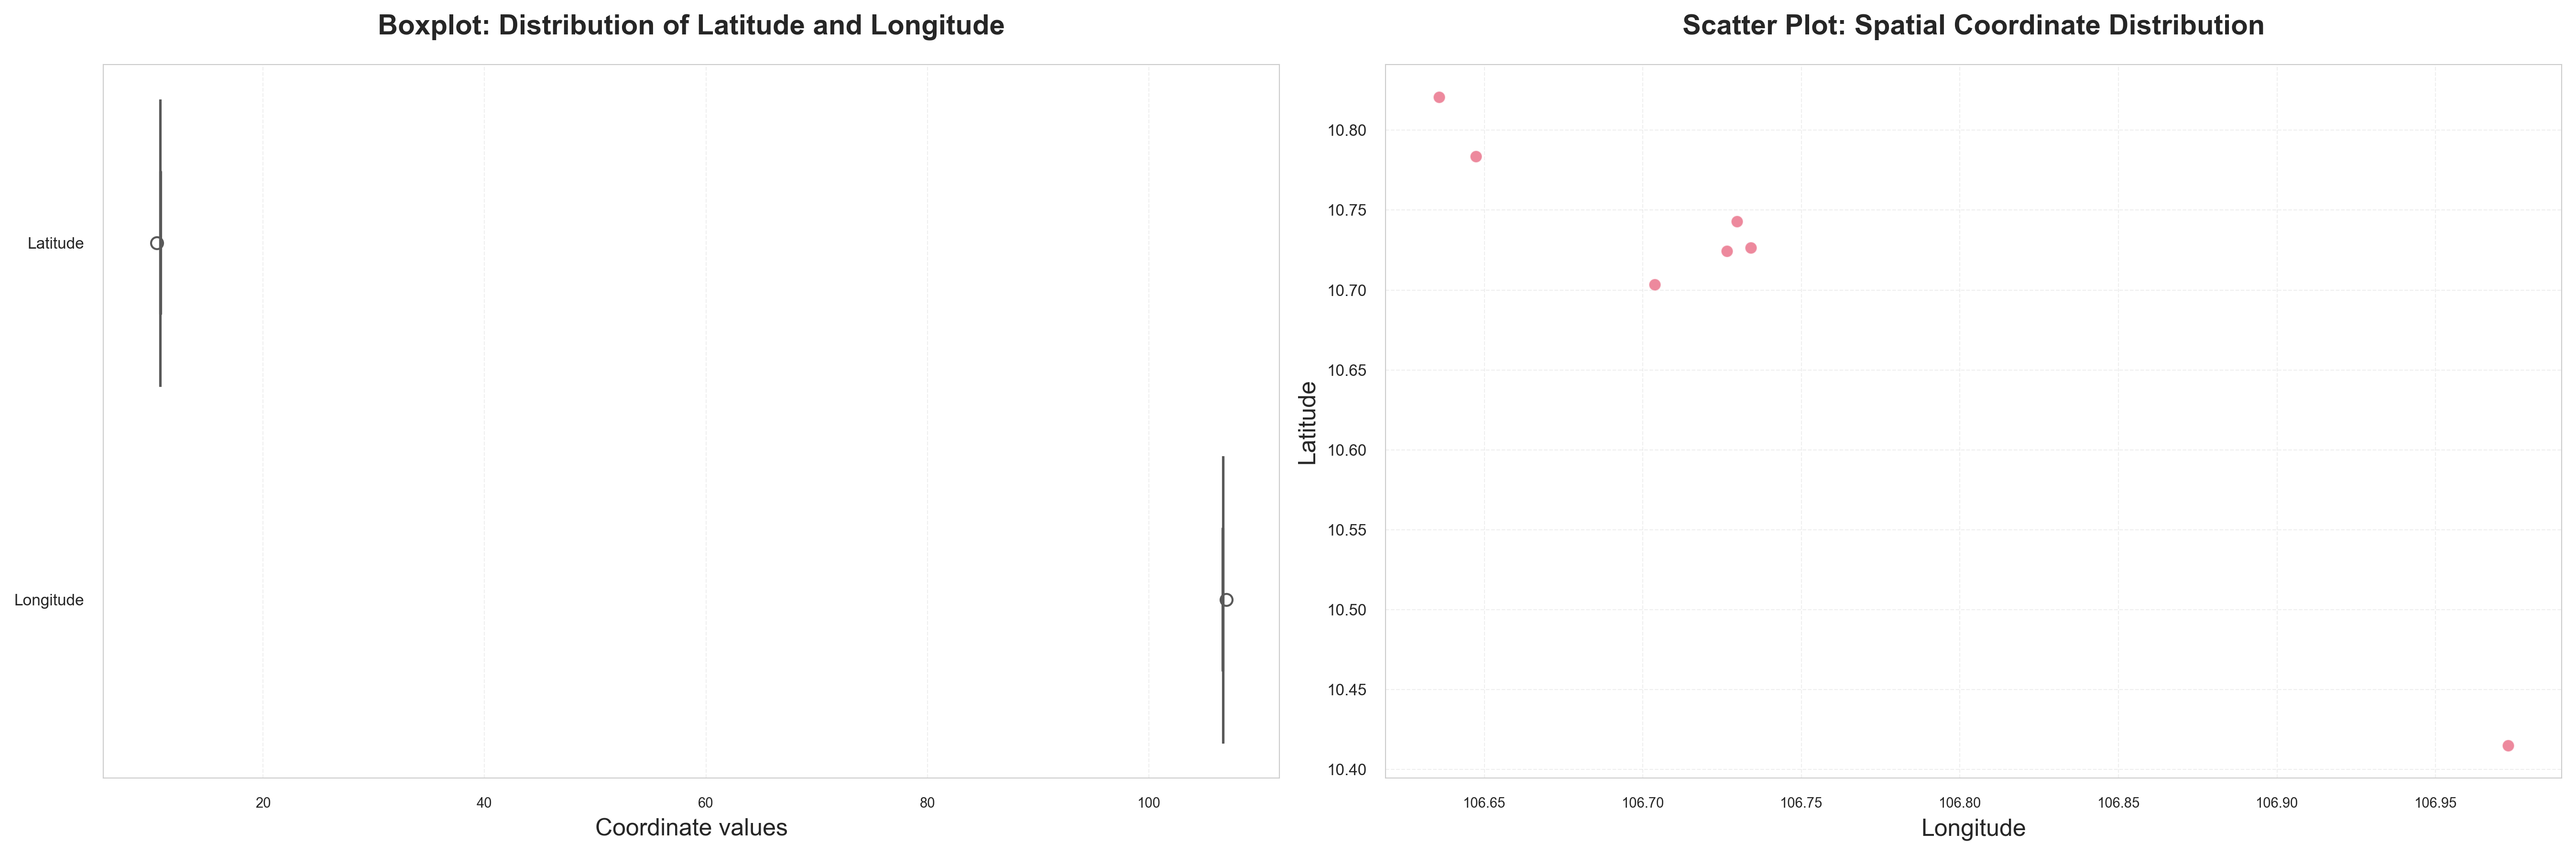

💡 Interpretation guide:
- Boxplot shows statistical outliers (points outside whiskers).
- Scatter plot shows spatial distribution. Ho Chi Minh City data is typically concentrated around latitude ~10–11.5 and longitude ~106–107.5. Points far outside this range may be anomalies.


In [303]:

print("📊 CHECKING SPATIAL OUTLIERS (LATITUDE & LONGITUDE)...")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.boxplot(
    data=X_train[['Latitude', 'Longitude']],
    orient='h',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title(
    'Boxplot: Distribution of Latitude and Longitude',
    fontsize=14,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('Coordinate values', fontsize=12)


sns.scatterplot(
    data=X_train,
    x='Longitude',
    y='Latitude',
    alpha=0.5,
    color='crimson',
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title(
    'Scatter Plot: Spatial Coordinate Distribution',
    fontsize=14,
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)

plt.tight_layout()
plt.show()

print("💡 Interpretation guide:")
print("- Boxplot shows statistical outliers (points outside whiskers).")
print("- Scatter plot shows spatial distribution. Ho Chi Minh City data is typically concentrated around latitude ~10–11.5 and longitude ~106–107.5. Points far outside this range may be anomalies.")


In [304]:

print("🧹 REMOVING SPATIAL OUTLIERS...")

LAT_MIN, LAT_MAX = 10.0, 12.0
LON_MIN, LON_MAX = 105.0, 110.0

def remove_spatial_outliers(X, y=None):
    """
    Filter coordinate outliers and optionally align target variable.
    """
    valid_mask = (
        (X['Latitude'] >= LAT_MIN) & (X['Latitude'] <= LAT_MAX) &
        (X['Longitude'] >= LON_MIN) & (X['Longitude'] <= LON_MAX)
    )

    outliers_count = (~valid_mask).sum()

    X_clean = X[valid_mask].copy()

    if y is not None:
        y_clean = y[valid_mask].copy()
        return X_clean, y_clean, outliers_count

    return X_clean, None, outliers_count


try:
    X_train, y_train, train_outliers = remove_spatial_outliers(X_train, y_train)
    print(f" TRAIN: Removed {train_outliers} outlier rows.")
    print(f"   -> X_train shape: {X_train.shape}")
except NameError:
    print("⚠️ Warning: y_train not found. Skipping train alignment.")


try:
    X_test, y_test, test_outliers = remove_spatial_outliers(X_test, y_test)
    print(f" TEST: Removed {test_outliers} outlier rows.")
    print(f"   -> X_test shape: {X_test.shape}")
except NameError:
    print("⚠️ Warning: y_test not found. Filtering X_test only.")
    X_test, _, test_outliers = remove_spatial_outliers(X_test)
    print(f" TEST: Removed {test_outliers} outlier rows.")

print("\n SPATIAL CLEANING COMPLETED!")


🧹 REMOVING SPATIAL OUTLIERS...
 TRAIN: Removed 0 outlier rows.
   -> X_train shape: (7, 30)
 TEST: Removed 0 outlier rows.
   -> X_test shape: (2, 30)

 SPATIAL CLEANING COMPLETED!


# 3.Feature Extraction/Engineering

In [305]:
'''
X_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_train_processed.csv')
y_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_train_processed.csv')
X_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_test_processed.csv')
y_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_test_processed.csv')
'''


"\nX_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_train_processed.csv')\ny_train = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_train_processed.csv')\nX_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/X_test_processed.csv')\ny_test = pd.read_csv('/Users/doanlong/Documents/Môn học/Thu thập và Tiền xử lý dữ liệu/house_price_project/y_test_processed.csv')\n"

## 3.1 Use LLM Qwen7B to extract additional useful features in the description column.


Initialize the model

In [306]:
from openai import OpenAI
import json
from tqdm import tqdm

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)

utility_features = [
    "alley_accessible",
    "near_supermarket",
    "near_school",
    "near_hospital",
    "near_park_or_lake"
]

print("Client configured successfully. Ready for feature extraction.")


Client configured successfully. Ready for feature extraction.


In [307]:
def extract_features_pipeline(df_input, text_column="Mô tả"):
    df_res = df_input.copy()

    for col in utility_features:
        df_res[col] = 0

    print(f"Processing column '{text_column}' (rows: {len(df_res)})...")

    for index, row in tqdm(df_res.iterrows(), total=len(df_res), desc="LLM Processing"):
        description = row[text_column]

        if pd.isna(description) or str(description).strip() == "":
            continue

        prompt = f"""
        Read the following real estate description and determine whether each nearby utility is mentioned.
        Return 1 if mentioned (or semantically equivalent), otherwise return 0.

        STRICT OUTPUT FORMAT (JSON only, no explanation):
        {{
            "alley_accessible": 0,
            "near_supermarket": 0,
            "near_school": 0,
            "near_hospital": 0,
            "near_park_or_lake": 0
        }}

        Description: "{description}"
        """

        try:
            response = client.chat.completions.create(
                model="qwen2.5:7b",
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
                temperature=0.1
            )

            extracted_data = json.loads(response.choices[0].message.content)

            for col in utility_features:
                df_res.at[index, col] = int(extracted_data.get(col, 0))

        except Exception:
            continue

    return df_res

print("Feature extraction pipeline ready.")


Feature extraction pipeline ready.


In [308]:
print("Processing training set...")
X_train = extract_features_pipeline(X_train, text_column="Mô tả")

print("\nProcessing test set...")
X_test = extract_features_pipeline(X_test, text_column="Mô tả")

print("\nSample output (X_train):")
display(X_train[utility_features].tail())


Processing training set...
Processing column 'Mô tả' (rows: 7)...


LLM Processing: 100%|██████████| 7/7 [01:36<00:00, 13.82s/it]



Processing test set...
Processing column 'Mô tả' (rows: 2)...


LLM Processing: 100%|██████████| 2/2 [00:27<00:00, 13.59s/it]


Sample output (X_train):


,alley_accessible,near_supermarket,near_school,near_hospital,near_park_or_lake
8,0,0,0,0,0
2,0,0,0,0,0
4,0,0,0,0,0
3,0,0,0,0,0
6,0,0,0,0,0


## 3.2 Create the interaction variable 'Total number of rooms'.


Identify multicollinearity using correlation matrix.

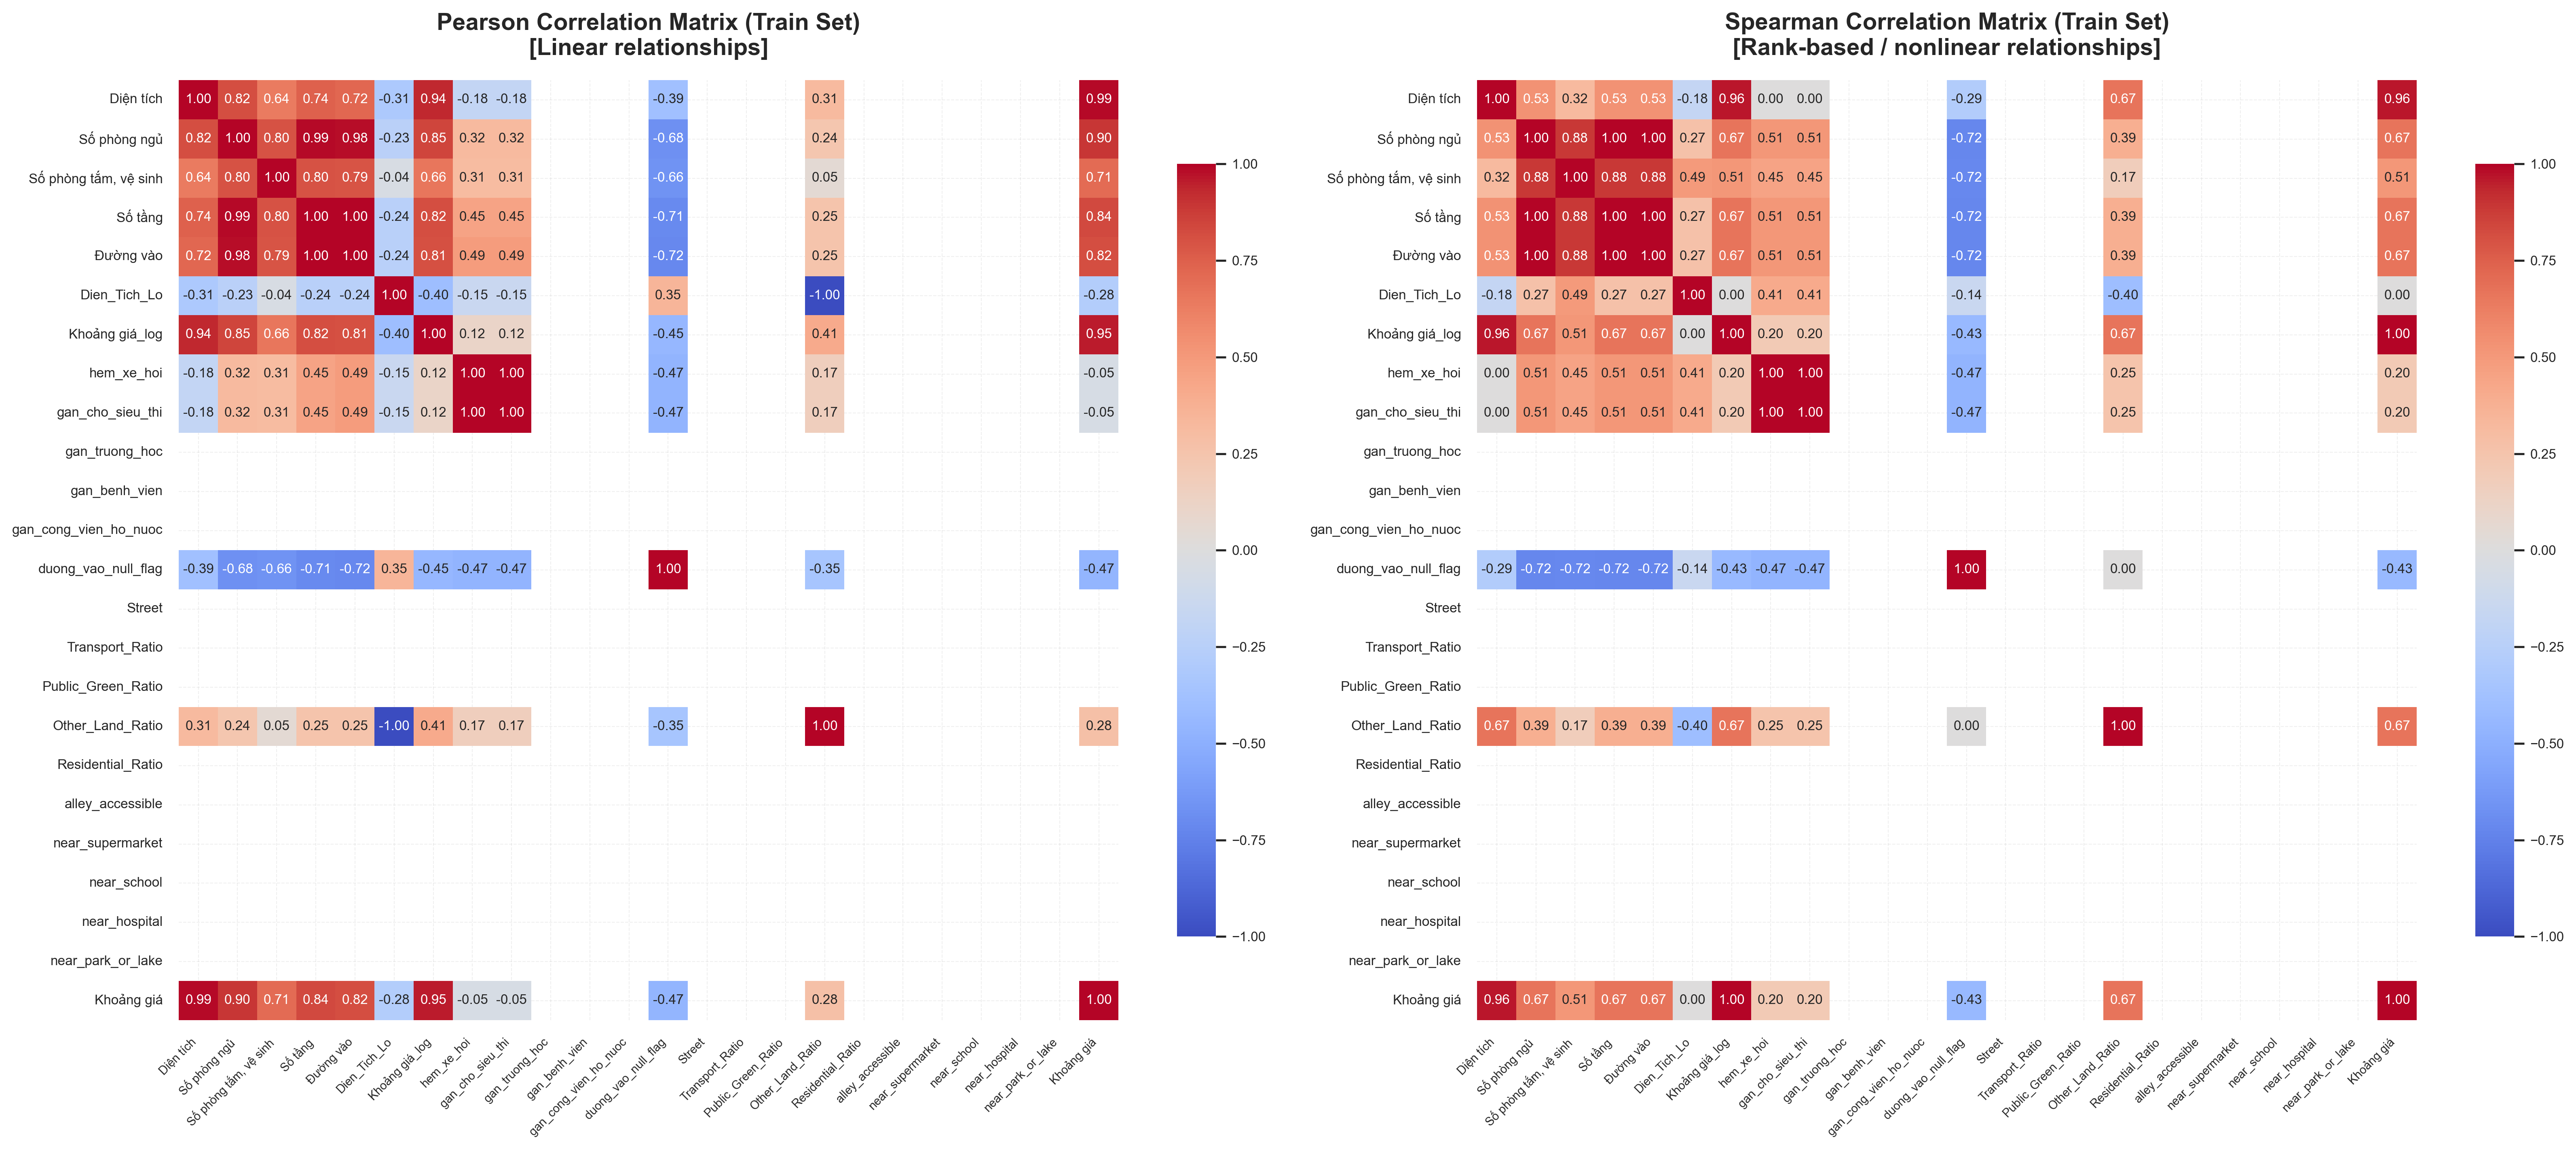

In [309]:

train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.drop(columns=['Longitude', 'Latitude', 'price_log'], errors='ignore')

train_numeric = train_data.select_dtypes(include=[np.number])

pearson_corr = train_numeric.corr(method='pearson')
spearman_corr = train_numeric.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    ax=axes[0],
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title(
    "Pearson Correlation Matrix (Train Set)\n[Linear relationships]",
    fontsize=14,
    fontweight="bold",
    pad=15
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    ax=axes[1],
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title(
    "Spearman Correlation Matrix (Train Set)\n[Rank-based / nonlinear relationships]",
    fontsize=14,
    fontweight="bold",
    pad=15
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


Detected heavy multicollinearity in the columns 'Number of bedrooms' and 'Number of bathrooms and toilets'. These 2 columns will be added together to form a new feature, Total number of rooms.

In [310]:

X_train["total_rooms"] = X_train["Số phòng ngủ"] + X_train["Số phòng tắm, vệ sinh"]
X_test["total_rooms"] = X_test["Số phòng ngủ"] + X_test["Số phòng tắm, vệ sinh"]
cols_to_drop = ["Số phòng ngủ", "Số phòng tắm, vệ sinh"]

print("Feature engineering completed: total_rooms created and original columns removed.")


Feature engineering completed: total_rooms created and original columns removed.


## 3.3 Combine longitude and latitude.


In [311]:
import plotly.express as px

train_data_updated = pd.concat([X_train, y_train], axis=1)

df_filtered = train_data_updated.copy()

df_filtered = df_filtered[(df_filtered["Diện tích"] > 0) & (df_filtered["Diện tích"].notna())]
df_filtered = df_filtered.dropna(subset=["Longitude", "Latitude", "Khoảng giá_log"])

hover_cols = ["Diện tích", "Khoảng giá_log"]

if "Số tầng" in df_filtered.columns:
    hover_cols.append("Số tầng")

fig = px.scatter(
    df_filtered,
    x="Longitude",
    y="Latitude",
    color="Khoảng giá_log",
    size="Diện tích",
    hover_data=hover_cols,
    color_discrete_sequence=px.colors.qualitative.Set1,
    title="Spatial distribution of real estate price and area",
    labels={
        "Longitude": "Longitude",
        "Latitude": "Latitude",
    "Khoảng giá_log": "Price range",
        "Diện tích": "Area (m²)"
    }
)

fig.update_layout(
    width=1100,
    height=700,
    hovermode="closest",
    title_x=0.5
)

fig.show()

print("Spatial scatter plot generated successfully.")


Spatial scatter plot generated successfully.


In [312]:
print(train_data.columns)


Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Mô tả',
       'Loại đường vào', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo',
       'Khoảng giá_log', 'hem_xe_hoi', 'gan_cho_sieu_thi', 'gan_truong_hoc',
       'gan_benh_vien', 'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag',
       'District', 'Ward', 'Street', 'Transport_Ratio', 'Public_Green_Ratio',
       'Other_Land_Ratio', 'Residential_Ratio', 'alley_accessible',
       'near_supermarket', 'near_school', 'near_hospital', 'near_park_or_lake',
       'Khoảng giá'],
      dtype='object')


In [313]:

LAT_CENTER, LON_CENTER = 10.7760, 106.7011

def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return r * (2 * np.arcsin(np.sqrt(a)))

print("Applying feature engineering to train and test sets...")

if "Latitude" in X_train.columns and "Longitude" in X_train.columns:
    X_train["distance_to_center"] = haversine_distance(
        X_train["Latitude"], X_train["Longitude"], LAT_CENTER, LON_CENTER
    )
    X_test["distance_to_center"] = haversine_distance(
        X_test["Latitude"], X_test["Longitude"], LAT_CENTER, LON_CENTER
    )

    print("Distance feature created successfully (train & test).")
else:
    print("Latitude/Longitude columns not found.")


Applying feature engineering to train and test sets...
Distance feature created successfully (train & test).


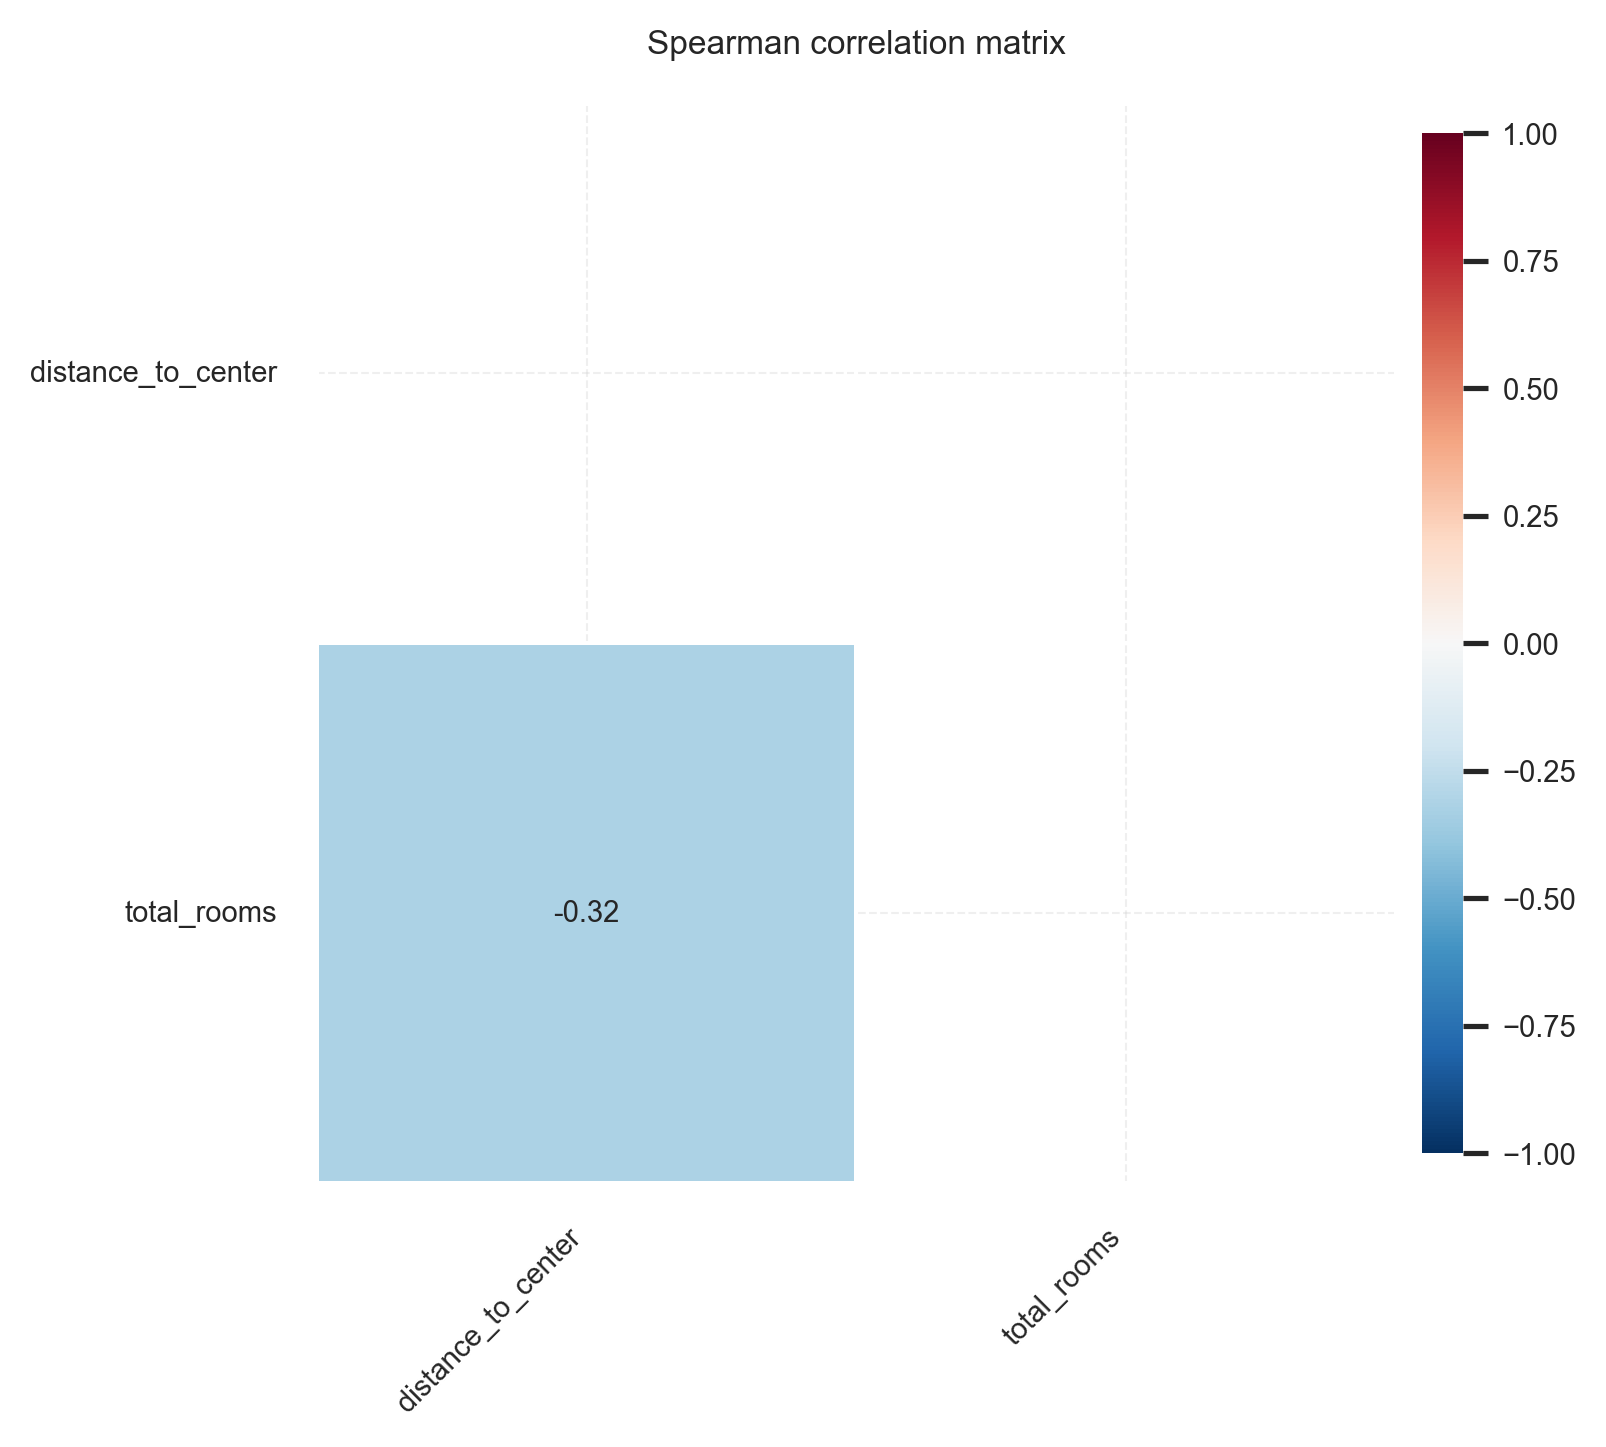

In [314]:

train_data = pd.concat([X_train, y_train], axis=1)

selected_cols = [
    "price",
    "price_log",
    "area",
    "bedrooms",
    "bathrooms",
    "floors",
    "street_width",
    "latitude",
    "longitude",
    "distance_to_center",
    "total_rooms"
]

valid_cols = [c for c in selected_cols if c in train_data.columns]
train_data_subset = train_data[valid_cols].select_dtypes(include=[np.number])

spearman_corr = train_data_subset.corr(method="spearman")
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=300)

sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7, "aspect": 25, "pad": 0.02},
    ax=ax
)

ax.set_title("Spearman correlation matrix", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.tick_params(bottom=False, left=False)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


The new variable does not decrease its correlation with the target variable.

# 4. Save the cleaned data


In [315]:

print("⏳ Cleaning non-informative text and identifier columns...")


cols_to_drop_early = ['Link', 'Địa chỉ', 'Mô tả', 'Loại đường vào', 'Khoảng giá_log']

X_train = X_train.drop(columns=cols_to_drop_early, errors='ignore')

if 'X_test' in locals():
    X_test = X_test.drop(columns=cols_to_drop_early, errors='ignore')

print(f"✅ Cleaning completed! Dropped columns: {cols_to_drop_early}")
print(f"📐 Current X_train shape: {X_train.shape}")
print(X_train.columns)


⏳ Cleaning non-informative text and identifier columns...
✅ Cleaning completed! Dropped columns: ['Link', 'Địa chỉ', 'Mô tả', 'Loại đường vào', 'Khoảng giá_log']
📐 Current X_train shape: (7, 32)
Index(['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng',
       'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude',
       'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag', 'District', 'Ward',
       'Street', 'Transport_Ratio', 'Public_Green_Ratio', 'Other_Land_Ratio',
       'Residential_Ratio', 'alley_accessible', 'near_supermarket',
       'near_school', 'near_hospital', 'near_park_or_lake', 'total_rooms',
       'distance_to_center'],
      dtype='object')


In [316]:
import os

os.makedirs('data_output', exist_ok=True)

df_train_clean = pd.concat([X_train, y_train], axis=1)

df_test_clean = pd.concat([X_test, y_test], axis=1) if 'y_test' in locals() else X_test.copy()

df_train_clean.to_csv('data_output/1_data_cleaned_train.csv', index=False)
df_test_clean.to_csv('data_output/1_data_cleaned_test.csv', index=False)

print("💾 FILE 1: Clean dataset saved successfully!")
print("   -> data_output/1_data_cleaned_train.csv")
print("   -> data_output/1_data_cleaned_test.csv")


💾 FILE 1: Clean dataset saved successfully!
   -> data_output/1_data_cleaned_train.csv
   -> data_output/1_data_cleaned_test.csv
